## 1. 環境設置和套件安裝

In [1]:
# 安裝必要套件
!pip install imbalanced-learn==0.13.0
!pip install scikit-learn==1.6.1
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 11.4 MB/s eta 0:00:00
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.0
    Uninstalling imbalanced-learn-0.14.0:
      Successfully uninstalled imbalanced-learn-0.14.0


In [2]:
# 導入必要的套件
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, f1_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours
from imblearn.combine import SMOTEENN, SMOTETomek
import warnings
warnings.filterwarnings("ignore")

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, Conv1D, Reshape, BatchNormalization,
    GlobalAveragePooling1D, Input, concatenate, SpatialDropout1D, GlobalMaxPooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import AUC, Precision, Recall
from tensorflow.keras.regularizers import l1_l2, l2
from tensorflow.keras import backend as K
from tensorflow.keras.utils import register_keras_serializable

# 保存和加載相關
import os
import json
import pickle
from datetime import datetime

# Add imports for tree-based models
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

print("✓ 所有套件導入成功")

✓ 所有套件導入成功


In [3]:
# 設置隨機種子確保結果可重現
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# 設置中文字體
# plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
# plt.rcParams["axes.unicode_minus"] = False

print(f"隨機種子設置為: {RANDOM_STATE}")

隨機種子設置為: 42


In [4]:
%%html
<audio src="https://oob.ac/wp-content/uploads/2016/06/1min_silence.mp3" controls autoplay loop style="display:none"></audio>
<b>Audio player is running in background to keep session alive...</b>

## 載入中文字型

✅ 已載入字型： ['Noto Sans TC']


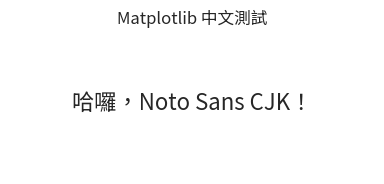

In [5]:
# 設定 Matplotlib 參數以正確顯示中文和負號
# 以下是常用的中文字型，Colab 環境通常支援 WenQuanYi Micro Hei
plt.rcParams['font.family'] = ['Noto Sans CJK TC', 'WenQuanYi Micro Hei', 'SimHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

# 設定 Seaborn 樣式
sns.set_theme(style="whitegrid", font=['Noto Sans CJK TC', 'WenQuanYi Micro Hei', 'SimHei', 'sans-serif'])

"""
跨平台載入 Noto Sans CJK 字型並驗證
在 VS Code + 本地 Python 環境執行
"""

import os
import sys
import platform
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager

# ---------- 1. 推斷各作業系統的預設字型路徑 ----------
def guess_noto_path() -> str | None:
    """回傳可能存在的 NotoSansCJK-Regular.ttc 路徑，找不到則回傳 None"""
    candidates = []

    match platform.system():
        case "Windows":
            candidates = [
                r"C:\Windows\Fonts\NotoSansCJK-Regular.ttc",
                r"C:\Windows\Fonts\NotoSansCJKtc-Regular.otf",
            ]
        case "Darwin":  # macOS
            candidates = [
                "/Library/Fonts/NotoSansCJK-Regular.ttc",
                "/System/Library/Fonts/NotoSansCJK.ttc",
            ]
        case "Linux":
            # 常見安裝位置；亦可加入 ~/.local/share/fonts
            candidates = [
                "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
                "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
                str(Path.home() / ".local/share/fonts/NotoSansCJK-Regular.ttc"),
            ]

    for p in candidates:
        if Path(p).is_file():
            return p
    return None


# ---------- 2. 取得字型路徑（可改為專案內相對路徑） ----------
# font_path = guess_noto_path()
font_path = 'NotoSansTC-Regular.ttf'  # 若已下載字型檔，請確認路徑正確

if font_path is None:
    # 若系統沒安裝，可改成專案相對路徑，例如 Path("fonts/NotoSansCJK-Regular.ttc")
    font_path = "fonts/NotoSansCJK-Regular.ttc"  # 請確認實際檔案位置
    if not Path(font_path).is_file():
        sys.exit(
            f"❌ 找不到 Noto Sans CJK 字型！\n"
            f"  請先安裝字型或把字型檔放到 {font_path}"
        )

# ---------- 3. 動態註冊並設定為預設中文字型 ----------
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()

# ---------- 4. 驗證 ----------
print("✅ 已載入字型：", plt.rcParams["font.family"])

# (可選) 畫個示範圖
plt.figure(figsize=(4, 2))
plt.title("Matplotlib 中文測試")
plt.text(0.5, 0.5, "哈囉，Noto Sans CJK！", ha="center", va="center", size=16)
plt.axis("off")
plt.tight_layout()
plt.show()


## 2. 數據上傳和載入

In [31]:
# 載入數據並分析類別分布
try:
    # train_df = pd.read_csv("csr_service_bill_enhanced_union.csv")
    # pred_df = pd.read_csv("/content/forPredict_inSameShape_union.csv")
    # train_df = pd.read_csv("/content/sfss_selected_features_dataset_fixed_v1_20251101_095339.csv", sep='^')
    # train_df = pd.read_csv("/content/sfss_selected_features_dataset_fixed_v1_20251206_070359.csv", sep='^')
    # train_df = pd.read_csv("/content/sfss_selected_features_dataset_fixed_v1_20251213_123906.csv", sep='^')
    # train_df = pd.read_csv("/content/sfss_selected_features_dataset_fixed_v1_20251217_145619.csv", sep='^')
    # train_df = pd.read_csv("/content/sfss_selected_features_dataset_fixed_v1_20251224_010823.csv", sep='^')
    train_df = pd.read_csv("/content/sfss_selected_features_dataset_fixed_v1_20251228_065314.csv", sep='^')
    # Fill missing values with 0
    train_df.fillna(0, inplace=True)
    print("✓ 訓練數據中的空值已填入 0")


    print(f"✓ 訓練數據載入成功: {train_df.shape}")


    # 分析類別分布
    if "使用狀態_編碼" in train_df.columns:
        target_dist = train_df["使用狀態_編碼"].value_counts()
        print(f"\n📊 目標變量分布:")
        for value, count in target_dist.items():
            print(f"  類別 {value}: {count:,} 個樣本 ({count/len(train_df)*100:.2f}%)")

        # 計算不平衡比例
        negative_count = target_dist.get(0, 0)
        positive_count = target_dist.get(1, 0)
        imbalance_ratio = negative_count / positive_count if positive_count > 0 else 0
        print(f"\n⚖️ 類別不平衡比例: {imbalance_ratio:.2f}:1 (陰性:陽性)")

        if imbalance_ratio > 3:
            print("⚠️ 檢測到嚴重的類別不平衡問題，將使用專門的優化策略")

except Exception as e:
    print(f"❌ 數據載入失敗: {e}")

✓ 訓練數據中的空值已填入 0
✓ 訓練數據載入成功: (85118, 76)

📊 目標變量分布:
  類別 0: 79,794 個樣本 (93.75%)
  類別 1: 5,324 個樣本 (6.25%)

⚖️ 類別不平衡比例: 14.99:1 (陰性:陽性)
⚠️ 檢測到嚴重的類別不平衡問題，將使用專門的優化策略


### 忽略本段，除非只想取某部份特徵進行訓練

In [22]:
### 忽略本段，除非只想取某部份特徵進行訓練
features_for_train_df = pd.read_csv("/content/feature_source_mapping_complete.csv")

selected_features = features_for_train_df[
    (features_for_train_df['borda_rank'] >= 1) &
    (features_for_train_df['borda_rank'] <= 66)
]['feature_name'].tolist()

print(f"已選擇 {len(selected_features)} 個特徵：")
print(selected_features)

columns_to_keep = list(selected_features)

# Ensure the target column '使用狀態_編碼' is included if it exists and is not already in selected_features
if '使用狀態_編碼' in train_df.columns and '使用狀態_編碼' not in columns_to_keep:
    columns_to_keep.append('使用狀態_編碼')
if 'CUST_NO' in train_df.columns and 'CUST_NO' not in columns_to_keep:
    columns_to_keep.append('CUST_NO')

# Filter train_df to keep only the specified columns
train_df = train_df[columns_to_keep].copy()

print(f"✓ train_df 已根據選擇的特徵和目標欄位進行過濾。新的形狀為: {train_df.shape}")
print(f"過濾後的特徵欄位: {train_df.columns.tolist()}")

已選擇 66 個特徵：
['AVG_SENTIMENT_SCORE', 'AVG_score', 'CALL_CONCENTRATION', 'MAIN_CAT_帳務相關_COUNT', 'MAIN_CAT_帳務相關_RATIO', 'MAIN_CAT_經銷商問題_RATIO', 'MIN_CALL_INTERVAL_DAYS', 'ACTIVE_MONTHS', 'ACTIVE_QUARTERS', 'AVG_CALL_INTERVAL_DAYS', 'AVG_MONTHLY_CALLS', 'SUB_CAT_Cable modem連線_RATIO', 'IS_SINGLE_ISSUE_CUSTOMER', 'MAIN_CAT_帳務問題_RATIO', 'SUB_CAT_拆機挽回_COUNT', 'SUB_CAT_無法上網_RATIO', 'MAIN_CAT_網路連線問題_COUNT', 'SUB_CAT_用戶退租_COUNT', 'MAIN_CAT_網路連線問題_RATIO', 'SUB_CAT_用戶退租_RATIO', 'MIN_SENTIMENT_SCORE', 'PROBLEM_COMPLEXITY_SCORE', 'TOTAL_SENTIMENT_SCORE', 'STD_CALL_INTERVAL_DAYS', 'paymethod_CVS臨櫃代收(7-11)', 'STD_SENTIMENT_SCORE', 'paymethod_廠商代收', 'SUB_CAT_台哥大-電訪約裝_COUNT', 'paytype_1', 'SUB_CAT_台哥大-電訪約裝_RATIO', 'SUB_CAT_拆機挽回_RATIO', 'paytype_6', 'SUB_CAT_無法上網_COUNT', 'MAIN_CATEGORY_ENTROPY', 'MAIN_CAT_經銷商問題_COUNT', 'SUB_CAT_遠傳電信-電訪約裝_COUNT', 'MAIN_PROBLEM_RATIO', '平均繳款延遲日數', 'paymethod_簡訊帳單臨櫃代收(7-11)', 'STD_MONTHLY_CALLS', 'RECENT_3M_CALLS', 'SUB_CAT_mac 己被註冊_RATIO', 'SUB_CAT_台哥大-人員進電_RATIO', 'paytype

### 忽略本段，除非只想取有 Permutation Importance特徵

In [ ]:
import pandas as pd

# Load the feature importance data
feature_importance_df = pd.read_csv('/content/sfss_feature_importance_report_fixed_v1_20251217_145619.csv')

'''
# Display the head of the DataFrame
print("Feature Importance DataFrame Head:")
display(feature_importance_df.head())

# Print the shape of the DataFrame
print(f"\nFeature Importance DataFrame Shape: {feature_importance_df.shape}")
'''
selected_features_by_perm_imp = feature_importance_df[feature_importance_df['permutation_importance'] > 0]['feature_name'].tolist()

print(f"已選擇 {len(selected_features_by_perm_imp)} 個特徵 (permutation_importance > 0):")
# print(selected_features_by_perm_imp)

columns_to_keep = list(selected_features_by_perm_imp)

# Ensure the target column '使用狀態_編碼' is included if it exists and is not already in selected_features
if '使用狀態_編碼' in train_df.columns and '使用狀態_編碼' not in columns_to_keep:
    columns_to_keep.append('使用狀態_編碼')
# Ensure 'CUST_NO' is included if it exists and is not already in selected_features
if 'CUST_NO' in train_df.columns and 'CUST_NO' not in columns_to_keep:
    columns_to_keep.append('CUST_NO')

# Filter train_df to keep only the specified columns
train_df = train_df[columns_to_keep].copy()

print(f"✓ train_df 已根據選擇的特徵和目標欄位進行過濾。新的形狀為: {train_df.shape}")
print(f"過濾後的特徵欄位: {train_df.columns.tolist()}")

# print("Filtered train_df Head:")
# display(train_df.head())
# print(f"\nFiltered train_df Shape: {train_df.shape}")

已選擇 15 個特徵 (permutation_importance > 0):
✓ train_df 已根據選擇的特徵和目標欄位進行過濾。新的形狀為: (81569, 17)
過濾後的特徵欄位: ['平均繳款延遲日數', 'paymethod_廠商代收', 'MAIN_CAT_網路連線問題_RATIO', 'SUB_CAT_台哥大-電訪約裝_RATIO', 'paytype_6', 'AVG_score', '系統台_台灣佳光', 'SUB_CAT_拆機挽回_COUNT', 'MAIN_CAT_帳務相關_COUNT', 'product_EPON', '系統台_大屯', 'paytype_1', 'MAIN_CAT_帳務相關_RATIO', 'SUB_CAT_拆機挽回_RATIO', 'paymethod_CVS臨櫃代收(7-11)', '使用狀態_編碼', 'CUST_NO']


## 3. 修復後的閾值優化函數

In [32]:
# Define the threshold optimization function (from cell 'fixed_threshold_function')
def optimize_threshold_for_positive_class_fixed(y_true, y_pred_proba):
    """修復版本的閾值優化函數"""
    try:
        y_true = np.asarray(y_true).flatten()
        y_pred_proba = np.asarray(y_pred_proba).flatten()

        if len(y_true) != len(y_pred_proba):
            raise ValueError(f"y_true和y_pred_proba長度不匹配: {len(y_true)} vs {len(y_pred_proba)}")

        if len(y_true) == 0:
            raise ValueError("輸入數據為空")

        unique_labels = np.unique(y_true)
        if len(unique_labels) < 2:
            print(f"警告: 只有一個類別 {unique_labels}, 使用默認閾值0.5")
            return {
                "f1_optimized_threshold": 0.5,
                "f1_score": 0.0,
                "recall_optimized_threshold": 0.5,
                "precision_at_f1_threshold": 0.0,
                "recall_at_f1_threshold": 0.0,
                "warning": "Only one class present"
            }

        precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)

        if len(thresholds) == 0:
            print("警告: 無法計算閾值，使用默認值")
            return {
                "f1_optimized_threshold": 0.5,
                "f1_score": 0.0,
                "recall_optimized_threshold": 0.5,
                "precision_at_f1_threshold": 0.0,
                "recall_at_f1_threshold": 0.0,
                "warning": "No thresholds computed"
            }

        with np.errstate(divide="ignore", invalid="ignore"):
            f1_scores = 2 * (precision * recall) / (precision + recall)
            f1_scores = np.nan_to_num(f1_scores, nan=0.0, posinf=0.0, neginf=0.0)

        if len(f1_scores) == 0:
            best_f1_idx = 0
            best_f1 = 0.0
        else:
            best_f1_idx = np.argmax(f1_scores)
            best_f1 = f1_scores[best_f1_idx]

        if best_f1_idx < len(thresholds):
            best_threshold = thresholds[best_f1_idx]
        else:
            best_threshold = thresholds[-1] if len(thresholds) > 0 else 0.5
            print(f"警告: F1最佳索引 {best_f1_idx} 超出閾值範圍，使用閾值 {best_threshold}")

        best_precision = precision[best_f1_idx] if best_f1_idx < len(precision) else 0.0
        best_recall = recall[best_f1_idx] if best_f1_idx < len(recall) else 0.0

        recall_optimized_threshold = best_threshold

        try:
            valid_precision_mask = precision >= 0.5
            if np.any(valid_precision_mask):
                valid_indices = np.where(valid_precision_mask)[0]
                valid_recall = recall[valid_indices]

                if len(valid_recall) > 0:
                    best_recall_idx_in_valid = np.argmax(valid_recall)
                    best_recall_idx_global = valid_indices[best_recall_idx_in_valid]

                    if best_recall_idx_global < len(thresholds):
                        recall_optimized_threshold = thresholds[best_recall_idx_global]
                    else:
                        recall_optimized_threshold = thresholds[-1] if len(thresholds) > 0 else 0.5
        except Exception as e:
            print(f"計算召回率優化閾值時出錯: {e}")

        result = {
            "f1_optimized_threshold": float(best_threshold),
            "f1_score": float(best_f1),
            "recall_optimized_threshold": float(recall_optimized_threshold),
            "precision_at_f1_threshold": float(best_precision),
            "recall_at_f1_threshold": float(best_recall),
            "num_thresholds": len(thresholds),
            "num_precision_recall_points": len(precision)
        }

        return result

    except Exception as e:
        print(f"閾值優化過程中發生錯誤: {e}")
        return {
            "f1_optimized_threshold": 0.5,
            "f1_score": 0.0,
            "recall_optimized_threshold": 0.5,
            "precision_at_f1_threshold": 0.0,
            "recall_at_f1_threshold": 0.0,
            "error": str(e)
        }

print("✓ 修復後的閾值優化函數定義完成")

✓ 修復後的閾值優化函數定義完成


## 4. 陽性類別分析函數

In [33]:
# Define the plotting function
def plot_positive_class_analysis(y_true, y_pred_proba, threshold_info, title="模型分析"):
    """繪製陽性類別分析圖表"""

    # 使用最佳閾值進行預測
    threshold = threshold_info["f1_optimized_threshold"]
    y_pred = (y_pred_proba >= threshold).astype(int)

    # 計算各類別指標
    report = classification_report(y_true, y_pred, output_dict=True)

    # Extract metrics, handling cases where a class might be missing in predictions
    pos_metrics = {
        "precision": report.get("1", {}).get("precision", 0.0),
        "recall": report.get("1", {}).get("recall", 0.0),
        "f1": report.get("1", {}).get("f1-score", 0.0)
    }

    neg_metrics = {
        "precision": report.get("0", {}).get("precision", 0.0),
        "recall": report.get("0", {}).get("recall", 0.0),
        "f1": report.get("0", {}).get("f1-score", 0.0)
    }


    overall_metrics = {
        "accuracy": report.get("accuracy", 0.0),
        "auc": roc_auc_score(y_true, y_pred_proba) if len(np.unique(y_true)) >= 2 else np.nan # Calculate AUC only if y_true has >= 2 classes
    }


    # Calculate positive advantage
    positive_advantage = {
        "precision_diff": pos_metrics["precision"] - neg_metrics["precision"],
        "recall_diff": pos_metrics["recall"] - neg_metrics["recall"],
        "f1_diff": pos_metrics["f1"] - neg_metrics["f1"]
    }

    # Create charts
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f"{title} - 陽性類別優化分析", fontsize=16, fontweight="bold")

    # 1. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0,0])
    axes[0,0].set_title("混淆矩陣")
    axes[0,0].set_xlabel("預測值")
    axes[0,0].set_ylabel("真實值")

    # 2. Class Metrics Comparison
    metrics_names = ["Precision", "Recall", "F1-Score"]
    pos_values = [pos_metrics["precision"], pos_metrics["recall"], pos_metrics["f1"]]
    neg_values = [neg_metrics["precision"], neg_metrics["recall"], neg_metrics["f1"]]

    x = np.arange(len(metrics_names))
    width = 0.35

    axes[0,1].bar(x - width/2, pos_values, width, label="陽性類別", color="orange", alpha=0.8)
    axes[0,1].bar(x + width/2, neg_values, width, label="陰性類別", color="blue", alpha=0.8)
    axes[0,1].set_xlabel("指標")
    axes[0,1].set_ylabel("分數")
    axes[0,1].set_title("各類別指標比較")
    axes[0,1].set_xticks(x)
    axes[0,1].set_xticklabels(metrics_names)
    axes[0,1].legend()
    axes[0,1].set_ylim(0, 1)

    # 3. Predicted Probability Distribution
    axes[1,0].hist(y_pred_proba[y_true == 0], bins=50, alpha=0.7, label="陰性樣本", color="blue")
    axes[1,0].hist(y_pred_proba[y_true == 1], bins=50, alpha=0.7, label="陽性樣本", color="orange")
    axes[1,0].axvline(threshold, color="red", linestyle="--", label=f"最佳閾值: {threshold:.3f}")
    axes[1,0].set_xlabel("預測概率")
    axes[1,0].set_ylabel("頻率")
    axes[1,0].set_title("預測概率分布")
    axes[1,0].legend()

    # 4. ROC Curve (only plot if AUC was calculated)
    if not np.isnan(overall_metrics['auc']):
        fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
        axes[1,1].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC曲線 (AUC = {overall_metrics['auc']:.3f})")
        axes[1,1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
        axes[1,1].set_xlim([0.0, 1.0])
        axes[1,1].set_ylim([0.0, 1.05])
        axes[1,1].set_xlabel("假陽性率")
        axes[1,1].set_ylabel("真陽性率")
        axes[1,1].set_title("ROC曲線")
        axes[1,1].legend(loc="lower right")
    else:
        axes[1,1].set_title("ROC曲線 (AUC 無法計算)")
        axes[1,1].text(0.5, 0.5, "目標變量只有一個類別", horizontalalignment='center', verticalalignment='center', transform=axes[1,1].transAxes)


    plt.tight_layout()
    plt.show()

    # Return analysis results
    return {
        "positive_metrics": pos_metrics,
        "negative_metrics": neg_metrics,
        "overall_metrics": overall_metrics,
        "positive_advantage": positive_advantage,
        "threshold_used": threshold
    }

print("✓ 陽性類別分析函數定義完成")


✓ 陽性類別分析函數定義完成


## 5. 模型和特徵處理保存管理器

In [34]:
import os
import pickle
import json
from datetime import datetime
import tensorflow as tf
import numpy as np
import pandas as pd # Import pandas for DataFrame handling

class ModelPersistenceManager:
    """模型持久化管理器"""

    def __init__(self, base_path="./saved_models"):
        self.base_path = base_path
        self.ensure_directory_exists()

    def ensure_directory_exists(self):
        if not os.path.exists(self.base_path):
            os.makedirs(self.base_path)
            print(f"創建保存目錄: {self.base_path}")

    def save_feature_processor(self, feature_processor, model_name):
        try:
            model_dir = os.path.join(self.base_path, model_name)
            if not os.path.exists(model_dir):
                os.makedirs(model_dir)

            processor_data = {
                "feature_names": getattr(feature_processor, "feature_names", None),
                "removed_features": getattr(feature_processor, "removed_features", {}),
                "random_state": getattr(feature_processor, "random_state", 42),
                "timestamp": datetime.now().isoformat(),
                "version": "1.0"
            }

            config_path = os.path.join(model_dir, "feature_processor_config.json")
            with open(config_path, "w", encoding="utf-8") as f:
                json.dump(processor_data, f, indent=2, ensure_ascii=False)

            if hasattr(feature_processor, "scaler") and feature_processor.scaler is not None:
                scaler_path = os.path.join(model_dir, "scaler.pkl")
                with open(scaler_path, "wb") as f:
                    pickle.dump(feature_processor.scaler, f)
                print(f"✓ Scaler已保存到: {scaler_path}")

            processor_path = os.path.join(model_dir, "feature_processor.pkl")
            with open(processor_path, "wb") as f:
                pickle.dump(feature_processor, f)


            print(f"✓ 特徵處理器已保存到: {model_dir}")
            return True

        except Exception as e:
            print(f"❌ 保存特徵處理器失敗: {e}")
            return False

    def load_feature_processor(self, model_name):
        try:
            model_dir = os.path.join(self.base_path, model_name)

            if not os.path.exists(model_dir):
                raise FileNotFoundError(f"模型目錄不存在: {model_dir}")

            processor_path = os.path.join(model_dir, "feature_processor.pkl")
            if os.path.exists(processor_path):
                with open(processor_path, "rb") as f:
                    feature_processor = pickle.load(f)
                print(f"✓ 特徵處理器已從 {processor_path} 加載")
                return feature_processor
            else:
                raise FileNotFoundError(f"特徵處理器文件不存在: {processor_path}")

        except Exception as e:
            print(f"❌ 加載特徵處理器失敗: {e}")
            return None

    def save_model(self, model, model_name, model_type="keras"):
        try:
            model_dir = os.path.join(self.base_path, model_name)
            if not os.path.exists(model_dir):
                os.makedirs(model_dir)

            if model_type == "keras":
                model_path = os.path.join(model_dir, "model.keras")
                # model.save(model_path, save_format="keras")
                model.save(model_path)
                print(f"✓ Keras模型已保存到: {model_path}")

                architecture_path = os.path.join(model_dir, "model_architecture.json")
                with open(architecture_path, "w") as f:
                    f.write(model.to_json())
                print(f"✓ 模型架構已保存到: {architecture_path}")

            elif model_type == "sklearn" or model_type == "pickle":
                model_path = os.path.join(model_dir, "model.pkl")
                with open(model_path, "wb") as f:
                    pickle.dump(model, f)
                print(f"✓ {model_type}模型已保存到: {model_path}")

            metadata = {
                "model_type": model_type,
                "model_name": model_name,
                "save_timestamp": datetime.now().isoformat(),
                "version": "1.0"
            }

            metadata_path = os.path.join(model_dir, "model_metadata.json")
            with open(metadata_path, "w", encoding="utf-8") as f:
                json.dump(metadata, f, indent=2, ensure_ascii=False)

            return True

        except Exception as e:
            print(f"❌ 保存模型失敗: {e}")
            return False

    def load_model(self, model_name):
        try:
            model_dir = os.path.join(self.base_path, model_name)

            if not os.path.exists(model_dir):
                raise FileNotFoundError(f"模型目錄不存在: {model_dir}")

            metadata_path = os.path.join(model_dir, "model_metadata.json")
            if os.path.exists(metadata_path):
                with open(metadata_path, "r", encoding="utf-8") as f:
                    metadata = json.load(f)
                model_type = metadata.get("model_type", "keras")
            else:
                if os.path.exists(os.path.join(model_dir, "model.keras")):
                    model_type = "keras"
                elif os.path.exists(os.path.join(model_dir, "model.pkl")):
                    model_type = "pickle"
                else:
                    raise FileNotFoundError("無法找到模型文件")

            if model_type == "keras":
                try:
                    model_path = os.path.join(model_dir, "model.keras")
                    model = tf.keras.models.load_model(model_path)
                    print(f"✓ Keras模型已從 {model_path} 加載")
                    return model
                except ImportError:
                    print("❌ TensorFlow未安裝，無法加載Keras模型")
                    return None

            elif model_type in ["sklearn", "pickle"]:
                model_path = os.path.join(model_dir, "model.pkl")
                with open(model_path, "rb") as f:
                    model = pickle.load(f)
                print(f"✓ {model_type}模型已從 {model_path} 加載")
                return model

        except Exception as e:
            print(f"❌ 加載模型失敗: {e}")
            return None

    def save_training_config(self, config, model_name):
        try:
            model_dir = os.path.join(self.base_path, model_name)
            if not os.path.exists(model_dir):
                os.makedirs(model_dir)

            config["save_timestamp"] = datetime.now().isoformat()

            config_path = os.path.join(model_dir, "training_config.json")
            with open(config_path, "w", encoding="utf-8") as f:
                json.dump(config, f, indent=2, ensure_ascii=False, default=str)

            print(f"✓ 訓練配置已保存到: {config_path}")
            return True

        except Exception as e:
            print(f"❌ 保存訓練配置失敗: {e}")
            return False

    def load_training_config(self, model_name):
        try:
            model_dir = os.path.join(self.base_path, model_name)
            config_path = os.path.join(model_dir, "training_config.json")

            if os.path.exists(config_path):
                with open(config_path, "r", encoding="utf-8") as f:
                    config = json.load(f)
                print(f"✓ 訓練配置已從 {config_path} 加載")
                return config
            else:
                print(f"⚠️ 訓練配置文件不存在: {config_path}")
                return {}

        except Exception as e:
            print(f"❌ 加載訓練配置失敗: {e}")
            return {}

    def save_threshold_info(self, threshold_info, model_name):
        try:
            model_dir = os.path.join(self.base_path, model_name)
            if not os.path.exists(model_dir):
                os.makedirs(model_dir)

            threshold_info["save_timestamp"] = datetime.now().isoformat()

            threshold_path = os.path.join(model_dir, "threshold_info.json")
            with open(threshold_path, "w", encoding="utf-8") as f:
                json.dump(threshold_info, f, indent=2, ensure_ascii=False, default=str)

            print(f"✓ 閾值信息已保存到: {threshold_path}")
            return True

        except Exception as e:
            print(f"❌ 保存閾值信息失敗: {e}")
            return False

    def load_threshold_info(self, model_name):
        try:
            model_dir = os.path.join(self.base_path, model_name)
            threshold_path = os.path.join(model_dir, "threshold_info.json")

            if os.path.exists(threshold_path):
                with open(threshold_path, "r", encoding="utf-8") as f:
                    threshold_info = json.load(f)
                print(f"✓ 閾值信息已從 {threshold_path} 加載")
                return threshold_info
            else:
                print(f"⚠️ 閾值信息文件不存在: {threshold_path}")
                return {"f1_optimized_threshold": 0.5}

        except Exception as e:
            print(f"❌ 加載閾值信息失敗: {e}")
            return {"f1_optimized_threshold": 0.5}

    def save_complete_pipeline(self, feature_processor, model_results, model_name_prefix="improved_"):
        """Saves the feature processor and results for multiple models."""
        print(f"\n🔄 Saving complete pipeline components with prefix: {model_name_prefix}")

        # Ensure the base directory exists
        self.ensure_directory_exists()

        success_feature_processor = self.save_feature_processor(feature_processor, f"{model_name_prefix}common_processor")

        saved_models_info = {}
        for model_type, result in model_results.items():
            model = result["model"]
            training_config = result["training_config"]
            threshold_info = result["threshold_info"]
            model_name = f"{model_name_prefix}{model_type.lower()}_model"
            model_type_str = "keras" if isinstance(model, tf.keras.models.Model) else "pickle" # Determine model type

            success_model = self.save_model(model, model_name, model_type_str)
            success_config = self.save_training_config(training_config, model_name)
            success_threshold = self.save_threshold_info(threshold_info, model_name)

            saved_models_info[model_type] = {
                "model_name": model_name,
                "success": success_model and success_config and success_threshold
            }

        all_successful = success_feature_processor and all(info["success"] for info in saved_models_info.values())

        if all_successful:
            print(f"\n🎉 Complete pipeline components saved successfully!")
            print(f"📁 Saved location prefix: {os.path.join(self.base_path, model_name_prefix)}")
            return True
        else:
            print(f"\n⚠️ Failed to save some pipeline components.")
            return False


    def load_complete_pipeline(self, model_name_prefix="improved_"):
        """Loads the feature processor and results for multiple models."""
        print(f"\n🔄 Loading complete pipeline components with prefix: {model_name_prefix}")

        pipeline = {
            "feature_processor": None,
            "model_results": {},
            "success": False
        }

        # Ensure the base directory exists before trying to load
        if not os.path.exists(self.base_path):
            print(f"❌ 保存目錄不存在: {self.base_path}. 無法加載。")
            return pipeline

        pipeline["feature_processor"] = self.load_feature_processor(f"{model_name_prefix}common_processor")

        # Attempt to load results for known model types (CNN, MLP, LSTM)
        for model_type in ["CNN", "MLP", "LSTM", "XGBoost","RandomForest"]:
            model_name = f"{model_name_prefix}{model_type.lower()}_model"
            loaded_model = self.load_model(model_name)
            loaded_config = self.load_training_config(model_name)
            loaded_threshold = self.load_threshold_info(model_name)

            if loaded_model is not None:
                 pipeline["model_results"][model_type] = {
                    "model": loaded_model,
                    "training_config": loaded_config,
                    "threshold_info": loaded_threshold
                }

        if pipeline["feature_processor"] is not None and pipeline["model_results"]:
            pipeline["success"] = True
            print(f"\n🎉 Complete pipeline components loaded successfully!")
        else:
            print(f"\n❌ Failed to load critical pipeline components.")

        return pipeline


    def list_saved_models(self):
        try:
            if not os.path.exists(self.base_path):
                print("保存目錄不存在")
                return []

            print(f"\n📋 已保存的模型組:")
            models = []
            for item in os.listdir(self.base_path):
                item_path = os.path.join(self.base_path, item)
                if os.path.isdir(item_path):
                    # Check for presence of processor config as an indicator of a saved pipeline
                    if os.path.exists(os.path.join(item_path, "feature_processor_config.json")):
                         models.append(item)

            if models:
                for i, model_group in enumerate(models, 1):
                     print(f"  {i}. {model_group}")
            else:
                 print("  沒有找到已保存的模型組")


            return models

        except Exception as e:
            print(f"❌ 列出模型失敗: {e}")
            return []

    def predict_with_saved_model(self, model_name_prefix, X_new, model_type="CNN"):
        try:
            print(f"\n🔮 Using saved pipeline with prefix '{model_name_prefix}' for prediction using {model_type} model...")

            # Ensure the base directory exists before trying to load
            if not os.path.exists(self.base_path):
                return {"error": f"保存目錄不存在: {self.base_path}. 無法進行預測。", "success": False}


            pipeline = self.load_complete_pipeline(model_name_prefix)

            if not pipeline["success"]:
                return {"error": "Pipeline loading failed"}

            feature_processor = pipeline["feature_processor"]
            model_results = pipeline["model_results"]

            if model_type not in model_results:
                 return {"error": f"Model type '{model_type}' not found in the loaded pipeline.", "success": False}

            model_info = model_results[model_type]
            model = model_info["model"]
            threshold_info = model_info["threshold_info"]

            # Apply feature engineering using the loaded processor
            if isinstance(X_new, pd.DataFrame):
                X_processed, _ = feature_processor.advanced_feature_engineering(
                    X_new.copy(), is_training=False # Pass a copy to avoid modifying original df
                )
            else:
                # If X_new is already a NumPy array, assume it's processed but need to convert to DataFrame
                # to pass through advanced_feature_engineering for feature name consistency.
                # This path is less likely for raw prediction input.
                # For now, let's assume X_new is always a DataFrame for initial processing.
                return {"error": "X_new must be a pandas DataFrame for feature engineering.", "success": False}

            # Apply scaling using the loaded scaler
            X_scaled = X_processed # Initialize with X_processed
            if feature_processor.scaler is not None:
                # Convert DataFrame to NumPy array for scaling
                X_to_scale = X_processed.values if isinstance(X_processed, pd.DataFrame) else X_processed
                X_scaled = feature_processor.scaler.transform(X_to_scale)
                # Convert back to DataFrame if original was DataFrame to maintain feature names for tree models
                if isinstance(X_processed, pd.DataFrame):
                    X_scaled = pd.DataFrame(X_scaled, columns=X_processed.columns)
            else:
                print("Warning: Scaler not found in feature processor. Proceeding without scaling.")

            # Reshape for LSTM if the chosen model is LSTM and data is not already 3D
            if model_type == "LSTM":
                # Ensure X_scaled is numpy array before reshaping
                if isinstance(X_scaled, pd.DataFrame):
                    X_scaled = X_scaled.values
                if len(X_scaled.shape) == 2: # Reshape only if it's 2D (samples, features)
                    X_scaled = np.reshape(X_scaled, (X_scaled.shape[0], X_scaled.shape[1], 1))

            y_pred_proba = model.predict(X_scaled)
            if len(y_pred_proba.shape) > 1:
                y_pred_proba = y_pred_proba.flatten()

            threshold = threshold_info.get("f1_optimized_threshold", 0.5)
            y_pred_binary = (y_pred_proba >= threshold).astype(int)

            result = {
                "probabilities": y_pred_proba.tolist(),
                "binary_predictions": y_pred_binary.tolist(),
                "threshold_used": threshold,
                "num_samples": len(y_pred_proba),
                "positive_predictions": int(np.sum(y_pred_binary)),
                "success": True
            }

            print(f"✓ Prediction completed: {len(y_pred_proba)} samples")
            print(f"✓ Positive predictions: {np.sum(y_pred_binary)}")
            print(f"✓ Threshold used: {threshold:.4f}")

            return result

        except Exception as e:
            print(f"❌ Prediction failed: {e}")
            import traceback
            traceback.print_exc()
            return {"error": str(e), "success": False}

print("✓ 模型和特徵處理保存管理器定義完成")

✓ 模型和特徵處理保存管理器定義完成


## 6-1. 陽性類別優化器

In [ ]:
# Define the ImprovedPositiveClassOptimizer class (from cell 'improved_positive_optimizer')
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import TomekLinks
from imblearn.pipeline import Pipeline

class ImprovedPositiveClassOptimizer:
    """改進的陽性類別優化器"""

    def __init__(self, random_state=42):
        self.random_state = random_state
        self.scaler = None
        self.feature_selector = None
        self.sampling_strategy = None
        self.feature_names = None
        self.removed_features = {
            "constant": [],
            "high_corr": [],
            "low_variance": [],
            "outliers_clipped": []
        }

    def advanced_feature_engineering(self, df, target_col=None, is_training=True):
        print(f"原始特徵數量: {df.shape[1]}")

        exclude_cols = ["CUST_NO", "使用狀態", "使用狀態_編碼"]
        # Correctly identify feature columns when delimiter is '^'
        if '^' in df.columns[0] and is_training and target_col is not None:
            # Assuming the last part after the last '^' is the target if target_col is None
            # Or, if target_col is provided, find the column containing it

             # Find the column that contains the target_col name
             target_column_name_in_df = None
             for col in df.columns:
                 if target_col in col:
                     target_column_name_in_df = col
                     break

             if target_column_name_in_df is None:
                 # If target column not found after splitting, try loading with '^' delimiter
                 try:
                     df = pd.read_csv("/content/final_dataset_sfss.csv", sep='^')
                     print("重新載入數據並使用 '^' 分隔符")
                     # Now the target column should be directly available
                     target_column_name_in_df = target_col
                 except FileNotFoundError:
                     raise FileNotFoundError(f"Target column '{target_col}' not found and file not found at /content/sfss_selected_features_dataset_fixed.csv")
                 except Exception as e:
                     raise Exception(f"Error reloading data with '^' delimiter: {e}")


             # Split the columns and reconstruct DataFrame with proper names
             # This part might be redundant if read_csv with sep='^' handles it,
             # but keeping it for robustness if the file has a single column with '^' separated values.
             if '^' in df.columns[0]: # Check again in case read_csv didn't split
                 split_cols = df.columns[0].split('^')
                 df.columns = split_cols # Assign split column names


             # Now drop the exclude columns with correct names
             exclude_cols = ["CUST_NO", "使用狀態", "使用狀態_編碼"] # Use the correct column names after splitting
             feature_cols = [col for col in df.columns if col not in exclude_cols]
             df_features = df[feature_cols].copy()
             y = df[target_column_name_in_df].values # Use the correct target column name


        elif '^' in df.columns[0] and not is_training:
            # For prediction, assume columns are already split if feature_names is set
            if self.feature_names and '^' in df.columns[0]:
                 split_cols = df.columns[0].split('^')
                 df.columns = split_cols # Assign split column names

            exclude_cols = ["CUST_NO", "使用狀態", "使用狀態_編碼"] # Use the correct column names after splitting
            feature_cols = [col for col in df.columns if col not in exclude_cols]
            df_features = df[feature_cols].copy()
            y = None # No target for prediction

        else: # Original logic for comma-separated values or when not training
             feature_cols = [col for col in df.columns if col not in exclude_cols]
             df_features = df[feature_cols].copy()
             if is_training and target_col is not None:
                 y = df[target_col].values
             else:
                 y = None


        if is_training and target_col is not None:
            # Ensure y is a numpy array and convert to integer type
            y = np.asarray(y).astype(int)

            '''
            constant_features = []
            for col in df_features.columns:
                if df_features[col].nunique() <= 1:
                    constant_features.append(col)

            self.removed_features["constant"] = constant_features
            df_features = df_features.drop(columns=constant_features)
            print(f"移除常數特徵: {len(constant_features)}個")

            low_variance_features = []
            for col in df_features.select_dtypes(include=[np.number]).columns:
                if df_features[col].var() < 1e-6:
                    low_variance_features.append(col)

            self.removed_features["low_variance"] = low_variance_features
            df_features = df_features.drop(columns=low_variance_features)
            print(f"移除低方差特徵: {len(low_variance_features)}個")

            if len(df_features.columns) > 1:
                numeric_features = df_features.select_dtypes(include=[np.number])
                if len(numeric_features.columns) > 1:
                    feature_importance = {}
                    for col in numeric_features.columns: # Iterate over numeric columns
                        try:
                            corr_with_positive = np.corrcoef(df_features[col].fillna(0), y)[0, 1]
                            if not np.isnan(corr_with_positive):
                                feature_importance[col] = abs(corr_with_positive)
                        except:
                            feature_importance[col] = 0

                    sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)
                    top_features = [feat for feat, _ in sorted_features[:min(50, len(sorted_features))]]

                    # Keep top features and non-numeric features
                    important_features = [col for col in df_features.columns if col in top_features or col not in df_features.select_dtypes(include=[np.number]).columns]
                    df_features = df_features[important_features]
                    print(f"基於陽性相關性保留特徵: {len(important_features)}個")

            if len(df_features.columns) > 1:
                numeric_features = df_features.select_dtypes(include=[np.number])
                if len(numeric_features.columns) > 1:
                    corr_matrix = numeric_features.corr().abs()
                    upper_tri = corr_matrix.where(
                        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
                    )

                    high_corr_features = [
                        column for column in upper_tri.columns
                        if any(upper_tri[column] > 0.95)
                    ]

                    self.removed_features["high_corr"] = high_corr_features
                    df_features = df_features.drop(columns=high_corr_features)
                    print(f"移除高相關特徵: {len(high_corr_features)}個")

            outlier_cols = []
            for col in df_features.select_dtypes(include=[np.number]).columns:
                Q1 = df_features[col].quantile(0.01)
                Q3 = df_features[col].quantile(0.99)
                IQR = Q3 - Q1
                if IQR > 0:
                    lower_bound = Q1 - 5.0 * IQR
                    upper_bound = Q3 + 5.0 * IQR

                    original_range = df_features[col].max() - df_features[col].min()
                    df_features[col] = df_features[col].clip(lower_bound, upper_bound)
                    new_range = df_features[col].max() - df_features[col].min()

                    if abs(original_range - new_range) > 0.05 * original_range:
                        outlier_cols.append(col)

            self.removed_features["outliers_clipped"] = outlier_cols
            print(f"極值裁剪特徵: {len(outlier_cols)}個")
            '''
            # self.feature_names = df_features.columns.tolist()

        else:
            # Ensure prediction features match training features
            if self.feature_names:
                missing_features = [f for f in self.feature_names if f not in df_features.columns]
                if missing_features:
                    print(f"警告: 缺少特徵 {missing_features}. 將填入 0。")
                    for mf in missing_features:
                         df_features[mf] = 0 # Add missing features with default value

                available_features = [f for f in self.feature_names if f in df_features.columns]
                df_features = df_features[available_features]
            '''
            for col in self.removed_features["outliers_clipped"]:
                if col in df_features.columns:
                    Q1 = df_features[col].quantile(0.01)
                    Q3 = df_features[col].quantile(0.99)
                    IQR = Q3 - Q1
                    if IQR > 0:
                        lower_bound = Q1 - 5.0 * IQR
                        upper_bound = Q3 + 5.0 * IQR
                        df_features[col] = df_features[col].clip(lower_bound, upper_bound)
            '''
            # Ensure feature order matches training features
            if self.feature_names:
                df_features = df_features[self.feature_names]


        print(f"最終特徵數量: {df_features.shape[1]}")
        # Return df_features and y (y will be None for prediction)
        self.feature_names = df_features.columns.tolist() # UNCOMMENTED THIS LINE
        return df_features, y


    def improved_scaling(self, X_train, X_test=None, method="robust"):

        return X_train, X_test
        if method == "robust":
            self.scaler = RobustScaler()
        elif method == "standard":
            self.scaler = StandardScaler()
        else:
            raise ValueError("method must be 'robust' or 'standard'")

        # Ensure X_train is a numpy array before scaling
        if isinstance(X_train, pd.DataFrame):
            X_train = X_train.values

        X_train_scaled = self.scaler.fit_transform(X_train)

        if X_test is not None:
            # Ensure X_test is a numpy array before scaling
            if isinstance(X_test, pd.DataFrame):
                X_test = X_test.values
            X_test_scaled = self.scaler.transform(X_test)
            return X_train_scaled, X_test_scaled

        return X_train_scaled
    '''
    def advanced_sampling_strategy(self, X, y, strategy="smote_tomek"):
        print(f"原始類別分布: {np.bincount(y)}")
        # return X, y

        if strategy == "smote_tomek":
            sampler = SMOTETomek(
                smote=SMOTE(sampling_strategy=0.7, random_state=self.random_state),
                tomek=None,
                random_state=self.random_state
            )
        elif strategy == "smote_enn":
            sampler = SMOTEENN(
                smote=SMOTE(sampling_strategy=0.7, random_state=self.random_state),
                enn=EditedNearestNeighbours(sampling_strategy="majority"),
                random_state=self.random_state
            )
        elif strategy == "borderline_smote":
            sampler = BorderlineSMOTE(
                sampling_strategy=0.6,
                random_state=self.random_state,
                kind="borderline-1"
            )
        elif strategy == "adasyn":
            sampler = ADASYN(
                sampling_strategy=0.6,
                random_state=self.random_state
            )
        else:
            sampler = SMOTE(
                sampling_strategy=0.5,
                random_state=self.random_state
            )

        try:
            # Ensure X is a numpy array before sampling
            if isinstance(X, pd.DataFrame):
                X = X.values

            X_resampled, y_resampled = sampler.fit_resample(X, y)
            print(f"重採樣後類別分布: {np.bincount(y_resampled)}")
            return X_resampled, y_resampled
        except Exception as e:
            print(f"採樣失敗，使用原始數據: {e}")
            return X, y
    '''

    def advanced_sampling_strategy(self, X, y, strategy="smote_tomek"):
        print(f"原始類別分布: {np.bincount(y)}")
        # Ensure X is a numpy array before sampling
        if isinstance(X, pd.DataFrame):
            X = X.values

        try:
            if strategy == "smote_tomek_precise_11":
                # 1) 先補到 1:1, 反而AUC降低, 改回約0.41(1->0.7)
                step1 = ("smote", SMOTE(sampling_strategy=0.7, random_state=self.random_state))
                # 2) 清邊界
                step2 = ("tomek", TomekLinks(sampling_strategy="auto"))
                # 3) 補回 1:1（避免清理後比例下滑）
                step3 = ("topup", RandomOverSampler(sampling_strategy=0.7, random_state=self.random_state))
                pipe = Pipeline(steps=[step1, step2, step3])

            elif strategy == "smote_enn_precise_11":
                from imblearn.under_sampling import EditedNearestNeighbours
                step1 = ("smote", SMOTE(sampling_strategy=0.7, random_state=self.random_state))
                step2 = ("enn", EditedNearestNeighbours(sampling_strategy="majority"))
                step3 = ("topup", RandomOverSampler(sampling_strategy=0.7, random_state=self.random_state))
                pipe = Pipeline(steps=[step1, step2, step3])

            elif strategy == "smote_tomek":
                # 陽性樣本補到0.5反而AUC降低改回約0.41(1->0.7)
                from imblearn.combine import SMOTETomek
                sampler = SMOTETomek(
                    smote=SMOTE(sampling_strategy=0.7, random_state=self.random_state),
                    tomek=None,
                    random_state=self.random_state
                )
                pipe = sampler

            elif strategy == "smote_enn":
                from imblearn.combine import SMOTEENN
                from imblearn.under_sampling import EditedNearestNeighbours
                pipe = SMOTEENN(
                    smote=SMOTE(sampling_strategy=1.0, random_state=self.random_state),
                    enn=EditedNearestNeighbours(sampling_strategy="majority"),
                    random_state=self.random_state
                )

            elif strategy == "borderline_smote":
                # 提醒：新版可能不再使用 kind 參數，請視套件版本調整
                from imblearn.over_sampling import BorderlineSMOTE
                pipe = BorderlineSMOTE(sampling_strategy=1.0, random_state=self.random_state, kind="borderline-1")

            elif strategy == "adasyn":
                from imblearn.over_sampling import ADASYN
                pipe = ADASYN(sampling_strategy=1.0, random_state=self.random_state)

            else:
                pipe = SMOTE(sampling_strategy=1.0, random_state=self.random_state)

            X_res, y_res = pipe.fit_resample(X, y)
            print(f"重採樣後類別分布: {np.bincount(y_res)}")
            return X_res, y_res

        except Exception as e:
            print(f"採樣失敗，使用原始數據: {e}")
            return X, y

    def create_precision_focused_cnn(self, input_dim):
        model = Sequential([
            Reshape((input_dim, 1), input_shape=(input_dim,)),
            Conv1D(filters=24, kernel_size=3, activation="relu",
                   padding="same", kernel_regularizer=l1_l2(l1=0.0001, l2=0.001)),
            BatchNormalization(),
            Dropout(0.2),
            Conv1D(filters=16, kernel_size=5, activation="relu",
                   padding="same", kernel_regularizer=l1_l2(l1=0.0001, l2=0.001)),
            BatchNormalization(),
            Dropout(0.25),
            Conv1D(filters=8, kernel_size=3, activation="relu",
                   padding="same", kernel_regularizer=l1_l2(l1=0.0001, l2=0.001)),
            BatchNormalization(),
            Dropout(0.3),
            GlobalAveragePooling1D(),
            Dense(32, activation="relu", kernel_regularizer=l1_l2(l1=0.0001, l2=0.002)),
            BatchNormalization(),
            Dropout(0.4),
            Dense(16, activation="relu", kernel_regularizer=l1_l2(l1=0.0001, l2=0.002)),
            Dropout(0.5),
            Dense(1, activation="sigmoid",
                  bias_initializer=tf.keras.initializers.Constant(0.0))
        ])
        return model

    def create_auc_focused_cnn(self, input_dim):
        model = Sequential([
            Reshape((input_dim, 1), input_shape=(input_dim,)),
            Conv1D(filters=20, kernel_size=3, activation="relu",
                   padding="same", kernel_regularizer=l2(0.0005)),
            BatchNormalization(),
            SpatialDropout1D(0.1),
            Conv1D(filters=12, kernel_size=5, activation="relu",
                   padding="same", kernel_regularizer=l2(0.0005)),
            BatchNormalization(),
            SpatialDropout1D(0.15),
            GlobalAveragePooling1D(),
            Dense(24, activation="relu", kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(12, activation="relu", kernel_regularizer=l2(0.001)),
            Dropout(0.4),
            Dense(1, activation="sigmoid")
        ])
        return model

    def create_balanced_cnn(self, input_dim):
        input_layer = Input(shape=(input_dim,))
        reshaped = Reshape((input_dim, 1))(input_layer)

        precision_branch = Conv1D(16, 3, activation="relu", padding="same",
                                kernel_regularizer=l2(0.001))(reshaped)
        precision_branch = BatchNormalization()(precision_branch)
        precision_branch = Dropout(0.4)(precision_branch)
        precision_branch = GlobalAveragePooling1D()(precision_branch)
        precision_branch = Dense(20, activation="relu", kernel_regularizer=l2(0.002))(precision_branch)
        precision_branch = Dropout(0.5)(precision_branch)

        recall_branch = Conv1D(12, 5, activation="relu", padding="same",
                             kernel_regularizer=l2(0.0005))(reshaped)
        recall_branch = BatchNormalization()(recall_branch)
        recall_branch = Dropout(0.2)(recall_branch)
        recall_branch = GlobalAveragePooling1D()(recall_branch)
        recall_branch = Dense(16, activation="relu", kernel_regularizer=l2(0.001))(recall_branch)
        recall_branch = Dropout(0.3)(recall_branch)

        merged = concatenate([precision_branch, recall_branch])
        merged = Dense(18, activation="relu", kernel_regularizer=l2(0.001))(merged)
        merged = Dropout(0.4)(merged)

        output = Dense(1, activation="sigmoid")(merged)

        model = Model(inputs=input_layer, outputs=output)
        return model

    def create_mlp_model(self, input_dim):
        """創建一個多層感知器 (MLP) 模型"""
        model = Sequential([
            Dense(128, activation="relu", input_shape=(input_dim,), kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.4),
            Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.5),
            Dense(1, activation="sigmoid")
        ])
        return model

    def create_lstm_model(self, input_dim):
        """創建一個長短期記憶網絡 (LSTM) 模型"""
        model = Sequential([
            Reshape((input_dim, 1), input_shape=(input_dim,)),
            tf.keras.layers.LSTM(64, activation='relu', return_sequences=True, kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),
            tf.keras.layers.LSTM(32, activation='relu', kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.4),
            Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.5),
            Dense(1, activation="sigmoid")
        ])
        return model

    # New method for creating an XGBoost model
    def create_xgboost_model(self, input_dim):
        """創建一個XGBoost分類器模型"""
        # Using scale_pos_weight for imbalanced data, or handle with SMOTE
        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            # Removed use_label_encoder=False as it's deprecated and may cause issues
            n_estimators=500,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.7,
            colsample_bytree=0.7,
            gamma=0.1,
            random_state=self.random_state,
            n_jobs=-1,
            base_score=0.5 # Explicitly set base_score to a float
        )
        return model

    # New method for creating a RandomForest model
    def create_random_forest_model(self, input_dim):
        """創建一個RandomForest分類器模型"""
        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=5,
            min_samples_split=10,
            random_state=self.random_state,
            n_jobs=-1,
            class_weight='balanced' # 'balanced' handles class imbalance automatically
        )
        return model


    def get_improved_compile_config(self, loss_type="focal", class_weight=None):
        @register_keras_serializable()
        def improved_focal_loss(alpha=0.7, gamma=1.5):
            @register_keras_serializable()
            def focal_loss_fixed(y_true, y_pred):
                epsilon = K.epsilon()
                y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

                ce = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)

                pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
                alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)

                fl = alpha_t * K.pow(1 - pt, gamma) * ce
                return K.mean(fl)

            return focal_loss_fixed

        if loss_type == "focal":
            loss_fn = improved_focal_loss(alpha=0.7, gamma=1.5)
        elif loss_type == "weighted":
            loss_fn = "binary_crossentropy"
        else:
            loss_fn = "binary_crossentropy"

        return {
            "optimizer": Adam(
                learning_rate=0.0003,
                clipnorm=0.5,
                beta_1=0.9,
                beta_2=0.999,
                epsilon=1e-7
            ),
            "loss": loss_fn,
            "metrics": [
                AUC(name="auc"),
                Precision(name="precision"),
                Recall(name="recall"),
                "accuracy"
            ]
        }

    def get_improved_callbacks(self, model_name="improved_model.keras"):
        callbacks = [
            EarlyStopping(
                monitor="val_auc",
                patience=20,
                restore_best_weights=True,
                mode="max",
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor="val_auc",
                factor=0.8,
                patience=10,
                min_lr=1e-7,
                verbose=1,
                mode="max"
            ),
            ModelCheckpoint(
                model_name,
                monitor="val_auc",
                save_best_only=True,
                mode="max",
                verbose=1
            )
        ]
        return callbacks


print("✓ ImprovedPositiveClassOptimizer 定義完成")

✓ ImprovedPositiveClassOptimizer 定義完成


## 6-2. (選項)陽性類別優化器2(調整模型超參數)

In [35]:
# Define the ImprovedPositiveClassOptimizer class (from cell 'improved_positive_optimizer')
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import TomekLinks
from imblearn.pipeline import Pipeline

class ImprovedPositiveClassOptimizer:
    """改進的陽性類別優化器"""

    def __init__(self, random_state=42):
        self.random_state = random_state
        self.scaler = None
        self.feature_selector = None
        self.sampling_strategy = None
        self.feature_names = None
        self.removed_features = {
            "constant": [],
            "high_corr": [],
            "low_variance": [],
            "outliers_clipped": []
        }

    def advanced_feature_engineering(self, df, target_col=None, is_training=True):
        print(f"原始特徵數量: {df.shape[1]}")

        exclude_cols = ["CUST_NO", "使用狀態", "使用狀態_編碼"]
        # Correctly identify feature columns when delimiter is '^'
        if '^' in df.columns[0] and is_training and target_col is not None:
            # Assuming the last part after the last '^' is the target if target_col is None
            # Or, if target_col is provided, find the column containing it

             # Find the column that contains the target_col name
             target_column_name_in_df = None
             for col in df.columns:
                 if target_col in col:
                     target_column_name_in_df = col
                     break

             if target_column_name_in_df is None:
                 # If target column not found after splitting, try loading with '^' delimiter
                 try:
                     df = pd.read_csv("/content/final_dataset_sfss.csv", sep='^')
                     print("重新載入數據並使用 '^' 分隔符")
                     # Now the target column should be directly available
                     target_column_name_in_df = target_col
                 except FileNotFoundError:
                     raise FileNotFoundError(f"Target column '{target_col}' not found and file not found at /content/sfss_selected_features_dataset_fixed.csv")
                 except Exception as e:
                     raise Exception(f"Error reloading data with '^' delimiter: {e}")


             # Split the columns and reconstruct DataFrame with proper names
             # This part might be redundant if read_csv with sep='^' handles it,
             # but keeping it for robustness if the file has a single column with '^' separated values.
             if '^' in df.columns[0]: # Check again in case read_csv didn't split
                 split_cols = df.columns[0].split('^')
                 df.columns = split_cols # Assign split column names


             # Now drop the exclude columns with correct names
             exclude_cols = ["CUST_NO", "使用狀態", "使用狀態_編碼"] # Use the correct column names after splitting
             feature_cols = [col for col in df.columns if col not in exclude_cols]
             df_features = df[feature_cols].copy()
             y = df[target_column_name_in_df].values # Use the correct target column name


        elif '^' in df.columns[0] and not is_training:
            # For prediction, assume columns are already split if feature_names is set
            if self.feature_names and '^' in df.columns[0]:
                 split_cols = df.columns[0].split('^')
                 df.columns = split_cols # Assign split column names

            exclude_cols = ["CUST_NO", "使用狀態", "使用狀態_編碼"] # Use the correct column names after splitting
            feature_cols = [col for col in df.columns if col not in exclude_cols]
            df_features = df[feature_cols].copy()
            y = None # No target for prediction

        else: # Original logic for comma-separated values or when not training
             feature_cols = [col for col in df.columns if col not in exclude_cols]
             df_features = df[feature_cols].copy()
             if is_training and target_col is not None:
                 y = df[target_col].values
             else:
                 y = None


        if is_training and target_col is not None:
            # Ensure y is a numpy array and convert to integer type
            y = np.asarray(y).astype(int)
            # self.feature_names = df_features.columns.tolist()

        else:
            # Ensure prediction features match training features
            if self.feature_names:
                missing_features = [f for f in self.feature_names if f not in df_features.columns]
                if missing_features:
                    print(f"警告: 缺少特徵 {missing_features}. 將填入 0。")
                    for mf in missing_features:
                         df_features[mf] = 0 # Add missing features with default value

                available_features = [f for f in self.feature_names if f in df_features.columns]
                df_features = df_features[available_features]

            # Ensure feature order matches training features
            if self.feature_names:
                df_features = df_features[self.feature_names]


        print(f"最終特徵數量: {df_features.shape[1]}")
        # Return df_features and y (y will be None for prediction)
        self.feature_names = df_features.columns.tolist() # UNCOMMENTED THIS LINE
        return df_features, y


    def improved_scaling(self, X_train, X_test=None, method="robust"):

        return X_train, X_test
        if method == "robust":
            self.scaler = RobustScaler()
        elif method == "standard":
            self.scaler = StandardScaler()
        else:
            raise ValueError("method must be 'robust' or 'standard'")

        # Ensure X_train is a numpy array before scaling
        if isinstance(X_train, pd.DataFrame):
            X_train = X_train.values

        X_train_scaled = self.scaler.fit_transform(X_train)

        if X_test is not None:
            # Ensure X_test is a numpy array before scaling
            if isinstance(X_test, pd.DataFrame):
                X_test = X_test.values
            X_test_scaled = self.scaler.transform(X_test)
            return X_train_scaled, X_test_scaled

        return X_train_scaled


    def advanced_sampling_strategy(self, X, y, strategy="smote_tomek"):
        print(f"原始類別分布: {np.bincount(y)}")
        # Ensure X is a numpy array before sampling
        if isinstance(X, pd.DataFrame):
            X = X.values

        try:
            if strategy == "smote_tomek_precise_11":
                # 1) 先補到 1:1, 反而AUC降低, 改回約0.41(1->0.7)
                step1 = ("smote", SMOTE(sampling_strategy=0.7, random_state=self.random_state))
                # 2) 清邊界
                step2 = ("tomek", TomekLinks(sampling_strategy="auto"))
                # 3) 補回 1:1（避免清理後比例下滑）
                step3 = ("topup", RandomOverSampler(sampling_strategy=0.7, random_state=self.random_state))
                pipe = Pipeline(steps=[step1, step2, step3])

            elif strategy == "smote_enn_precise_11":
                from imblearn.under_sampling import EditedNearestNeighbours
                step1 = ("smote", SMOTE(sampling_strategy=0.7, random_state=self.random_state))
                step2 = ("enn", EditedNearestNeighbours(sampling_strategy="majority"))
                step3 = ("topup", RandomOverSampler(sampling_strategy=0.7, random_state=self.random_state))
                pipe = Pipeline(steps=[step1, step2, step3])

            elif strategy == "smote_tomek":
                # 陽性樣本補到0.5反而AUC降低改回約0.41(1->0.7)
                from imblearn.combine import SMOTETomek
                sampler = SMOTETomek(
                    smote=SMOTE(sampling_strategy=0.7, random_state=self.random_state),
                    tomek=None,
                    random_state=self.random_state
                )
                pipe = sampler

            elif strategy == "smote_enn":
                from imblearn.combine import SMOTEENN
                from imblearn.under_sampling import EditedNearestNeighbours
                pipe = SMOTEENN(
                    smote=SMOTE(sampling_strategy=1.0, random_state=self.random_state),
                    enn=EditedNearestNeighbours(sampling_strategy="majority"),
                    random_state=self.random_state
                )

            elif strategy == "borderline_smote":
                # 提醒：新版可能不再使用 kind 參數，請視套件版本調整
                from imblearn.over_sampling import BorderlineSMOTE
                pipe = BorderlineSMOTE(sampling_strategy=1.0, random_state=self.random_state, kind="borderline-1")

            elif strategy == "adasyn":
                from imblearn.over_sampling import ADASYN
                pipe = ADASYN(sampling_strategy=1.0, random_state=self.random_state)

            else:
                pipe = SMOTE(sampling_strategy=1.0, random_state=self.random_state)

            X_res, y_res = pipe.fit_resample(X, y)
            print(f"重採樣後類別分布: {np.bincount(y_res)}")
            return X_res, y_res

        except Exception as e:
            print(f"採樣失敗，使用原始數據: {e}")
            return X, y

    def create_precision_focused_cnn(self, input_dim):
        model = Sequential([
            Reshape((input_dim, 1), input_shape=(input_dim,)),
            Conv1D(filters=24, kernel_size=3, activation="relu",
                   padding="same", kernel_regularizer=l1_l2(l1=0.0001, l2=0.001)),
            BatchNormalization(),
            Dropout(0.2),
            Conv1D(filters=16, kernel_size=5, activation="relu",
                   padding="same", kernel_regularizer=l1_l2(l1=0.0001, l2=0.001)),
            BatchNormalization(),
            Dropout(0.25),
            Conv1D(filters=8, kernel_size=3, activation="relu",
                   padding="same", kernel_regularizer=l1_l2(l1=0.0001, l2=0.001)),
            BatchNormalization(),
            Dropout(0.3),
            GlobalAveragePooling1D(),
            Dense(32, activation="relu", kernel_regularizer=l1_l2(l1=0.0001, l2=0.002)),
            BatchNormalization(),
            Dropout(0.4),
            Dense(16, activation="relu", kernel_regularizer=l1_l2(l1=0.0001, l2=0.002)),
            Dropout(0.5),
            Dense(1, activation="sigmoid",
                  bias_initializer=tf.keras.initializers.Constant(0.0))
        ])
        return model

    def create_auc_focused_cnn(self, input_dim):
        model = Sequential([
            Reshape((input_dim, 1), input_shape=(input_dim,)),
            Conv1D(filters=20, kernel_size=3, activation="relu",
                   padding="same", kernel_regularizer=l2(0.0005)),
            BatchNormalization(),
            SpatialDropout1D(0.1),
            Conv1D(filters=12, kernel_size=5, activation="relu",
                   padding="same", kernel_regularizer=l2(0.0005)),
            BatchNormalization(),
            SpatialDropout1D(0.15),
            GlobalAveragePooling1D(),
            Dense(24, activation="relu", kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(12, activation="relu", kernel_regularizer=l2(0.001)),
            Dropout(0.4),
            Dense(1, activation="sigmoid")
        ])
        return model

    def create_balanced_cnn_single(self, input_dim):
        """
        創建一個更穩健的單分支一維卷積神經網路 (CNN) 模型。

        改編建議：
        1.  簡化結構：將原有的雙分支（precision/recall）合併為單一分支。雙分支設計在實務上難以真正解耦 Precision 和 Recall，且增加了不必要的複雜度。
        2.  調整超參數：適度調整 filter 數量、kernel size 及正規化強度，作為一個更穩健的起點。
        3.  適用場景：此模型適用於特徵之間存在局部相關性的表格數據，但通常樹模型 (XGBoost/RandomForest) 的表現會更直接、更強大。
        4.  數據預處理：強烈建議在訓練此模型前，對數據進行 SMOTE 等過採樣處理，以解決類別不平衡問題。
        """
        input_layer = Input(shape=(input_dim,))
        # CNN 在表格數據上需要特徵具有一定的順序性，Reshape 是標準操作
        reshaped = Reshape((input_dim, 1))(input_layer)

        # 單一卷積分支
        conv_branch = Conv1D(32, kernel_size=3, activation="relu", padding="same", kernel_regularizer=l2(0.001))(reshaped)
        conv_branch = BatchNormalization()(conv_branch)
        conv_branch = Dropout(0.3)(conv_branch)
        conv_branch = GlobalAveragePooling1D()(conv_branch)

        # 全連接層
        dense_layer = Dense(32, activation="relu", kernel_regularizer=l2(0.001))(conv_branch)
        dense_layer = Dropout(0.4)(dense_layer)

        output = Dense(1, activation="sigmoid")(dense_layer)

        model = Model(inputs=input_layer, outputs=output)
        return model

    def create_balanced_cnn(self, input_dim):
        """
        降低 Dropout，加大 Kernel 差異以捕捉不同時間跨度的行為（例如：短期維修不滿 vs 長期帳單波動）
        """
        input_layer = Input(shape=(input_dim,))
        reshaped = Reshape((input_dim, 1))(input_layer)

        # Branch 1: 短期特徵 (針對突發維修事件)
        # 修改: Dropout 0.4 -> 0.2, Kernel 3
        precision_branch = Conv1D(16, 3, activation="relu", padding="same",
                                kernel_regularizer=l2(0.001))(reshaped)
        precision_branch = BatchNormalization()(precision_branch)
        precision_branch = Dropout(0.2)(precision_branch) # 下調
        precision_branch = GlobalAveragePooling1D()(precision_branch)
        precision_branch = Dense(20, activation="relu", kernel_regularizer=l2(0.002))(precision_branch)

        # Branch 2: 長期特徵 (針對帳單/通話趨勢)
        # 修改: Kernel 5 -> 7 (捕捉更長週期), Dropout 0.2
        recall_branch = Conv1D(12, 7, activation="relu", padding="same",
                            kernel_regularizer=l2(0.0005))(reshaped)
        recall_branch = BatchNormalization()(recall_branch)
        recall_branch = Dropout(0.2)(recall_branch)
        recall_branch = GlobalAveragePooling1D()(recall_branch)
        recall_branch = Dense(16, activation="relu", kernel_regularizer=l2(0.001))(recall_branch)

        merged = concatenate([precision_branch, recall_branch])
        merged = Dense(18, activation="relu", kernel_regularizer=l2(0.001))(merged)
        merged = Dropout(0.3)(merged) # 下調

        # 修改: 建議在 model.fit 時加入 class_weight，此處 output 保持不變
        output = Dense(1, activation="sigmoid")(merged)

        model = Model(inputs=input_layer, outputs=output)
        return model

    def create_mlp_model(self, input_dim):
        """
        創建一個多層感知器 (MLP) 模型。

        改編建議：
        1.  調整 Dropout 率：將原有的 [0.4, 0.5] 稍降至 [0.3, 0.4]，有助於在防止過擬合的同時，確保模型能充分學習特徵。過高的 Dropout 可能導致欠擬合。
        2.  數據預處理：與 CNN 同樣，強烈建議在訓練前對數據進行 SMOTE 等過採樣處理。
        3.  增加第一層的神經元寬度以容納更多特徵組合。
        """
        model = Sequential([
            # 修改: 128 -> 256 增加特徵容量
            Dense(256, activation="relu", input_shape=(input_dim,), kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),  # 修改: 0.4 -> 0.3, 稍微降低 Dropout 率
            # # 修改: 64 -> 128 增加特徵容量
            Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),  # 修改: 0.5 -> 0.3, 稍微降低 Dropout 率
            Dense(64, activation="relu", kernel_regularizer=l2(0.001)), # 新增一層過渡
            Dense(1, activation="sigmoid")
        ])
        return model

    def create_lstm_model(self, input_dim):
        """
        創建一個長短期記憶網絡 (LSTM) 模型
        修正了輸入形狀問題和輸出展平以適應二元分類。
        """
        """創建一個長短期記憶網絡 (LSTM) 模型"""
        model = Sequential([
            Reshape((input_dim, 1), input_shape=(input_dim,)),
            tf.keras.layers.LSTM(64, activation='relu', return_sequences=True, kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),
            tf.keras.layers.LSTM(32, activation='relu', kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.4),
            Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.5),
            Dense(1, activation="sigmoid")
        ])
        return model
        '''
        model = Sequential([
            # 移除 Reshape 層，因為數據在傳入模型前已手動重塑
            # 直接在第一個 LSTM 層指定 input_shape=(timesteps, features)
            tf.keras.layers.LSTM(64, activation='tanh', return_sequences=False, # Changed to False to output 2D tensor
                                 input_shape=(input_dim, 1), # Expects (timesteps, features) for each sample
                                 kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.2), # Adjusted dropout
            # GlobalAveragePooling1D() is not needed if return_sequences=False for the last LSTM layer
            Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.4), # Adjusted dropout
            Dense(1, activation="sigmoid")
        ])
        return model
        '''

    # New method for creating an XGBoost model
    def create_xgboost_model(self, input_dim, scale_pos_weight=1):
        """
        創建一個XGBoost分類器模型
        啟用 scale_pos_weight 並降低 learning_rate 以換取更細緻的學習。

        假設正樣本(離退)比例極低，例如 1:10，則 scale_pos_weight 設為 10
        這會強迫模型關注少數類別，大幅提升 Recall
        """
        # ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1) # 需在外部計算或預設一個值

        # Using scale_pos_weight for imbalanced data, or handle with SMOTE
        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='aucpr',  # 修改: logloss -> aucpr (針對 P/R 優化)
            # Removed use_label_encoder=False as it's deprecated and may cause issues
            n_estimators=413,     # 修改: 500 -> 1000 (搭配低 learning_rate) -> 936 (optuna) ->369
            learning_rate=0.02148,   # 修改: 0.05 -> 0.01 (更精細) -> 0.00967(optuna) -> 0.05954
            max_depth=6,          # 修改: 5 -> 6 ->9 (optuna) ->3
            subsample= 0.72937,        # 修改: 0.7 -> 0.8 -> 0.54591 (optuna) -> 0.82622
            colsample_bytree=0.88334, # 修改: 0.7 -> 0.8 -> 0.4256(optuna) -> 0.93317
            gamma=2.05697,              # 修改: 0.1 -> 1 (增加正則化以保留 Precision) -> 3.57634(optuna) -> 0.61427
            min_child_weight=19,       # 新增(optuna) 20 -> 12
            reg_alpha=1.39047e-06,        # 新增(optuna) 4.19547 -> 1.22996e-07
            reg_lambda=1.90655e-05,       # 新增(optuna) 3.14923 -> 0.00058179
            scale_pos_weight=scale_pos_weight, #  3.29769(optuna)
            # 樣本原始比例 ~5，SMOTE 後比例 ~2.5 ; 建議設定值：優先嘗試 1.0 至 1.6 (或 sqrt(2.5))
            # scale_pos_weight 的作用是告訴模型「看到一個正樣本時，請把它當作 X 個來看待」。
            # 模型訓練數據已經經過 SMOTE 處理，正樣本數量已經變多了（比例從 1:5 變成 1:2.5）。
            # 如果設定為 5，等於是「已經增加了人造樣本 (SMOTE)」再加上「加重懲罰 (Weight)」，這屬於 Double Correction (雙重矯正)。
            # 後果： 模型會極度偏向預測「會離退 (Positive)」，導致 Recall 極高但 Precision 崩盤
            # Grid Search 區間： 設定 scale_pos_weight 的測試範圍為 [1, 1.5, 2.0, 2.5]
            # 考慮移除 SMOTE：
            # 在許多 Kaggle 競賽或工業實戰（如 ISP 數據）中，「不做 SMOTE，直接設 scale_pos_weight = 5」 的效果往往比 「做 SMOTE + 調整權重」 更好且更穩定。
            # SMOTE 容易在原本就很稀疏的行為特徵中製造出不合理的「假客戶」。
            random_state=self.random_state,
            n_jobs=-1,
            base_score=0.5 # Explicitly set base_score to a float
        )
        return model

    # New method for creating a RandomForest model
    def create_random_forest_model(self, input_dim):
        """創建一個RandomForest分類器模型"""
        model = RandomForestClassifier(
            n_estimators=500,     # 修改: 300 -> 500
            max_depth=15,         # 修改: 10 -> 15 (ISP 行為特徵通常較雜，需要深一點)
            min_samples_leaf=2,   # 修改: 5 -> 2 (允許捕捉更細微特徵)
            min_samples_split=5,  # 修改: 10 -> 5
            random_state=self.random_state,
            n_jobs=-1,
            class_weight='balanced_subsample' # 修改: 比 'balanced' 更穩健
        )
        return model


    def get_improved_compile_config(self, loss_type="focal", class_weight=None):
        @register_keras_serializable()
        def improved_focal_loss(alpha=0.7, gamma=1.5):
            @register_keras_serializable()
            def focal_loss_fixed(y_true, y_pred):
                epsilon = K.epsilon()
                y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

                ce = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)

                pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
                alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)

                fl = alpha_t * K.pow(1 - pt, gamma) * ce
                return K.mean(fl)

            return focal_loss_fixed

        if loss_type == "focal":
            loss_fn = improved_focal_loss(alpha=0.7, gamma=1.5)
        elif loss_type == "weighted":
            loss_fn = "binary_crossentropy"
        else:
            loss_fn = "binary_crossentropy"

        return {
            "optimizer": Adam(
                learning_rate=0.0003,
                clipnorm=0.5,
                beta_1=0.9,
                beta_2=0.999,
                epsilon=1e-7
            ),
            "loss": loss_fn,
            "metrics": [
                AUC(name="auc"),
                Precision(name="precision"),
                Recall(name="recall"),
                "accuracy"
            ]
        }

    def get_improved_callbacks(self, model_name="improved_model.keras"):
        callbacks = [
            EarlyStopping(
                monitor="val_auc",
                patience=20,
                restore_best_weights=True,
                mode="max",
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor="val_auc",
                factor=0.8,
                patience=10,
                min_lr=1e-7,
                verbose=1,
                mode="max"
            ),
            ModelCheckpoint(
                model_name,
                monitor="val_auc",
                save_best_only=True,
                mode="max",
                verbose=1
            )
        ]
        return callbacks


print("✓ ImprovedPositiveClassOptimizer 定義完成")

✓ ImprovedPositiveClassOptimizer 定義完成


## 6-3. (選項)陽性類別優化器3(Gemini 調整模型超參數,忽略)

In [ ]:
# Define the ImprovedPositiveClassOptimizer class (from cell 'improved_positive_optimizer')
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import TomekLinks
from imblearn.pipeline import Pipeline

class ImprovedPositiveClassOptimizer:
    """改進的陽性類別優化器"""

    def __init__(self, random_state=42):
        self.random_state = random_state
        self.scaler = None
        self.feature_selector = None
        self.sampling_strategy = None
        self.feature_names = None
        self.removed_features = {
            "constant": [],
            "high_corr": [],
            "low_variance": [],
            "outliers_clipped": []
        }

    def advanced_feature_engineering(self, df, target_col=None, is_training=True):
        print(f"原始特徵數量: {df.shape[1]}")

        exclude_cols = ["CUST_NO", "使用狀態", "使用狀態_編碼"]
        # Correctly identify feature columns when delimiter is '^'
        if '^' in df.columns[0] and is_training and target_col is not None:
            # Assuming the last part after the last '^' is the target if target_col is None
            # Or, if target_col is provided, find the column containing it

             # Find the column that contains the target_col name
             target_column_name_in_df = None
             for col in df.columns:
                 if target_col in col:
                     target_column_name_in_df = col
                     break

             if target_column_name_in_df is None:
                 # If target column not found after splitting, try loading with '^' delimiter
                 try:
                     df = pd.read_csv("/content/final_dataset_sfss.csv", sep='^')
                     print("重新載入數據並使用 '^' 分隔符")
                     # Now the target column should be directly available
                     target_column_name_in_df = target_col
                 except FileNotFoundError:
                     raise FileNotFoundError(f"Target column '{target_col}' not found and file not found at /content/sfss_selected_features_dataset_fixed.csv")
                 except Exception as e:
                     raise Exception(f"Error reloading data with '^' delimiter: {e}")


             # Split the columns and reconstruct DataFrame with proper names
             # This part might be redundant if read_csv with sep='^' handles it,
             # but keeping it for robustness if the file has a single column with '^' separated values.
             if '^' in df.columns[0]: # Check again in case read_csv didn't split
                 split_cols = df.columns[0].split('^')
                 df.columns = split_cols # Assign split column names


             # Now drop the exclude columns with correct names
             exclude_cols = ["CUST_NO", "使用狀態", "使用狀態_編碼"] # Use the correct column names after splitting
             feature_cols = [col for col in df.columns if col not in exclude_cols]
             df_features = df[feature_cols].copy()
             y = df[target_column_name_in_df].values # Use the correct target column name


        elif '^' in df.columns[0] and not is_training:
            # For prediction, assume columns are already split if feature_names is set
            if self.feature_names and '^' in df.columns[0]:
                 split_cols = df.columns[0].split('^')
                 df.columns = split_cols # Assign split column names

            exclude_cols = ["CUST_NO", "使用狀態", "使用狀態_編碼"] # Use the correct column names after splitting
            feature_cols = [col for col in df.columns if col not in exclude_cols]
            df_features = df[feature_cols].copy()
            y = None # No target for prediction

        else: # Original logic for comma-separated values or when not training
             feature_cols = [col for col in df.columns if col not in exclude_cols]
             df_features = df[feature_cols].copy()
             if is_training and target_col is not None:
                 y = df[target_col].values
             else:
                 y = None


        if is_training and target_col is not None:
            # Ensure y is a numpy array and convert to integer type
            y = np.asarray(y).astype(int)
            # self.feature_names = df_features.columns.tolist()

        else:
            # Ensure prediction features match training features
            if self.feature_names:
                missing_features = [f for f in self.feature_names if f not in df_features.columns]
                if missing_features:
                    print(f"警告: 缺少特徵 {missing_features}. 將填入 0。")
                    for mf in missing_features:
                         df_features[mf] = 0 # Add missing features with default value

                available_features = [f for f in self.feature_names if f in df_features.columns]
                df_features = df_features[available_features]

            # Ensure feature order matches training features
            if self.feature_names:
                df_features = df_features[self.feature_names]


        print(f"最終特徵數量: {df_features.shape[1]}")
        # Return df_features and y (y will be None for prediction)
        self.feature_names = df_features.columns.tolist() # UNCOMMENTED THIS LINE
        return df_features, y


    def improved_scaling(self, X_train, X_test=None, method="robust"):

        return X_train, X_test
        if method == "robust":
            self.scaler = RobustScaler()
        elif method == "standard":
            self.scaler = StandardScaler()
        else:
            raise ValueError("method must be 'robust' or 'standard'")

        # Ensure X_train is a numpy array before scaling
        if isinstance(X_train, pd.DataFrame):
            X_train = X_train.values

        X_train_scaled = self.scaler.fit_transform(X_train)

        if X_test is not None:
            # Ensure X_test is a numpy array before scaling
            if isinstance(X_test, pd.DataFrame):
                X_test = X_test.values
            X_test_scaled = self.scaler.transform(X_test)
            return X_train_scaled, X_test_scaled

        return X_train_scaled


    def advanced_sampling_strategy(self, X, y, strategy="smote_tomek"):
        print(f"原始類別分布: {np.bincount(y)}")
        # Ensure X is a numpy array before sampling
        if isinstance(X, pd.DataFrame):
            X = X.values

        try:
            if strategy == "smote_tomek_precise_11":
                # 1) 先補到 1:1, 反而AUC降低, 改回約0.41(1->0.7)
                step1 = ("smote", SMOTE(sampling_strategy=0.7, random_state=self.random_state))
                # 2) 清邊界
                step2 = ("tomek", TomekLinks(sampling_strategy="auto"))
                # 3) 補回 1:1（避免清理後比例下滑）
                step3 = ("topup", RandomOverSampler(sampling_strategy=0.7, random_state=self.random_state))
                pipe = Pipeline(steps=[step1, step2, step3])

            elif strategy == "smote_enn_precise_11":
                from imblearn.under_sampling import EditedNearestNeighbours
                step1 = ("smote", SMOTE(sampling_strategy=0.7, random_state=self.random_state))
                step2 = ("enn", EditedNearestNeighbours(sampling_strategy="majority"))
                step3 = ("topup", RandomOverSampler(sampling_strategy=0.7, random_state=self.random_state))
                pipe = Pipeline(steps=[step1, step2, step3])

            elif strategy == "smote_tomek":
                # 陽性樣本補到0.5反而AUC降低改回約0.41(1->0.7)
                from imblearn.combine import SMOTETomek
                sampler = SMOTETomek(
                    smote=SMOTE(sampling_strategy=0.7, random_state=self.random_state),
                    tomek=None,
                    random_state=self.random_state
                )
                pipe = sampler

            elif strategy == "smote_enn":
                from imblearn.combine import SMOTEENN
                from imblearn.under_sampling import EditedNearestNeighbours
                pipe = SMOTEENN(
                    smote=SMOTE(sampling_strategy=1.0, random_state=self.random_state),
                    enn=EditedNearestNeighbours(sampling_strategy="majority"),
                    random_state=self.random_state
                )

            elif strategy == "borderline_smote":
                # 提醒：新版可能不再使用 kind 參數，請視套件版本調整
                from imblearn.over_sampling import BorderlineSMOTE
                pipe = BorderlineSMOTE(sampling_strategy=1.0, random_state=self.random_state, kind="borderline-1")

            elif strategy == "adasyn":
                from imblearn.over_sampling import ADASYN
                pipe = ADASYN(sampling_strategy=1.0, random_state=self.random_state)

            else:
                pipe = SMOTE(sampling_strategy=1.0, random_state=self.random_state)

            X_res, y_res = pipe.fit_resample(X, y)
            print(f"重採樣後類別分布: {np.bincount(y_res)}")
            return X_res, y_res

        except Exception as e:
            print(f"採樣失敗，使用原始數據: {e}")
            return X, y

    def create_precision_focused_cnn(self, input_dim):
        model = Sequential([
            Reshape((input_dim, 1), input_shape=(input_dim,)),
            Conv1D(filters=24, kernel_size=3, activation="relu",
                   padding="same", kernel_regularizer=l1_l2(l1=0.0001, l2=0.001)),
            BatchNormalization(),
            Dropout(0.2),
            Conv1D(filters=16, kernel_size=5, activation="relu",
                   padding="same", kernel_regularizer=l1_l2(l1=0.0001, l2=0.001)),
            BatchNormalization(),
            Dropout(0.25),
            Conv1D(filters=8, kernel_size=3, activation="relu",
                   padding="same", kernel_regularizer=l1_l2(l1=0.0001, l2=0.001)),
            BatchNormalization(),
            Dropout(0.3),
            GlobalAveragePooling1D(),
            Dense(32, activation="relu", kernel_regularizer=l1_l2(l1=0.0001, l2=0.002)),
            BatchNormalization(),
            Dropout(0.4),
            Dense(16, activation="relu", kernel_regularizer=l1_l2(l1=0.0001, l2=0.002)),
            Dropout(0.5),
            Dense(1, activation="sigmoid",
                  bias_initializer=tf.keras.initializers.Constant(0.0))
        ])
        return model

    def create_auc_focused_cnn(self, input_dim):
        model = Sequential([
            Reshape((input_dim, 1), input_shape=(input_dim,)),
            Conv1D(filters=20, kernel_size=3, activation="relu",
                   padding="same", kernel_regularizer=l2(0.0005)),
            BatchNormalization(),
            SpatialDropout1D(0.1),
            Conv1D(filters=12, kernel_size=5, activation="relu",
                   padding="same", kernel_regularizer=l2(0.0005)),
            BatchNormalization(),
            SpatialDropout1D(0.15),
            GlobalAveragePooling1D(),
            Dense(24, activation="relu", kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(12, activation="relu", kernel_regularizer=l2(0.001)),
            Dropout(0.4),
            Dense(1, activation="sigmoid")
        ])
        return model

    def create_balanced_cnn_single(self, input_dim):
        """
        創建一個更穩健的單分支一維卷積神經網路 (CNN) 模型。

        改編建議：
        1.  簡化結構：將原有的雙分支（precision/recall）合併為單一分支。雙分支設計在實務上難以真正解耦 Precision 和 Recall，且增加了不必要的複雜度。
        2.  調整超參數：適度調整 filter 數量、kernel size 及正規化強度，作為一個更穩健的起點。
        3.  適用場景：此模型適用於特徵之間存在局部相關性的表格數據，但通常樹模型 (XGBoost/RandomForest) 的表現會更直接、更強大。
        4.  數據預處理：強烈建議在訓練此模型前，對數據進行 SMOTE 等過採樣處理，以解決類別不平衡問題。
        """
        input_layer = Input(shape=(input_dim,))
        # CNN 在表格數據上需要特徵具有一定的順序性，Reshape 是標準操作
        reshaped = Reshape((input_dim, 1))(input_layer)

        # 單一卷積分支
        conv_branch = Conv1D(32, kernel_size=3, activation="relu", padding="same", kernel_regularizer=l2(0.001))(reshaped)
        conv_branch = BatchNormalization()(conv_branch)
        conv_branch = Dropout(0.3)(conv_branch)
        conv_branch = GlobalAveragePooling1D()(conv_branch)

        # 全連接層
        dense_layer = Dense(32, activation="relu", kernel_regularizer=l2(0.001))(conv_branch)
        dense_layer = Dropout(0.4)(dense_layer)

        output = Dense(1, activation="sigmoid")(dense_layer)

        model = Model(inputs=input_layer, outputs=output)
        return model

    def create_balanced_cnn(self, input_dim):
        """
        降低 Dropout，加大 Kernel 差異以捕捉不同時間跨度的行為（例如：短期維修不滿 vs 長期帳單波動）
        """
        input_layer = Input(shape=(input_dim,))
        reshaped = Reshape((input_dim, 1))(input_layer)

        # Branch 1: 短期特徵 (針對突發維修事件)
        # 修改: Dropout 0.4 -> 0.2, Kernel 3
        precision_branch = Conv1D(16, 3, activation="relu", padding="same",
                                kernel_regularizer=l2(0.001))(reshaped)
        precision_branch = BatchNormalization()(precision_branch)
        precision_branch = Dropout(0.2)(precision_branch) # 下調
        precision_branch = GlobalAveragePooling1D()(precision_branch)
        # precision_branch = Dense(20, activation="relu", kernel_regularizer=l2(0.002))(precision_branch)

        # Branch 2: 長期特徵 (針對帳單/通話趨勢)
        # 修改: Kernel 5 -> 7 (捕捉更長週期), Dropout 0.2
        recall_branch = Conv1D(12, 7, activation="relu", padding="same",
                            kernel_regularizer=l2(0.0005))(reshaped)
        recall_branch = BatchNormalization()(recall_branch)
        recall_branch = Dropout(0.2)(recall_branch)
        recall_branch = GlobalAveragePooling1D()(recall_branch)
        # recall_branch = Dense(16, activation="relu", kernel_regularizer=l2(0.001))(recall_branch)

        merged = concatenate([precision_branch, recall_branch])
        merged = Dense(32, activation="relu", kernel_regularizer=l2(0.001))(merged) # 18 -> 32
        merged = Dropout(0.3)(merged) # 下調

        # 修改: 建議在 model.fit 時加入 class_weight，此處 output 保持不變
        output = Dense(1, activation="sigmoid")(merged)

        model = Model(inputs=input_layer, outputs=output)
        return model

    def create_mlp_model(self, input_dim):
        """
        創建一個多層感知器 (MLP) 模型。

        改編建議：
        1.  調整 Dropout 率：將原有的 [0.4, 0.5] 稍降至 [0.3, 0.4]，有助於在防止過擬合的同時，確保模型能充分學習特徵。過高的 Dropout 可能導致欠擬合。
        2.  數據預處理：與 CNN 同樣，強烈建議在訓練前對數據進行 SMOTE 等過採樣處理。
        3.  增加第一層的神經元寬度以容納更多特徵組合。
        """
        model = Sequential([
            # 修改: 128 -> 256 增加特徵容量
            Dense(256, activation="relu", input_shape=(input_dim,), kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),  # 修改: 0.4 -> 0.3, 稍微降低 Dropout 率
            # # 修改: 64 -> 128 增加特徵容量
            Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),  # 修改: 0.5 -> 0.3, 稍微降低 Dropout 率
            Dense(64, activation="relu", kernel_regularizer=l2(0.001)), # 新增一層過渡
            Dense(1, activation="sigmoid")
        ])
        return model

    def create_lstm_model(self, input_dim):
        """
        創建一個長短期記憶網絡 (LSTM) 模型
        修正了輸入形狀問題和輸出展平以適應二元分類。
        """
        """創建一個長短期記憶網絡 (LSTM) 模型"""
        model = Sequential([
            Reshape((input_dim, 1), input_shape=(input_dim,)),
            tf.keras.layers.LSTM(64, activation='relu', return_sequences=True, kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.3),
            tf.keras.layers.LSTM(32, activation='relu', kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.4),
            Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.5),
            Dense(1, activation="sigmoid")
        ])
        return model
        '''
        model = Sequential([
            # 移除 Reshape 層，因為數據在傳入模型前已手動重塑
            # 直接在第一個 LSTM 層指定 input_shape=(timesteps, features)
            tf.keras.layers.LSTM(64, activation='tanh', return_sequences=False, # Changed to False to output 2D tensor
                                 input_shape=(input_dim, 1), # Expects (timesteps, features) for each sample
                                 kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.2), # Adjusted dropout
            # GlobalAveragePooling1D() is not needed if return_sequences=False for the last LSTM layer
            Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.4), # Adjusted dropout
            Dense(1, activation="sigmoid")
        ])
        return model
        '''

    # New method for creating an XGBoost model
    def create_xgboost_model(self, input_dim, scale_pos_weight=1):
        """
        創建一個XGBoost分類器模型
        啟用 scale_pos_weight 並降低 learning_rate 以換取更細緻的學習。

        假設正樣本(離退)比例極低，例如 1:10，則 scale_pos_weight 設為 10
        這會強迫模型關注少數類別，大幅提升 Recall
        """
        # ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1) # 需在外部計算或預設一個值

        # Using scale_pos_weight for imbalanced data, or handle with SMOTE
        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='aucpr',  # 修改: logloss -> aucpr (針對 P/R 優化)
            # Removed use_label_encoder=False as it's deprecated and may cause issues
            n_estimators=1000,     # 修改: 500 -> 1000 (搭配低 learning_rate)
            learning_rate=0.01,   # 修改: 0.05 -> 0.01 (更精細)
            max_depth=6,          # 修改: 5 -> 6
            subsample=0.8,        # 修改: 0.7 -> 0.8
            colsample_bytree=0.8, # 修改: 0.7 -> 0.8
            gamma=1,              # 修改: 0.1 -> 1 (增加正則化以保留 Precision)
            scale_pos_weight=scale_pos_weight,
            # 樣本原始比例 ~5，SMOTE 後比例 ~2.5 ; 建議設定值：優先嘗試 1.0 至 1.6 (或 sqrt(2.5))
            # scale_pos_weight 的作用是告訴模型「看到一個正樣本時，請把它當作 X 個來看待」。
            # 模型訓練數據已經經過 SMOTE 處理，正樣本數量已經變多了（比例從 1:5 變成 1:2.5）。
            # 如果設定為 5，等於是「已經增加了人造樣本 (SMOTE)」再加上「加重懲罰 (Weight)」，這屬於 Double Correction (雙重矯正)。
            # 後果： 模型會極度偏向預測「會離退 (Positive)」，導致 Recall 極高但 Precision 崩盤
            # Grid Search 區間： 設定 scale_pos_weight 的測試範圍為 [1, 1.5, 2.0, 2.5]
            # 考慮移除 SMOTE：
            # 在許多 Kaggle 競賽或工業實戰（如 ISP 數據）中，「不做 SMOTE，直接設 scale_pos_weight = 5」 的效果往往比 「做 SMOTE + 調整權重」 更好且更穩定。
            # SMOTE 容易在原本就很稀疏的行為特徵中製造出不合理的「假客戶」。
            random_state=self.random_state,
            n_jobs=-1,
            base_score=0.5 # Explicitly set base_score to a float
        )
        return model

    # New method for creating a RandomForest model
    def create_random_forest_model(self, input_dim):
        """創建一個RandomForest分類器模型"""
        model = RandomForestClassifier(
            n_estimators=200,     # 修改: 300 -> 500 -> 200
            max_depth=20,         # 修改: 10 -> 15 -> 20 (ISP 行為特徵通常較雜，需要深一點)
            min_samples_leaf=6,   # 修改: 5 -> 2 -> 6 (允許捕捉更細微特徵)
            min_samples_split=5,  # 修改: 10 -> 5
            random_state=self.random_state,
            n_jobs=-1,
            class_weight='balanced' # 修改: 字 'balanced__subsample' 改回
        )
        return model


    def get_improved_compile_config(self, loss_type="focal", class_weight=None):
        @register_keras_serializable()
        def improved_focal_loss(alpha=0.7, gamma=1.5):
            @register_keras_serializable()
            def focal_loss_fixed(y_true, y_pred):
                epsilon = K.epsilon()
                y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

                ce = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)

                pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
                alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)

                fl = alpha_t * K.pow(1 - pt, gamma) * ce
                return K.mean(fl)

            return focal_loss_fixed

        if loss_type == "focal":
            loss_fn = improved_focal_loss(alpha=0.7, gamma=1.5)
        elif loss_type == "weighted":
            loss_fn = "binary_crossentropy"
        else:
            loss_fn = "binary_crossentropy"

        return {
            "optimizer": Adam(
                learning_rate=0.0003,
                clipnorm=0.5,
                beta_1=0.9,
                beta_2=0.999,
                epsilon=1e-7
            ),
            "loss": loss_fn,
            "metrics": [
                AUC(name="auc"),
                Precision(name="precision"),
                Recall(name="recall"),
                "accuracy"
            ]
        }

    def get_improved_callbacks(self, model_name="improved_model.keras"):
        callbacks = [
            EarlyStopping(
                monitor="val_auc",
                patience=20,
                restore_best_weights=True,
                mode="max",
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor="val_auc",
                factor=0.8,
                patience=10,
                min_lr=1e-7,
                verbose=1,
                mode="max"
            ),
            ModelCheckpoint(
                model_name,
                monitor="val_auc",
                save_best_only=True,
                mode="max",
                verbose=1
            )
        ]
        return callbacks


print("✓ ImprovedPositiveClassOptimizer 定義完成")

✓ ImprovedPositiveClassOptimizer 定義完成


## 7. 數據預處理

In [36]:
# Initialize the optimizer
optimizer = ImprovedPositiveClassOptimizer(random_state=RANDOM_STATE)

# 1. Feature Engineering
print("\n1. Feature Engineering...")
X_train_raw, y_train = None, None # Initialize in case of failure
if train_df is not None:
    # Adjust feature engineering to handle split columns
    # Assuming the target column '使用狀態_編碼' is now a direct column name after sep='^'
    if '使用狀態_編碼' in train_df.columns:
        X_train_raw, y_train = optimizer.advanced_feature_engineering(train_df.copy(), target_col="使用狀態_編碼", is_training=True) # Pass a copy
        print(f"\nFeature Engineering completed (Training data):")
        print(f"Training features shape: {X_train_raw.shape}")
        print(f"Target variable shape: {y_train.shape}")
        print(f"Class distribution: {np.bincount(y_train)}")
        print(f"Positive class ratio: {np.mean(y_train):.3f}")
    else:
        print("❌ 錯誤: 載入的訓練數據中找不到 '使用狀態_編碼' 欄位，無法進行特徵工程。")
else:
    print("\nSkipping Feature Engineering for training data as train_df was not loaded.")


# Proceed with data splitting, sampling, and scaling only if training data was processed
if X_train_raw is not None and y_train is not None:
    # 2. Data Split
    print("\n2. Data Splitting...")
    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
        X_train_raw, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
    )

    print(f"訓練集: {X_train_split.shape}")
    print(f"驗證集: {X_val_split.shape}")
    print(f"訓練集類別分布: {np.bincount(y_train_split)}")
    print(f"驗證集類別分布: {np.bincount(y_val_split)}")


    # 4. Scaling
    print("\n3. Data Standardization...(do nothing now)")
    X_train_scaled, X_val_scaled = optimizer.improved_scaling(X_train_split, X_val_split, method="robust")

    print(f"標準化完成:")
    print(f"訓練集: {X_train_scaled.shape}")
    print(f"驗證集: {X_val_scaled.shape}")

    # 3. Advanced Sampling
    print("\n4. Advanced Sampling Strategy...")

    X_train_balanced, y_train_balanced = optimizer.advanced_sampling_strategy(
        X_train_scaled, y_train_split, strategy="smote_tomek"
    )

    # X_train_balanced = X_train_scaled
    # y_train_balanced = y_train_split

    print(f"平衡後訓練集形狀: {X_train_balanced.shape}")
    print(f"平衡後類別分布: {np.bincount(y_train_balanced)}")
    print(f"平衡後陽性比例: {np.mean(y_train_balanced):.3f}")




    print("\n✅ 數據預處理 re-completed, variables should now be available.")


1. Feature Engineering...
原始特徵數量: 76
最終特徵數量: 74

Feature Engineering completed (Training data):
Training features shape: (85118, 74)
Target variable shape: (85118,)
Class distribution: [79794  5324]
Positive class ratio: 0.063

2. Data Splitting...
訓練集: (68094, 74)
驗證集: (17024, 74)
訓練集類別分布: [63835  4259]
驗證集類別分布: [15959  1065]

3. Data Standardization...(do nothing now)
標準化完成:
訓練集: (68094, 74)
驗證集: (17024, 74)

4. Advanced Sampling Strategy...
原始類別分布: [63835  4259]
重採樣後類別分布: [63518 44367]
平衡後訓練集形狀: (107885, 74)
平衡後類別分布: [63518 44367]
平衡後陽性比例: 0.411

✅ 數據預處理 re-completed, variables should now be available.


## 8. 模型訓練和評估

In [37]:
input_dim = X_train_balanced.shape[1]
# Store results for each model
model_results = {}

🎯 Training and Evaluating Improved Models (CNN, MLP, LSTM, XGBoost, RandomForest)

--- Training CNN Model ---

Balanced CNN Architecture:


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 74)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 74, 1)     │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 74, 16)    │         64 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 74, 12)    │         96 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 74, 16)    │         64 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 74, 12)    │         48 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 74, 16)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 74, 12)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ dropout_8[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 12)        │          0 │ dropout_9[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 20)        │        340 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 16)        │        208 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 36)        │          0 │ dense_10[0][0],   │
│ (Concatenate)       │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 18)        │        666 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 18)        │          0 │ dense_12[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │         19 │ dropout_10[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,505 (5.88 KB)

 Trainable params: 1,449 (5.66 KB)

 Non-trainable params: 56 (224.00 B)

Epoch 1/150
3372/3372 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4185 - auc: 0.5540 - loss: 0.1414 - precision: 0.4109 - recall: 0.9601
Epoch 1: val_auc improved from -inf to 0.59343, saving model to balanced_cnn_model.keras
3372/3372 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.4185 - auc: 0.5540 - loss: 0.1413 - precision: 0.4109 - recall: 0.9601 - val_accuracy: 0.0646 - val_auc: 0.5934 - val_loss: 0.1027 - val_precision: 0.0626 - val_recall: 0.9991 - learning_rate: 3.0000e-04
Epoch 2/150
3369/3372 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4533 - auc: 0.5977 - loss: 0.1082 - precision: 0.4261 - recall: 0.9514
Epoch 2: val_auc improved from 0.59343 to 0.61415, saving model to balanced_cnn_model.keras
3372/3372 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.4533 - auc: 0.5977 - loss: 0.1082 - precision: 0.4261 - recall: 0.9514 - val_accuracy: 0.0868 - val_auc: 0.6142 - val_loss: 0.1019 - val_precision: 0.0637 - val_recall: 0.9925 - learning_rate: 3.0000e-04
Epoch 3/150
336

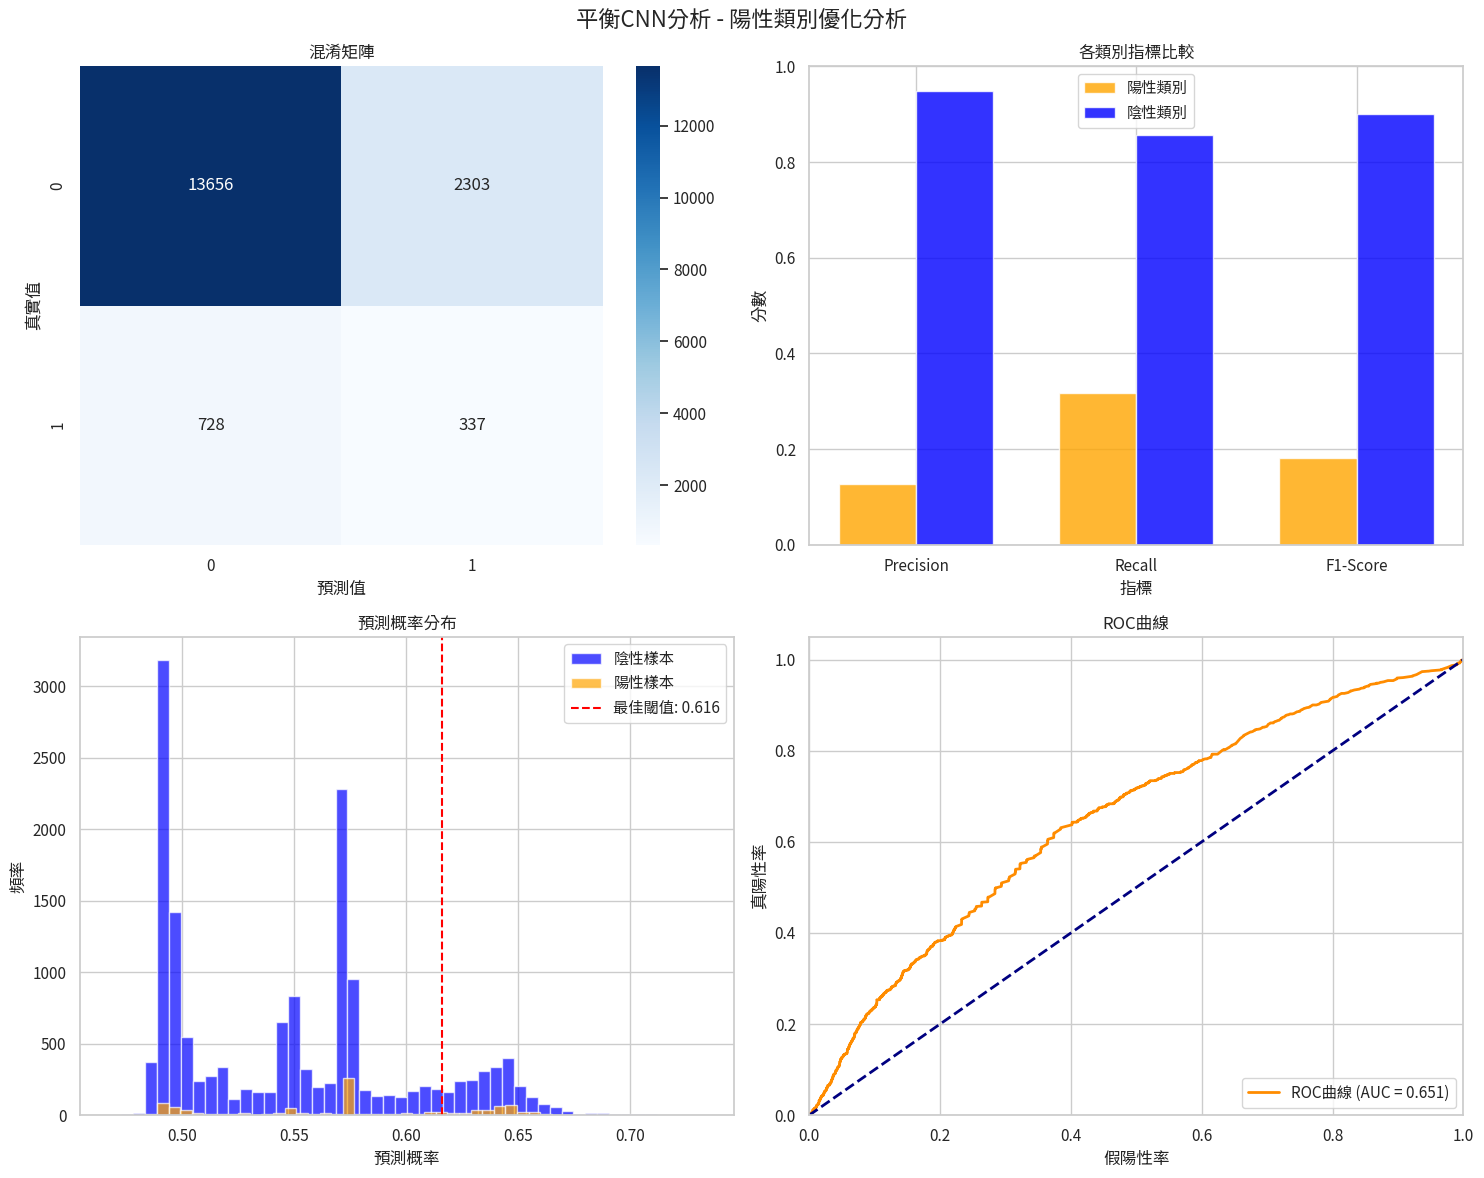


--- Training MLP Model ---

MLP Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 256)            │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,953 (242.00 KB)

 Trainable params: 61,185 (239.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/150
3372/3372 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5445 - auc: 0.6227 - loss: 0.3512 - precision: 0.4627 - recall: 0.7048
Epoch 1: val_auc improved from -inf to 0.72200, saving model to mlp_model.keras
3372/3372 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - accuracy: 0.5445 - auc: 0.6227 - loss: 0.3512 - precision: 0.4627 - recall: 0.7049 - val_accuracy: 0.4660 - val_auc: 0.7220 - val_loss: 0.1397 - val_precision: 0.0892 - val_recall: 0.8178 - learning_rate: 3.0000e-04
Epoch 2/150
3361/3372 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5828 - auc: 0.7078 - loss: 0.1308 - precision: 0.4952 - recall: 0.7927
Epoch 2: val_auc improved from 0.72200 to 0.72760, saving model to mlp_model.keras
3372/3372 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.5828 - auc: 0.7078 - loss: 0.1308 - precision: 0.4952 - recall: 0.7927 - val_accuracy: 0.4489 - val_auc: 0.7276 - val_loss: 0.1001 - val_precision: 0.0877 - val_recall: 0.8300 - learning_rate: 3.0000e-04
Epoch 3/150
3370/3372 ━━━━━━━━━━━

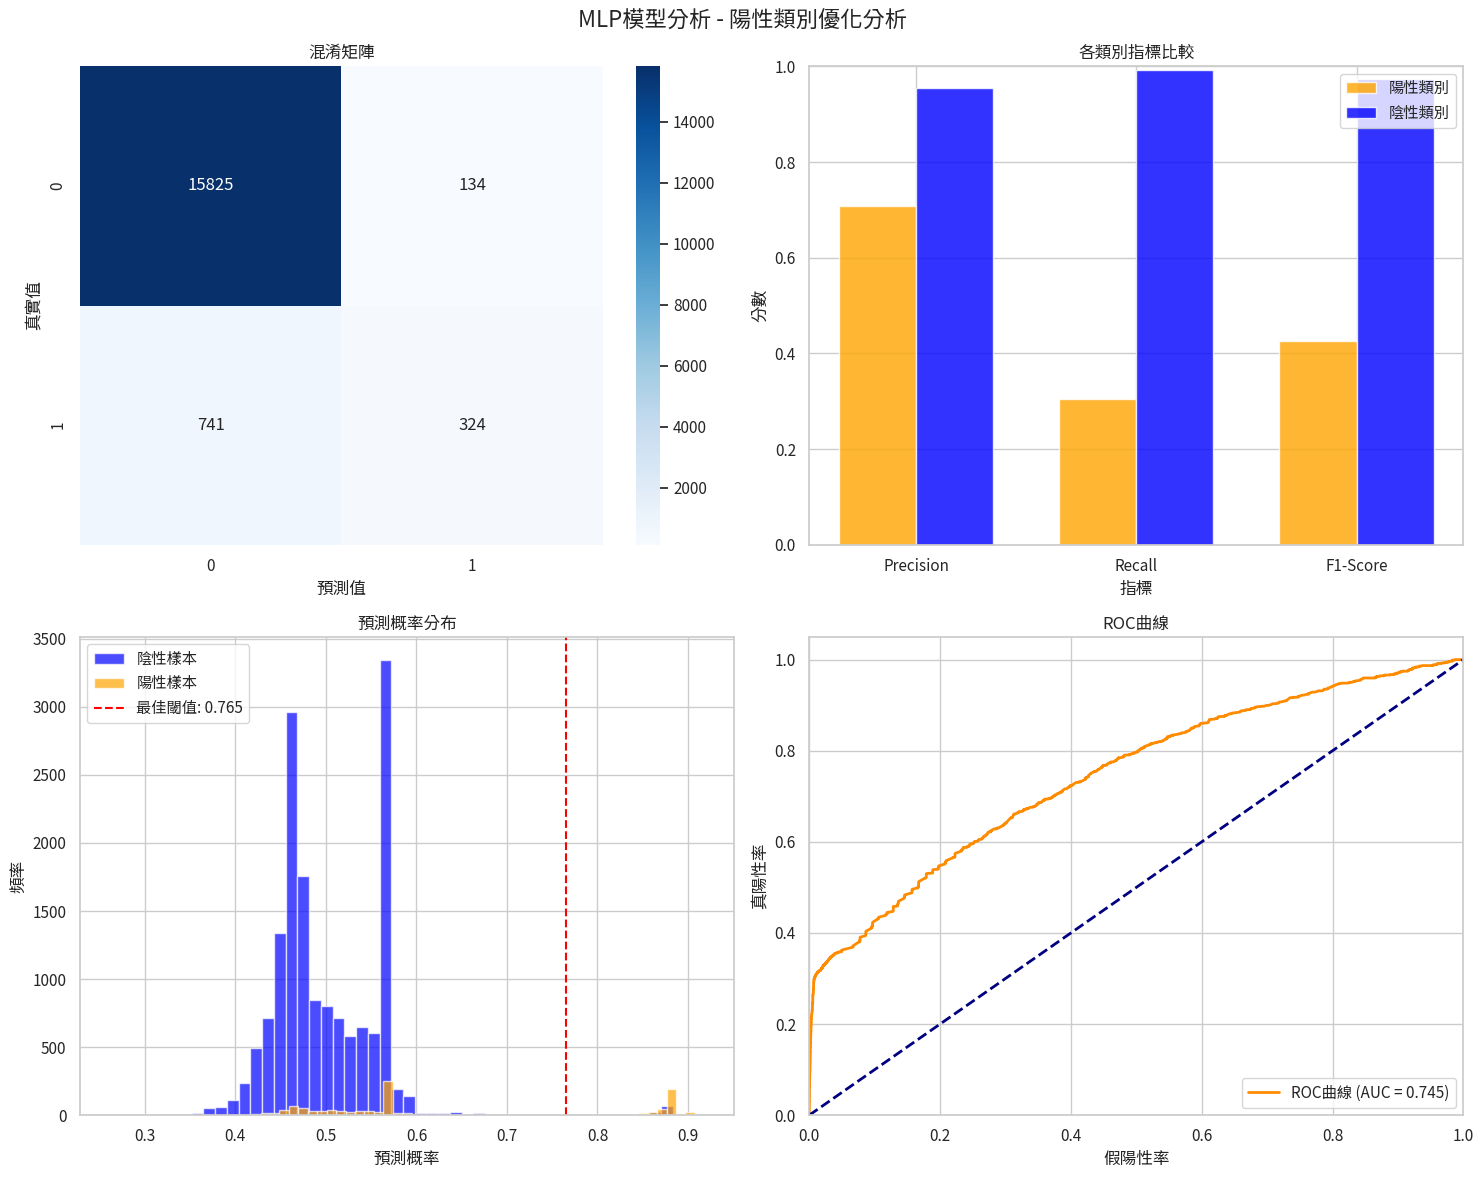

In [38]:
# Now proceed with the original model training and evaluation code

print("=" * 70)
print("🎯 Training and Evaluating Improved Models (CNN, MLP, LSTM, XGBoost, RandomForest)")
print("=" * 70)

# --- CNN Model ---
print("\n--- Training CNN Model ---")
cnn_model = optimizer.create_balanced_cnn(input_dim)
cnn_model.compile(**optimizer.get_improved_compile_config("focal")) # focal or weighted
print("\nBalanced CNN Architecture:")
cnn_model.summary()

cnn_history = cnn_model.fit(
    X_train_balanced, y_train_balanced,
    validation_data=(X_val_scaled, y_val_split),
    epochs=150,  # Increased epochs
    batch_size=32,  # Reduced batch size
    callbacks=optimizer.get_improved_callbacks("balanced_cnn_model.keras"),
    verbose=1
)

cnn_val_pred = cnn_model.predict(X_val_scaled).flatten()
cnn_threshold_info = optimize_threshold_for_positive_class_fixed(y_val_split, cnn_val_pred)
print("\n🔍 CNN Model Analysis:")
cnn_metrics = plot_positive_class_analysis(y_val_split, cnn_val_pred, cnn_threshold_info, "平衡CNN分析")

model_results["CNN"] = {
    "model": cnn_model,
    "val_predictions": cnn_val_pred,
    "threshold_info": cnn_threshold_info,
    "metrics": cnn_metrics,
    "training_config": {
        "epochs": 150,
        "batch_size": 32,
        "learning_rate": 0.0003,
        "loss": "focal",
        "sampling_strategy": "smote_tomek",
        "model_architecture": "balanced_cnn",
        "scaling_method": "robust",
    }
}


# --- MLP Model ---
print("\n--- Training MLP Model ---")
mlp_model = optimizer.create_mlp_model(input_dim)
mlp_model.compile(**optimizer.get_improved_compile_config("focal"))
print("\nMLP Architecture:")
mlp_model.summary()

mlp_history = mlp_model.fit(
    X_train_balanced, y_train_balanced,
    validation_data=(X_val_scaled, y_val_split),
    epochs=150,
    batch_size=32,
    callbacks=optimizer.get_improved_callbacks("mlp_model.keras"),
    verbose=1
)

mlp_val_pred = mlp_model.predict(X_val_scaled).flatten()
mlp_threshold_info = optimize_threshold_for_positive_class_fixed(y_val_split, mlp_val_pred)
print("\n🔍 MLP Model Analysis:")
mlp_metrics = plot_positive_class_analysis(y_val_split, mlp_val_pred, mlp_threshold_info, "MLP模型分析")

model_results["MLP"] = {
    "model": mlp_model,
    "val_predictions": mlp_val_pred,
    "threshold_info": mlp_threshold_info,
    "metrics": mlp_metrics,
    "training_config": {
        "epochs": 150,
        "batch_size": 32,
        "learning_rate": 0.0003,
        "loss": "focal",
        "sampling_strategy": "smote_tomek",
        "model_architecture": "mlp",
        "scaling_method": "robust",
    }
}





--- Training LSTM Model ---

LSTM Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_3 (Reshape)             │ (None, 74, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 74, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 74, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 74, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,913 (120.75 KB)

 Trainable params: 30,657 (119.75 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/150
3372/3372 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4950 - auc: 0.5303 - loss: 0.2816 - precision: 0.4276 - recall: 0.6791
Epoch 1: val_auc improved from -inf to 0.62401, saving model to lstm_model.keras
3372/3372 ━━━━━━━━━━━━━━━━━━━━ 67s 17ms/step - accuracy: 0.4950 - auc: 0.5303 - loss: 0.2816 - precision: 0.4276 - recall: 0.6792 - val_accuracy: 0.2159 - val_auc: 0.6240 - val_loss: 0.1317 - val_precision: 0.0685 - val_recall: 0.9155 - learning_rate: 3.0000e-04
Epoch 2/150
3369/3372 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4957 - auc: 0.6145 - loss: 0.1303 - precision: 0.4434 - recall: 0.8904
Epoch 2: val_auc improved from 0.62401 to 0.63162, saving model to lstm_model.keras
3372/3372 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - accuracy: 0.4957 - auc: 0.6145 - loss: 0.1303 - precision: 0.4434 - recall: 0.8904 - val_accuracy: 0.3994 - val_auc: 0.6316 - val_loss: 0.0988 - val_precision: 0.0775 - val_recall: 0.7887 - learning_rate: 3.0000e-04
Epoch 3/150
3370/3372 ━━━━━

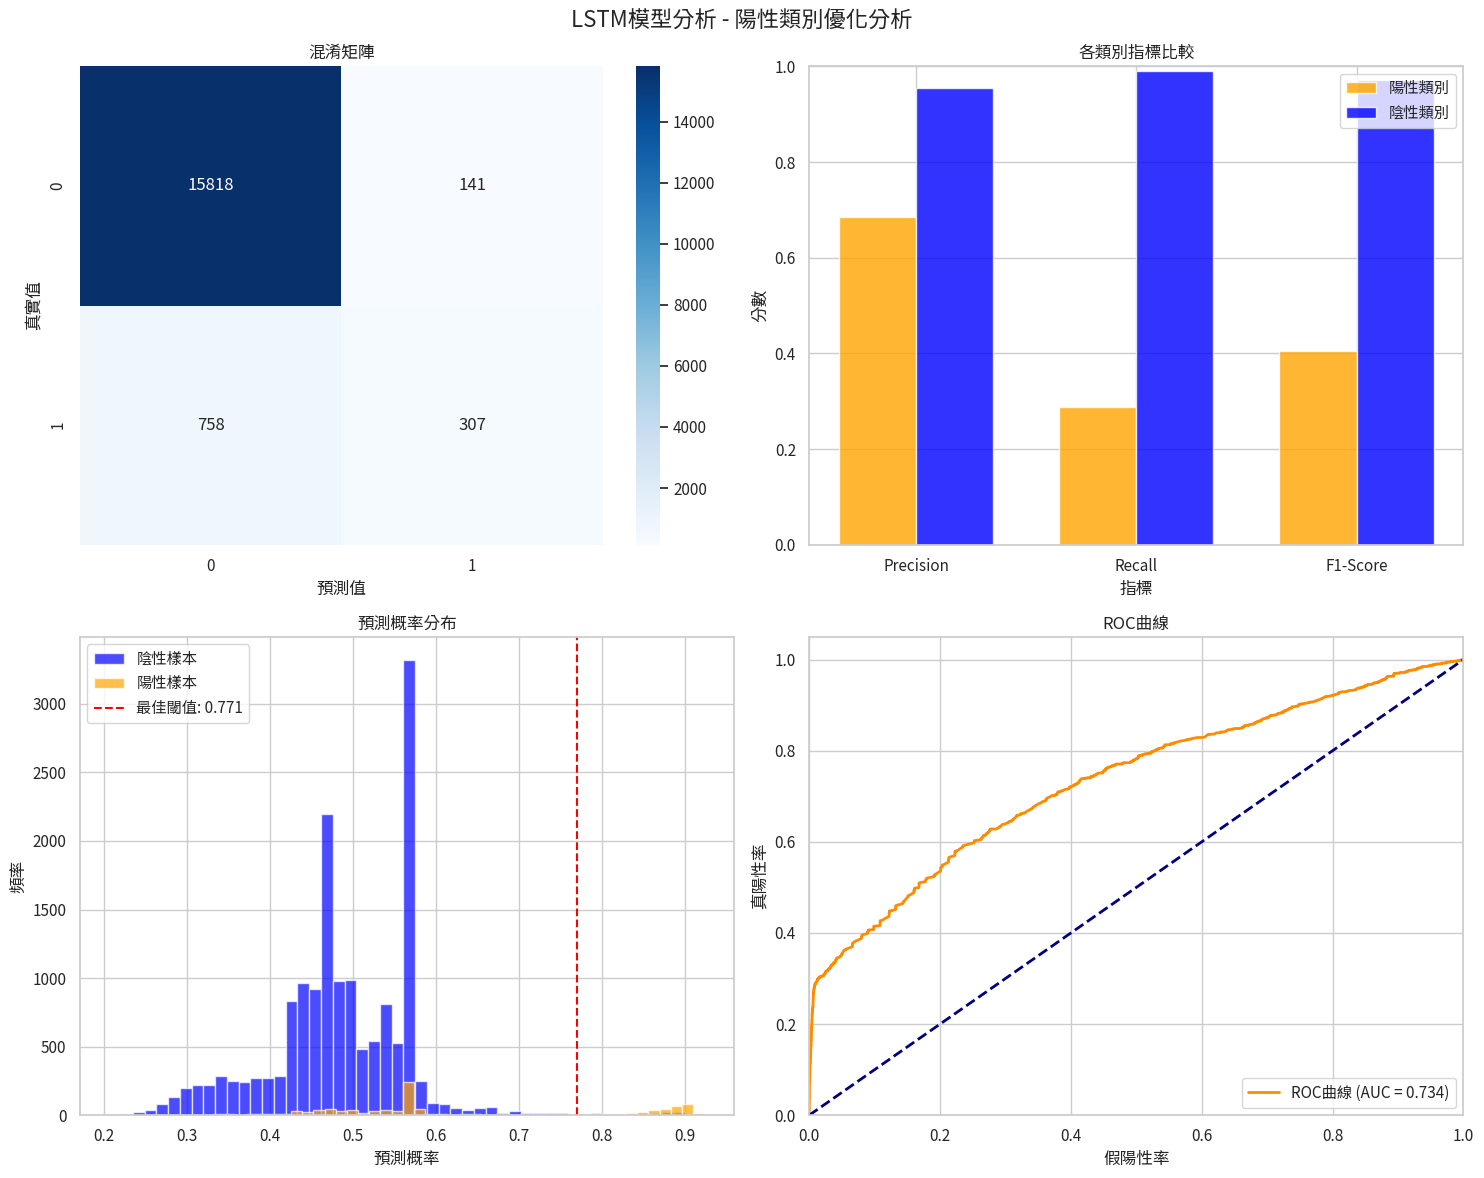

In [39]:
# --- LSTM Model ---
print("\n--- Training LSTM Model ---")

# Do not redefine optimizer.create_lstm_model here, use the one defined in the class (cell XzqvenMfXQ7b)
lstm_model = optimizer.create_lstm_model(input_dim)
lstm_model.compile(**optimizer.get_improved_compile_config("focal"))
print("\nLSTM Architecture:")
lstm_model.summary()

lstm_history = lstm_model.fit(
    X_train_balanced, y_train_balanced, # Corrected: Use reshaped X_train and expanded y_train
    validation_data=(X_val_scaled, y_val_split), # Corrected: Use reshaped X_val and expanded y_val
    epochs=150,
    batch_size=32,
    callbacks=optimizer.get_improved_callbacks("lstm_model.keras"),
    verbose=1
)

lstm_val_pred = lstm_model.predict(X_val_scaled).flatten()
lstm_threshold_info = optimize_threshold_for_positive_class_fixed(y_val_split, lstm_val_pred)
print("\n🔍 LSTM Model Analysis:")
lstm_metrics = plot_positive_class_analysis(y_val_split, lstm_val_pred, lstm_threshold_info, "LSTM模型分析")

model_results["LSTM"] = {
    "model": lstm_model,
    "val_predictions": lstm_val_pred,
    "threshold_info": lstm_threshold_info,
    "metrics": lstm_metrics,
    "training_config": {
        "epochs": 150,
        "batch_size": 32,
        "learning_rate": 0.0003,
        "loss": "focal",
        "sampling_strategy": "smote_tomek",
        "model_architecture": "lstm",
        "scaling_method": "robust",
    }
}


--- Training XGBoost Model ---
[0]	validation_0-aucpr:0.32471
[1]	validation_0-aucpr:0.33740
[2]	validation_0-aucpr:0.33778
[3]	validation_0-aucpr:0.33791
[4]	validation_0-aucpr:0.33837
[5]	validation_0-aucpr:0.34179
[6]	validation_0-aucpr:0.34067
[7]	validation_0-aucpr:0.34074
[8]	validation_0-aucpr:0.34083
[9]	validation_0-aucpr:0.34085
[10]	validation_0-aucpr:0.34044
[11]	validation_0-aucpr:0.34572
[12]	validation_0-aucpr:0.34559
[13]	validation_0-aucpr:0.34683
[14]	validation_0-aucpr:0.34608
[15]	validation_0-aucpr:0.34604
[16]	validation_0-aucpr:0.34612
[17]	validation_0-aucpr:0.34608
[18]	validation_0-aucpr:0.34534
[19]	validation_0-aucpr:0.34699
[20]	validation_0-aucpr:0.34700
[21]	validation_0-aucpr:0.34701
[22]	validation_0-aucpr:0.34706
[23]	validation_0-aucpr:0.34758
[24]	validation_0-aucpr:0.34753
[25]	validation_0-aucpr:0.34799
[26]	validation_0-aucpr:0.34878
[27]	validation_0-aucpr:0.34881
[28]	validation_0-aucpr:0.34926
[29]	validation_0-aucpr:0.34947
[30]	validation_0-

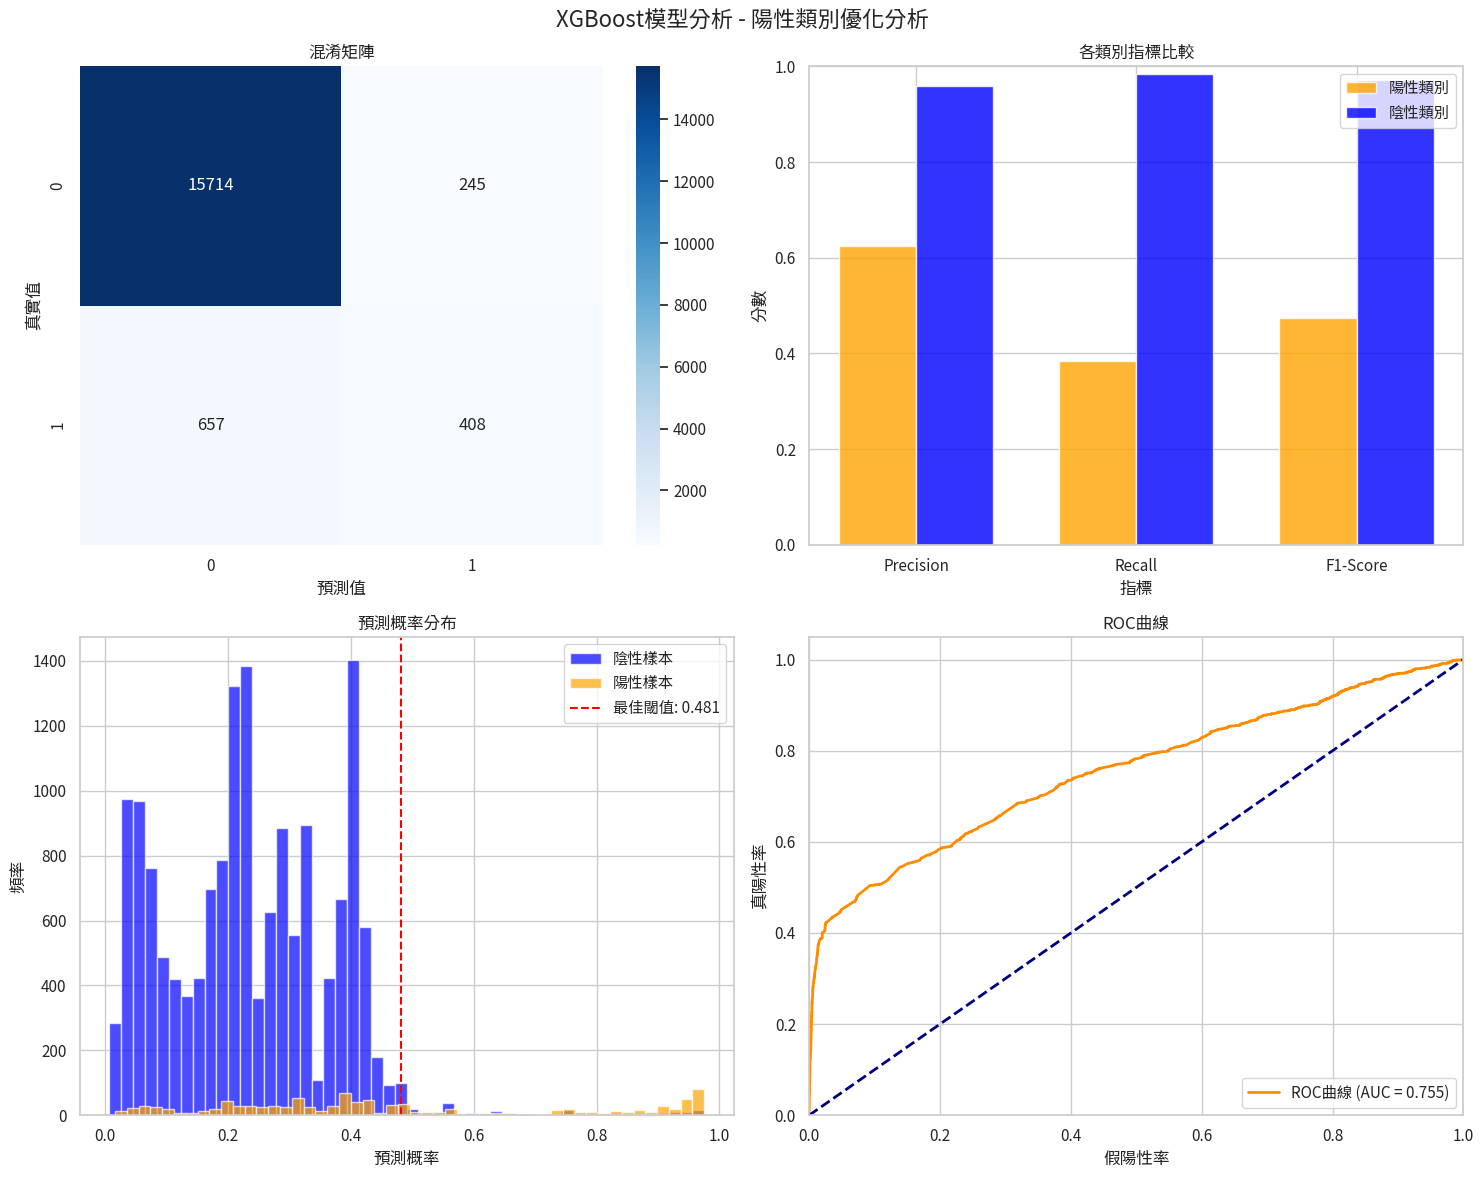

In [40]:
# --- XGBoost Model ---
print("\n--- Training XGBoost Model ---")
xgb_model = optimizer.create_xgboost_model(input_dim,scale_pos_weight=1)

# Convert NumPy arrays to DataFrames with feature names for tree-based models
# Make sure optimizer.feature_names is correctly set from advanced_feature_engineering
if optimizer.feature_names is None:
    raise ValueError("Feature names are not set in the optimizer. Please ensure advanced_feature_engineering is run correctly.")

X_train_balanced_df = pd.DataFrame(X_train_balanced, columns=optimizer.feature_names)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=optimizer.feature_names) # Use X_val_scaled here

xgb_model.fit(X_train_balanced_df, y_train_balanced,
              eval_set=[(X_val_scaled_df, y_val_split)])

xgb_val_pred = xgb_model.predict_proba(X_val_scaled_df)[:, 1].flatten()
xgb_threshold_info = optimize_threshold_for_positive_class_fixed(y_val_split, xgb_val_pred)
print("\n🔍 XGBoost Model Analysis:")
xgb_metrics = plot_positive_class_analysis(y_val_split, xgb_val_pred, xgb_threshold_info, "XGBoost模型分析")

model_results["XGBoost"] = {
    "model": xgb_model,
    "val_predictions": xgb_val_pred,
    "threshold_info": xgb_threshold_info,
    "metrics": xgb_metrics,
    "training_config": {
        "n_estimators": 413,
        "learning_rate": 0.02148,
        "max_depth": 6,
        "sampling_strategy": "smote_tomek", # Note: XGBoost is trained on resampled data
        "model_architecture": "xgboost",
        "scaling_method": "robust",
    }
}




--- Training Random Forest Model ---

🔍 Random Forest Model Analysis:


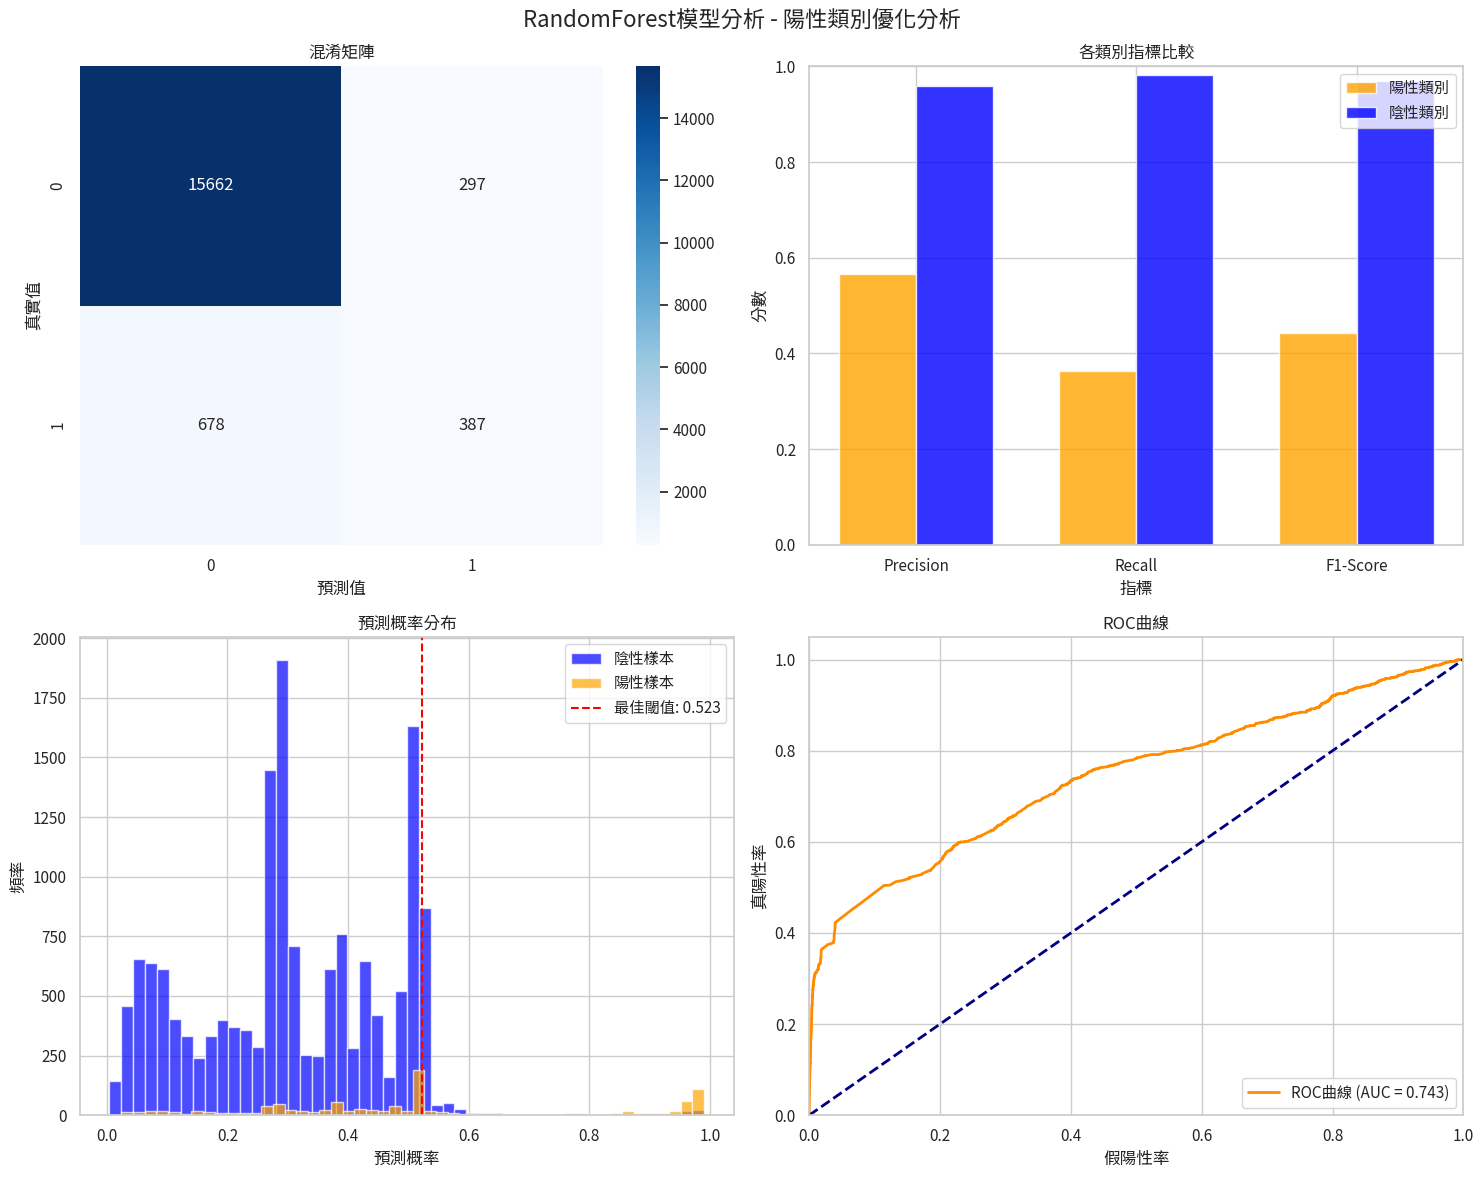


✅ All models trained and evaluated.


In [41]:
# --- Random Forest Model ---
print("\n--- Training Random Forest Model ---")
rf_model = optimizer.create_random_forest_model(input_dim)
# Random Forest does not use Keras-style compile/fit with callbacks. It has its own fit method.
rf_model.fit(X_train_balanced_df, y_train_balanced)

rf_val_pred = rf_model.predict_proba(X_val_scaled_df)[:, 1].flatten()
rf_threshold_info = optimize_threshold_for_positive_class_fixed(y_val_split, rf_val_pred)
print("\n🔍 Random Forest Model Analysis:")
rf_metrics = plot_positive_class_analysis(y_val_split, rf_val_pred, rf_threshold_info, "RandomForest模型分析")

model_results["RandomForest"] = {
    "model": rf_model,
    "val_predictions": rf_val_pred,
    "threshold_info": rf_threshold_info,
    "metrics": rf_metrics,
    "training_config": {
        "n_estimators": 500,
        "max_depth": 15,
        "sampling_strategy": "smote_tomek", # Note: Random Forest is trained on resampled data
        "model_architecture": "random_forest",
        "scaling_method": "robust",
    }
}

print("\n✅ All models trained and evaluated.")

## 8.1 定義 `retrain_and_update_model` 函數

In [ ]:
from datetime import datetime

def retrain_and_update_model(
    model_type: str,
    optimizer: 'ImprovedPositiveClassOptimizer', # Assuming ImprovedPositiveClassOptimizer instance
    input_dim: int,
    X_train_balanced: np.ndarray,
    y_train_balanced: np.ndarray,
    X_val_scaled: np.ndarray,
    y_val_split: np.ndarray,
    model_results: dict,
    manager: 'ModelPersistenceManager',
    retrain_tag: str = "retrain",
    epochs: int = 150,
    batch_size: int = 32,
    learning_rate: float = 0.0003,
    loss_type: str = "focal",
    sampling_strategy: str = "smote_tomek",
    scale_pos_weight: float = 1 # For XGBoost
):
    """
    針對指定模型類型進行重新訓練，更新 model_results，並保存新訓練的模型。

    Args:
        model_type (str): 要重新訓練的模型類型 ('CNN', 'MLP', 'LSTM', 'XGBoost', 'RandomForest')。
        optimizer (ImprovedPositiveClassOptimizer): 數據預處理和模型創建的優化器實例。
        input_dim (int): 特徵維度。
        X_train_balanced (np.ndarray): 平衡後的訓練特徵數據。
        y_train_balanced (np.ndarray): 平衡後的訓練目標數據。
        X_val_scaled (np.ndarray): 驗證集特徵數據。
        y_val_split (np.ndarray): 驗證集目標數據。
        model_results (dict): 存儲所有模型結果的字典。
        manager (ModelPersistenceManager): 模型持久化管理器實例。
        retrain_tag (str): 重新訓練的標籤，用於生成保存的模型名稱。
        epochs (int): 訓練 epochs 數。
        batch_size (int): 訓練 batch size。
        learning_rate (float): 學習率。
        loss_type (str): Keras 模型的損失函數類型 (e.g., 'focal', 'binary_crossentropy')。
        sampling_strategy (str): 數據採樣策略。
        scale_pos_weight (float): XGBoost 的正類別權重。
    """
    print(f"\n{'='*70}")
    print(f"🎯 Retraining and Updating {model_type} Model ({retrain_tag})")
    print(f"{'='*70}")

    new_model = None
    val_pred = None
    training_config = {
        "epochs": epochs,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "loss": loss_type,
        "sampling_strategy": sampling_strategy,
        "model_architecture": model_type.lower(),
        "scaling_method": "robust",
        "retrain_tag": retrain_tag,
        "timestamp": datetime.now().isoformat()
    }

    # Prepare Keras compile config and callbacks
    compile_config = optimizer.get_improved_compile_config(loss_type=loss_type)
    callbacks = optimizer.get_improved_callbacks(f"{model_type.lower()}_model_{retrain_tag}.keras")

    if model_type == "CNN":
        new_model = optimizer.create_balanced_cnn(input_dim)
        new_model.compile(**compile_config)
        print("\nBalanced CNN Architecture:")
        new_model.summary()

        new_model.fit(
            X_train_balanced, y_train_balanced,
            validation_data=(X_val_scaled, y_val_split),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )
        val_pred = new_model.predict(X_val_scaled).flatten()

    elif model_type == "MLP":
        new_model = optimizer.create_mlp_model(input_dim)
        new_model.compile(**compile_config)
        print("\nMLP Architecture:")
        new_model.summary()

        new_model.fit(
            X_train_balanced, y_train_balanced,
            validation_data=(X_val_scaled, y_val_split),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )
        val_pred = new_model.predict(X_val_scaled).flatten()

    elif model_type == "LSTM":
        new_model = optimizer.create_lstm_model(input_dim)
        new_model.compile(**compile_config)
        print("\nLSTM Architecture:")
        new_model.summary()

        # Reshape data for LSTM (samples, timesteps, features)
        X_train_lstm = np.reshape(X_train_balanced, (X_train_balanced.shape[0], X_train_balanced.shape[1], 1))
        X_val_lstm = np.reshape(X_val_scaled, (X_val_scaled.shape[0], X_val_scaled.shape[1], 1))
        y_train_balanced_expanded = np.expand_dims(y_train_balanced, axis=-1)
        y_val_split_expanded = np.expand_dims(y_val_split, axis=-1)

        new_model.fit(
            X_train_lstm, y_train_balanced_expanded,
            validation_data=(X_val_lstm, y_val_split_expanded),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )
        val_pred = new_model.predict(X_val_lstm).flatten()

    elif model_type == "XGBoost":
        # Convert inputs to DataFrame with feature names for tree-based models
        X_train_balanced_df = pd.DataFrame(X_train_balanced, columns=optimizer.feature_names)
        X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=optimizer.feature_names)

        new_model = optimizer.create_xgboost_model(input_dim, scale_pos_weight=scale_pos_weight)
        new_model.fit(X_train_balanced_df, y_train_balanced,
                      eval_set=[(X_val_scaled_df, y_val_split)],
                      verbose=False)
        val_pred = new_model.predict_proba(X_val_scaled_df)[:, 1].flatten()

    elif model_type == "RandomForest":
        # Convert inputs to DataFrame with feature names for tree-based models
        X_train_balanced_df = pd.DataFrame(X_train_balanced, columns=optimizer.feature_names)
        X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=optimizer.feature_names)

        new_model = optimizer.create_random_forest_model(input_dim)
        new_model.fit(X_train_balanced_df, y_train_balanced)
        val_pred = new_model.predict_proba(X_val_scaled_df)[:, 1].flatten()

    else:
        print(f"⚠️ 未知模型類型: {model_type}。跳過重新訓練。")
        return

    if new_model and val_pred is not None:
        # Optimize threshold and get metrics
        threshold_info = optimize_threshold_for_positive_class_fixed(y_val_split, val_pred)
        metrics = plot_positive_class_analysis(y_val_split, val_pred, threshold_info, f"{model_type}模型分析 ({retrain_tag})")

        # Update model_results
        model_results[model_type] = {
            "model": new_model,
            "val_predictions": val_pred,
            "threshold_info": threshold_info,
            "metrics": metrics,
            "training_config": training_config
        }

        # Save the newly trained model with a versioned name
        model_name_for_saving = f"improved_multi_model_{model_type.lower()}_{retrain_tag}"
        model_type_str = "keras" if isinstance(new_model, tf.keras.models.Model) else "pickle"
        manager.save_model(new_model, model_name_for_saving, model_type_str)
        manager.save_training_config(training_config, model_name_for_saving)
        manager.save_threshold_info(threshold_info, model_name_for_saving)

        print(f"\n✅ {model_type} 模型重新訓練完成，結果已更新並保存。")
    else:
        print(f"❌ {model_type} 模型重新訓練失敗。")


## 8.2 呼叫 retrain_and_update_model 函數範例
您可以選擇重新訓練任一模型，例如重新訓練 XGBoost 模型，並給它一個新的 retrain_tag：

注意：執行此 Cell 將會執行模型訓練，可能需要一些時間。您可以根據需要更改 model_type 或其他參數。


🎯 Retraining and Updating RandomForest Model (v2)


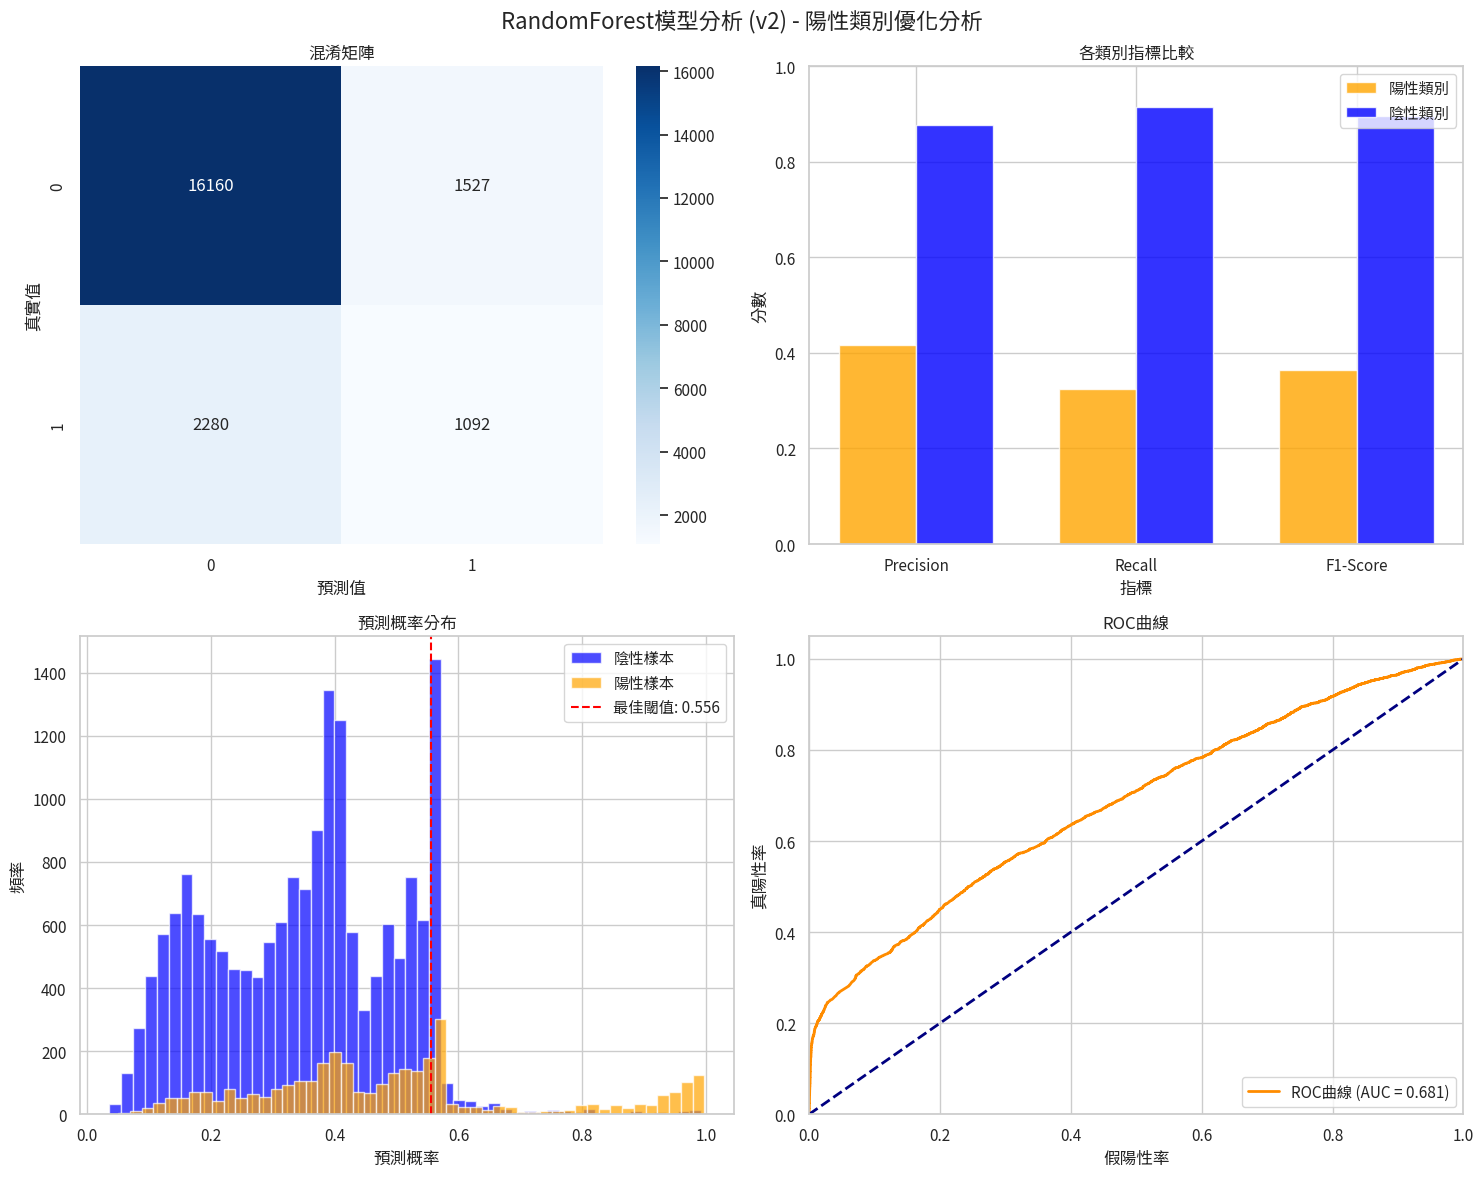

✓ pickle模型已保存到: ./saved_models/improved_multi_model_randomforest_v2/model.pkl
✓ 訓練配置已保存到: ./saved_models/improved_multi_model_randomforest_v2/training_config.json
✓ 閾值信息已保存到: ./saved_models/improved_multi_model_randomforest_v2/threshold_info.json

✅ RandomForest 模型重新訓練完成，結果已更新並保存。


In [ ]:
# 確保所有必要的變數都在作用域中 (例如 optimizer, input_dim, X_train_balanced, etc.)
# 如果這些變數未定義，請先執行之前的數據預處理和模型訓練 Cell。

# 重新訓練 XGBoost 模型，並使用 'v2' 作為標籤
# 注意：X_train_balanced_df 和 X_val_scaled_df 在 retrain_and_update_model 內部處理
retrain_and_update_model(
    model_type="RandomForest",
    optimizer=optimizer,
    input_dim=input_dim,
    X_train_balanced=X_train_balanced,
    y_train_balanced=y_train_balanced,
    X_val_scaled=X_val_scaled,
    y_val_split=y_val_split,
    model_results=model_results,
    manager=manager,
    retrain_tag="v2",
    epochs=200, # For XGBoost, this is n_estimators
    learning_rate=0.01,
    scale_pos_weight=1.5 # 範例調整參數
)

# 您也可以重新訓練其他模型，例如 CNN:
# retrain_and_update_model(
#     model_type="CNN",
#     optimizer=optimizer,
#     input_dim=input_dim,
#     X_train_balanced=X_train_balanced,
#     y_train_balanced=y_train_balanced,
#     X_val_scaled=X_val_scaled,
#     y_val_split=y_val_split,
#     model_results=model_results,
#     manager=manager,
#     retrain_tag="epoch_200_lr_0.001",
#     epochs=200, # 調整 Keras 模型的 epoch
#     learning_rate=0.001,
#     loss_type="focal"
# )

## 9. 保存完整的訓練管道及下載

In [42]:
import os
from google.colab import files # Keep for download

# Assuming model_results dictionary is available from the training cell.
# Assuming optimizer (feature_processor) is available from preprocessing cells.

manager = ModelPersistenceManager()
model_name_prefix = "improved_multi_model" # Use a common prefix for this pipeline run

# The model_results dictionary should contain the trained models and their info
# from the training cell (cell_id: train_and_evaluate)
# model_results = {
#     "CNN": {"model": cnn_model, "training_config": cnn_training_config, "threshold_info": cnn_threshold_info},
#     "MLP": {"model": mlp_model, "training_config": mlp_training_config, "threshold_info": mlp_threshold_info},
#     "LSTM": {"model": lstm_model, "training_config": lstm_training_config, "threshold_info": lstm_threshold_info}
# }

success = manager.save_complete_pipeline(
    optimizer, model_results, model_name_prefix
)

if success:
    print("\n🎉 完整訓練管道保存成功！")
    # 列出已保存的模型組
    manager.list_saved_models()
else:
    print("\n❌ 保存過程中出現問題")


🔄 Saving complete pipeline components with prefix: improved_multi_model
✓ 特徵處理器已保存到: ./saved_models/improved_multi_modelcommon_processor
✓ Keras模型已保存到: ./saved_models/improved_multi_modelcnn_model/model.keras
✓ 模型架構已保存到: ./saved_models/improved_multi_modelcnn_model/model_architecture.json
✓ 訓練配置已保存到: ./saved_models/improved_multi_modelcnn_model/training_config.json
✓ 閾值信息已保存到: ./saved_models/improved_multi_modelcnn_model/threshold_info.json
✓ Keras模型已保存到: ./saved_models/improved_multi_modelmlp_model/model.keras
✓ 模型架構已保存到: ./saved_models/improved_multi_modelmlp_model/model_architecture.json
✓ 訓練配置已保存到: ./saved_models/improved_multi_modelmlp_model/training_config.json
✓ 閾值信息已保存到: ./saved_models/improved_multi_modelmlp_model/threshold_info.json
✓ Keras模型已保存到: ./saved_models/improved_multi_modellstm_model/model.keras
✓ 模型架構已保存到: ./saved_models/improved_multi_modellstm_model/model_architecture.json
✓ 訓練配置已保存到: ./saved_models/improved_multi_modellstm_model/training_config.json
✓ 閾值信息已保存到: 

In [43]:
import os
from google.colab import files

# 壓縮文件和目錄
zip_filename = "model_and_predictions.zip"
# 檢查 balanced_cnn_model.keras 是否存在於 saved_models/improved_balanced_cnn 目錄下
if os.path.exists("./saved_models/improved_balanced_cnn/balanced_cnn_model.keras"):
    !zip -r {zip_filename} saved_models/improved_balanced_cnn balanced_cnn_model.keras improved_predictions_improved_balanced_cnn.csv
elif os.path.exists("./balanced_cnn_model.keras"):
    # 如果 balanced_cnn_model.keras 直接在根目錄，則只壓縮 saved_models 和 improved_predictions_improved_balanced_cnn.csv
    !zip -r {zip_filename} saved_models improved_predictions_improved_balanced_cnn.csv balanced_cnn_model.keras
else:
    # 如果 balanced_cnn_model.keras 不存在，則只壓縮 saved_models 和 improved_predictions_improved_balanced_cnn.csv
    print("警告: balanced_cnn_model.keras 未找到，只壓縮 saved_models 目錄和 improved_predictions_improved_balanced_cnn.csv 文件。")
    !zip -r {zip_filename} saved_models improved_predictions_improved_balanced_cnn.csv


# 下載zip文件
files.download(zip_filename)

print(f"\n✅ 文件 '{zip_filename}' 已創建並自動下載。")

	zip warning: name not matched: improved_predictions_improved_balanced_cnn.csv
updating: saved_models/ (stored 0%)
updating: saved_models/improved_multi_modelcommon_processor/ (stored 0%)
updating: saved_models/improved_multi_modelcommon_processor/feature_processor.pkl (deflated 50%)
updating: saved_models/improved_multi_modelcommon_processor/feature_processor_config.json (deflated 60%)
updating: saved_models/improved_multi_modelrandomforest_model/ (stored 0%)
updating: saved_models/improved_multi_modelrandomforest_model/model.pkl (deflated 66%)
updating: saved_models/improved_multi_modelrandomforest_model/training_config.json (deflated 26%)
updating: saved_models/improved_multi_modelrandomforest_model/model_metadata.json (deflated 24%)
updating: saved_models/improved_multi_modelrandomforest_model/threshold_info.json (deflated 47%)
updating: saved_models/improved_multi_modellstm_model/ (stored 0%)
updating: saved_models/improved_multi_modellstm_model/training_config.json (deflated 31%)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ 文件 'model_and_predictions.zip' 已創建並自動下載。


## 10. 加載模型並進行預測

In [ ]:
import os
from google.colab import files
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras import backend as K

# Define the custom focal loss function again (from cell 'improved_positive_optimizer')
@register_keras_serializable()
def improved_focal_loss(alpha=0.7, gamma=1.5):
    @register_keras_serializable()
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

        ce = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)

        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)

        fl = alpha_t * K.pow(1 - pt, gamma) * ce
        return K.mean(fl)

    # Return the inner function
    return focal_loss_fixed


# Assuming ModelPersistenceManager class is defined and available.
# Assuming pred_df DataFrame is available from data loading cell.
pred_df = pd.read_csv("/content/forPredict_inSameShape_byBill_202506_final.csv")

# 加載模型並進行預測
manager = ModelPersistenceManager()
model_name_prefix = "improved_multi_model" # Use the same prefix as saving

# Pass the custom objects to load_model
custom_objects = {
    'focal_loss_fixed': improved_focal_loss(alpha=0.7, gamma=1.5) # Pass the configured loss function
}

loaded_pipeline = manager.load_complete_pipeline(model_name_prefix)

if loaded_pipeline["success"]:
    print("\n🔮 使用加載的管道進行預測...")

    # Iterate through available models and perform prediction
    available_models = loaded_pipeline["model_results"].keys()
    print(f"Available models for prediction: {list(available_models)}")

    for model_to_use in available_models:
        print(f"\n--- Predicting with {model_to_use} Model ---")

        predictions = manager.predict_with_saved_model(model_name_prefix, pred_df, model_type=model_to_use)

        if predictions["success"]:
            # Analyze prediction results distribution
            proba_array = np.array(predictions["probabilities"])
            binary_array = np.array(predictions["binary_predictions"])

            print(f"\n📊 預測結果分析 (使用 {model_to_use} 模型):")
            print(f"  總樣本數: {predictions['num_samples']:,}")
            print(f"  陽性預測數: {predictions['positive_predictions']:,}")
            print(f"  陽性預測比例: {predictions['positive_predictions']/predictions['num_samples']*100:.2f}%")
            print(f"  使用閾值: {predictions['threshold_used']:.4f}")

            # Probability distribution statistics
            print(f"\n📈 概率分布統計 (使用 {model_to_use} 模型):")
            print(f"  最小值: {np.min(proba_array):.4f}")
            print(f"  最大值: {np.max(proba_array):.4f}")
            print(f"  平均值: {np.mean(proba_array):.4f}")
            print(f"  中位數: {np.median(proba_array):.4f}")
            print(f"  標準差: {np.std(proba_array):.4f}")

            # Check extreme value ratio
            extreme_low = np.sum(proba_array < 0.01) / len(proba_array) * 100
            extreme_high = np.sum(proba_array > 0.99) / len(proba_array) * 100
            middle_range = np.sum((proba_array >= 0.1) & (proba_array <= 0.9)) / len(proba_array) * 100

            print(f"\n🎯 概率分布健康度檢查 (使用 {model_to_use} 模型):")
            print(f"  極低概率 (<0.01): {extreme_low:.2f}%")
            print(f"  極高概率 (>0.99): {extreme_high:.2f}%")
            print(f"  中間範圍 (0.1-0.9): {middle_range:.2f}%")

            if extreme_low + extreme_high < 30:  # Extreme value ratio less than 30%
                print("  ✅ Probability distribution is healthy, avoiding excessive deviation issues")
            else:
                print("  ⚠️ Still some degree of probability deviation exists")

            # Create results DataFrame
            results_df = pred_df.copy() # Use original pred_df
            results_df[f"{model_to_use}_Probability"] = predictions["probabilities"]
            results_df[f"{model_to_use}_Binary_Prediction"] = predictions["binary_predictions"]
            results_df["Threshold_Used"] = predictions["threshold_used"]

            # Save to CSV
            output_filename = f"{model_name_prefix}_{model_to_use}_predictions.csv"
            results_df.to_csv(output_filename, index=False)

            print(f"\n✅ Prediction results saved to: {output_filename}")

            # Download result file
            try:
                files.download(output_filename)
                print(f"\n📥 File '{output_filename}' automatically downloaded to your computer")
            except Exception as e:
                print(f"\n❌ Automatic download failed: {e}. Please manually download the file: {output_filename}")


        else:
            print(f"\n❌ Prediction failed for {model_to_use} model: {predictions.get('error', 'Unknown error')}")

else:
    print("\n❌ Model loading failed, cannot proceed with prediction")


🔄 Loading complete pipeline components with prefix: improved_multi_model
✓ 特徵處理器已從 ./saved_models/improved_multi_modelcommon_processor/feature_processor.pkl 加載
✓ Keras模型已從 ./saved_models/improved_multi_modelcnn_model/model.keras 加載
✓ 訓練配置已從 ./saved_models/improved_multi_modelcnn_model/training_config.json 加載
✓ 閾值信息已從 ./saved_models/improved_multi_modelcnn_model/threshold_info.json 加載
✓ Keras模型已從 ./saved_models/improved_multi_modelmlp_model/model.keras 加載
✓ 訓練配置已從 ./saved_models/improved_multi_modelmlp_model/training_config.json 加載
✓ 閾值信息已從 ./saved_models/improved_multi_modelmlp_model/threshold_info.json 加載
✓ Keras模型已從 ./saved_models/improved_multi_modellstm_model/model.keras 加載
✓ 訓練配置已從 ./saved_models/improved_multi_modellstm_model/training_config.json 加載
✓ 閾值信息已從 ./saved_models/improved_multi_modellstm_model/threshold_info.json 加載
✓ pickle模型已從 ./saved_models/improved_multi_modelxgboost_model/model.pkl 加載
✓ 訓練配置已從 ./saved_models/improved_multi_modelxgboost_model/training_config.json 加

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 File 'improved_multi_model_CNN_predictions.csv' automatically downloaded to your computer

--- Predicting with MLP Model ---

🔮 Using saved pipeline with prefix 'improved_multi_model' for prediction using MLP model...

🔄 Loading complete pipeline components with prefix: improved_multi_model
✓ 特徵處理器已從 ./saved_models/improved_multi_modelcommon_processor/feature_processor.pkl 加載
✓ Keras模型已從 ./saved_models/improved_multi_modelcnn_model/model.keras 加載
✓ 訓練配置已從 ./saved_models/improved_multi_modelcnn_model/training_config.json 加載
✓ 閾值信息已從 ./saved_models/improved_multi_modelcnn_model/threshold_info.json 加載
✓ Keras模型已從 ./saved_models/improved_multi_modelmlp_model/model.keras 加載
✓ 訓練配置已從 ./saved_models/improved_multi_modelmlp_model/training_config.json 加載
✓ 閾值信息已從 ./saved_models/improved_multi_modelmlp_model/threshold_info.json 加載
✓ Keras模型已從 ./saved_models/improved_multi_modellstm_model/model.keras 加載
✓ 訓練配置已從 ./saved_models/improved_multi_modellstm_model/training_config.json 加載
✓ 閾值信息已從 ./s

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 File 'improved_multi_model_MLP_predictions.csv' automatically downloaded to your computer

--- Predicting with LSTM Model ---

🔮 Using saved pipeline with prefix 'improved_multi_model' for prediction using LSTM model...

🔄 Loading complete pipeline components with prefix: improved_multi_model
✓ 特徵處理器已從 ./saved_models/improved_multi_modelcommon_processor/feature_processor.pkl 加載
✓ Keras模型已從 ./saved_models/improved_multi_modelcnn_model/model.keras 加載
✓ 訓練配置已從 ./saved_models/improved_multi_modelcnn_model/training_config.json 加載
✓ 閾值信息已從 ./saved_models/improved_multi_modelcnn_model/threshold_info.json 加載
✓ Keras模型已從 ./saved_models/improved_multi_modelmlp_model/model.keras 加載
✓ 訓練配置已從 ./saved_models/improved_multi_modelmlp_model/training_config.json 加載
✓ 閾值信息已從 ./saved_models/improved_multi_modelmlp_model/threshold_info.json 加載
✓ Keras模型已從 ./saved_models/improved_multi_modellstm_model/model.keras 加載
✓ 訓練配置已從 ./saved_models/improved_multi_modellstm_model/training_config.json 加載
✓ 閾值信息已從 .

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 File 'improved_multi_model_LSTM_predictions.csv' automatically downloaded to your computer

--- Predicting with XGBoost Model ---

🔮 Using saved pipeline with prefix 'improved_multi_model' for prediction using XGBoost model...

🔄 Loading complete pipeline components with prefix: improved_multi_model
✓ 特徵處理器已從 ./saved_models/improved_multi_modelcommon_processor/feature_processor.pkl 加載
✓ Keras模型已從 ./saved_models/improved_multi_modelcnn_model/model.keras 加載
✓ 訓練配置已從 ./saved_models/improved_multi_modelcnn_model/training_config.json 加載
✓ 閾值信息已從 ./saved_models/improved_multi_modelcnn_model/threshold_info.json 加載
✓ Keras模型已從 ./saved_models/improved_multi_modelmlp_model/model.keras 加載
✓ 訓練配置已從 ./saved_models/improved_multi_modelmlp_model/training_config.json 加載
✓ 閾值信息已從 ./saved_models/improved_multi_modelmlp_model/threshold_info.json 加載
✓ Keras模型已從 ./saved_models/improved_multi_modellstm_model/model.keras 加載
✓ 訓練配置已從 ./saved_models/improved_multi_modellstm_model/training_config.json 加載
✓ 閾

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 File 'improved_multi_model_XGBoost_predictions.csv' automatically downloaded to your computer

--- Predicting with RandomForest Model ---

🔮 Using saved pipeline with prefix 'improved_multi_model' for prediction using RandomForest model...

🔄 Loading complete pipeline components with prefix: improved_multi_model
✓ 特徵處理器已從 ./saved_models/improved_multi_modelcommon_processor/feature_processor.pkl 加載
✓ Keras模型已從 ./saved_models/improved_multi_modelcnn_model/model.keras 加載
✓ 訓練配置已從 ./saved_models/improved_multi_modelcnn_model/training_config.json 加載
✓ 閾值信息已從 ./saved_models/improved_multi_modelcnn_model/threshold_info.json 加載
✓ Keras模型已從 ./saved_models/improved_multi_modelmlp_model/model.keras 加載
✓ 訓練配置已從 ./saved_models/improved_multi_modelmlp_model/training_config.json 加載
✓ 閾值信息已從 ./saved_models/improved_multi_modelmlp_model/threshold_info.json 加載
✓ Keras模型已從 ./saved_models/improved_multi_modellstm_model/model.keras 加載
✓ 訓練配置已從 ./saved_models/improved_multi_modellstm_model/training_confi

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 File 'improved_multi_model_RandomForest_predictions.csv' automatically downloaded to your computer


In [ ]:
import pandas as pd

# 載入 XGBoost 模型的預測結果檔案
xgb_predictions_df = pd.read_csv('improved_multi_model_XGBoost_predictions.csv')

print("XGBoost 預測結果 DataFrame 的前幾行 (XGBoost_Probability 欄位):")
display(xgb_predictions_df[['CUST_NO', 'XGBoost_Probability', 'XGBoost_Binary_Prediction']].head(10))

print("\n顯示 XGBoost_Probability 欄位中所有唯一值，以確認其連續性 (顯示前100個唯一值):")
display(xgb_predictions_df['XGBoost_Probability'].value_counts(normalize=True).head(100))

## 11. SHAP分析



### 1. 安裝 SHAP 函式庫

In [20]:
# 如果尚未安裝，請先安裝 SHAP
!pip install shap

import shap
print("SHAP 函式庫已載入。")

SHAP 函式庫已載入。


In [21]:
import xgboost as xgb
import shap

print(f"XGBoost version: {xgb.__version__}")
print(f"SHAP version: {shap.__version__}")

XGBoost version: 3.1.2
SHAP version: 0.50.0


### 2. 準備數據以計算 SHAP 值

我們將使用驗證集 `X_val_scaled` 的一小部分作為背景數據來計算 SHAP 值，以減少計算量並保持可讀性。對於深度學習模型，通常需要 `X_train_scaled` 的子集作為背景數據。

In [22]:
# 選擇驗證集的一個隨機子集來計算 SHAP 值，以減少計算時間
# 對於實際應用，您可能需要更大的樣本量。
# 這裡我們使用 100 個樣本來快速演示。

if 'X_val_scaled' in locals():
    # Convert X_val_scaled to DataFrame for easier feature naming if it's not already
    if hasattr(optimizer, 'feature_names') and optimizer.feature_names is not None:
        X_val_df = pd.DataFrame(X_val_scaled, columns=optimizer.feature_names)
    else:
        X_val_df = pd.DataFrame(X_val_scaled) # Fallback if feature_names not set

    # Use a smaller subset for faster calculation if the validation set is large
    if X_val_df.shape[0] > 1000:
        X_val_subset_for_shap = X_val_df.sample(n=1000, random_state=RANDOM_STATE)
    else:
        X_val_subset_for_shap = X_val_df.copy()

    print(f"用於 SHAP 分析的驗證集子集形狀: {X_val_subset_for_shap.shape}")
else:
    print("❌ X_val_scaled 未找到。請確保之前的數據預處理步驟已成功執行。")
    X_val_subset_for_shap = None


用於 SHAP 分析的驗證集子集形狀: (1000, 74)


### 3. 計算並可視化 XGBoost 模型的 SHAP 值

In [33]:
# -*- coding: utf-8 -*-
# 共用：XGBoost SHAP 解釋工具（KernelExplainer / XGBoost 原生 SHAP）
# 需求：xgboost, shap, numpy, pandas, matplotlib

from typing import Optional, Union, Dict, Any, List
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
import matplotlib.pyplot as plt


def _to_dataframe(X: Union[pd.DataFrame, np.ndarray], feature_names: Optional[List[str]] = None) -> pd.DataFrame:
    if isinstance(X, pd.DataFrame):
        return X.copy()
    return pd.DataFrame(X, columns=feature_names if feature_names is not None else None)


def explain_with_shap(
    model,
    X_eval: Union[pd.DataFrame, np.ndarray],
    mode: str = "xgb_native",                 # "xgb_native" 或 "kernel"
    feature_names: Optional[List[str]] = None,
    class_index: Optional[int] = None,        # 多分類要看的類別；None 代表自動（預設 1 或 0）
    do_plot: bool = True,                     # 是否直接畫圖（summary / bar / dependence / force）
    max_shap_display: int = 40,               # SHAP summary plot 最大顯示特徵數量

    # 只有 kernel 模式會用到的參數
    background_data: Optional[Union[pd.DataFrame, np.ndarray]] = None,
    max_background_k: int = 50,               # kmeans summary 的 K（20~100 之間選）
    kernel_nsamples: int = 2048,              # KernelExplainer 的近似抽樣數

    # 只有 xgb_native 會用到的參數
    drop_bias: bool = True,                   # 回傳與繪圖時是否移除最後一欄 bias/base
) -> Dict[str, Any]:
    """
    回傳：
    {
      "mode": str,
      "is_multiclass": bool,
      "class_names": Optional[List[str]],
      "feature_names": List[str],
      # kernel: np.ndarray 或 list[np.ndarray]；native: 同前
      "shap_values": Union[np.ndarray, List[np.ndarray]],
      # kernel: float 或 list[float]; native: np.ndarray 或 list[np.ndarray]（每筆/每類的 bias）
      "base_values": Union[float, List[float], np.ndarray, List[np.ndarray]],
      "expected_value": Optional[Union[float, List[float]]],  # 只有 kernel 提供
    }
    """
    assert mode in ("kernel", "xgb_native"), "mode 必須為 'kernel' 或 'xgb_native'"

    # ---- 準備 X_eval DF 與欄位名 ----
    X_eval_df = _to_dataframe(X_eval, feature_names)
    feature_names = list(X_eval_df.columns) if len(X_eval_df.columns) > 0 else None

    # 嘗試取得類別資訊
    n_classes = getattr(model, "n_classes_", None)
    is_classifier = hasattr(model, "predict_proba")

    # =========================================================
    # 路線 A：XGBoost 原生 SHAP（最穩、最快）
    # =========================================================
    if mode == "xgb_native":
        # 支援 sklearn API 的 XGBClassifier/Regressor 與原生 Booster
        if hasattr(model, "get_booster"):
            booster = model.get_booster()
        elif isinstance(model, xgb.Booster):
            booster = model
        else:
            raise TypeError("xgb_native 模式需要 XGBClassifier/XGBRegressor 或 xgb.Booster")

        dmatrix = xgb.DMatrix(X_eval_df.values, feature_names=feature_names)
        pred = booster.predict(dmatrix, pred_contribs=True)

        expected_value = None  # 原生路徑沒有 explainer.expected_value
        is_multiclass = (pred.ndim == 3)

        if not is_multiclass:
            # 回歸/二分類： pred: [n_samples, n_features+1]
            if drop_bias:
                shap_values = pred[:, :-1]
                base_values = pred[:, -1]
            else:
                shap_values = pred
                base_values = pred[:, -1]
            class_names = None

            if do_plot:
                plt.figure(figsize=(10, min(15, max(5, max_shap_display * 0.4)))) # 動態調整圖表高度
                shap.summary_plot(shap_values, X_eval_df, feature_names=feature_names, show=False, plot_type="dot", max_display=max_shap_display)
                plt.title("XGBoost Native SHAP Summary")
                plt.tight_layout(); plt.show()

                plt.figure(figsize=(10, min(15, max(5, max_shap_display * 0.4)))) # 動態調整圖表高度
                shap.summary_plot(shap_values, X_eval_df, feature_names=feature_names, show=False, plot_type="bar", max_display=max_shap_display)
                plt.title("XGBoost Native Mean |SHAP|")
                plt.tight_layout(); plt.show()

                # 依賴圖（取平均絕對值最高的特徵）
                if feature_names and len(feature_names) > 0:
                    top_idx = np.argsort(np.abs(shap_values).mean(axis=0))[::-1][0]
                    top_name = feature_names[top_idx]
                    shap.dependence_plot(top_name, shap_values, X_eval_df, show=False)
                    plt.title(f"Dependence Plot: {top_name}")
                    plt.tight_layout(); plt.show()
                else:
                    print("警告: 無法繪製依賴圖，因為沒有特徵名稱。")

        else:
            # 多分類： pred: [n_samples, n_features+1, n_classes]
            n_classes = pred.shape[2]
            class_names = [f"class_{k}" for k in range(n_classes)]
            shap_values = [pred[:, :-1, k] if drop_bias else pred[:, :, k] for k in range(n_classes)]
            base_values = [pred[:, -1, k] for k in range(n_classes)]

            # 選要看的類別繪圖
            k = class_index if (class_index is not None and 0 <= class_index < n_classes) else (1 if n_classes > 1 else 0)
            if do_plot:
                plt.figure(figsize=(10, min(15, max(5, max_shap_display * 0.4)))) # 動態調整圖表高度
                shap.summary_plot(shap_values[k], X_eval_df, feature_names=feature_names, show=False, plot_type="dot", max_display=max_shap_display)
                plt.title(f"XGBoost Native SHAP Summary (Class={k})")
                plt.tight_layout(); plt.show()

                plt.figure(figsize=(10, min(15, max(5, max_shap_display * 0.4)))) # 動態調整圖表高度
                shap.summary_plot(shap_values[k], X_eval_df, feature_names=feature_names, show=False, plot_type="bar", max_display=max_shap_display)
                plt.title(f"XGBoost Native Mean |SHAP| (Class={k})")
                plt.tight_layout(); plt.show()

                if feature_names and len(feature_names) > 0:
                    top_idx = np.argsort(np.abs(shap_values[k]).mean(axis=0))[::-1][0]
                    top_name = feature_names[top_idx]
                    shap.dependence_plot(top_name, shap_values[k], X_eval_df, show=False)
                    plt.title(f"Dependence Plot: {top_name} (Class={k})")
                    plt.tight_layout(); plt.show()
                else:
                    print("警告: 無法繪製依賴圖，因為沒有特徵名稱。")

        return {
            "mode": mode,
            "is_multiclass": bool(is_multiclass),
            "class_names": class_names,
            "feature_names": feature_names,
            "shap_values": shap_values,
            "base_values": base_values,
            "expected_value": expected_value,
        }

    # =========================================================
    # 路線 B：KernelExplainer（黑箱/整條 Pipeline）
    # =========================================================
    else:
        # 背景資料：優先使用傳入的 background_data；否則用 X_eval 做 kmeans summary
        if background_data is not None:
            bg_df = _to_dataframe(background_data, feature_names)
            background = bg_df
        else:
            # 用 X_eval 做 kmeans summary（建議改成 X_train 會更代表整體分布）
            background = shap.kmeans(X_eval_df, max_background_k)
        bg_shape = np.asarray(background).shape
        print(f"[KernelExplainer] 背景摘要完成：{bg_shape}（K={max_background_k}）")

        # f(X)：二分類只回傳陽性機率 → shap_values 為 2D；多分類回傳整個機率矩陣 → shap_values 為 list
        if is_classifier and (n_classes == 2 or n_classes is None):
            def f(X):
                return model.predict_proba(X)[:, 1]
            link_fn = "logit"
            multi_class = False
        elif is_classifier:
            def f(X):
                return model.predict_proba(X)
            link_fn = "logit"
            multi_class = True
        else:
            # 回歸
            def f(X):
                return model.predict(X)
            link_fn = None
            multi_class = False

        explainer = shap.KernelExplainer(f, background, link=link_fn)
        print("[KernelExplainer] 開始計算 SHAP 值...")
        shap_values = explainer.shap_values(X_eval_df.values, nsamples=kernel_nsamples)
        print("[KernelExplainer] SHAP 值計算完成。")

        expected_value = explainer.expected_value
        class_names = None

        # 視覺化
        if not multi_class:
            # 二分類/回歸：shap_values 為 2D
            if do_plot:
                plt.figure(figsize=(10, min(15, max(5, max_shap_display * 0.4)))) # 動態調整圖表高度
                shap.summary_plot(shap_values, X_eval_df, feature_names=feature_names, show=False, plot_type="dot", max_display=max_shap_display)
                plt.title("KernelExplainer SHAP Summary")
                plt.tight_layout(); plt.show()

                plt.figure(figsize=(10, min(15, max(5, max_shap_display * 0.4)))) # 動態調整圖表高度
                shap.summary_plot(shap_values, X_eval_df, feature_names=feature_names, show=False, plot_type="bar", max_display=max_shap_display)
                plt.title("KernelExplainer Mean |SHAP|")
                plt.tight_layout(); plt.show()

                # 依賴圖
                if feature_names and len(feature_names) > 0:
                    top_idx = np.argsort(np.abs(shap_values).mean(axis=0))[::-1][0]
                    top_name = feature_names[top_idx]
                    shap.dependence_plot(top_name, shap_values, X_eval_df, show=False)
                    plt.title(f"Dependence Plot: {top_name}")
                    plt.tight_layout(); plt.show()
                else:
                    print("警告: 無法繪製依賴圖，因為沒有特徵名稱。")

                # Force plot（單筆示例）
                shap.initjs()
                display(shap.force_plot(expected_value, shap_values[0, :], X_eval_df.iloc[0, :]))

            base_values = expected_value  # kernel 下 expected_value 即為 base
        else:
            # 多分類：shap_values 為 list，len = n_classes
            if isinstance(expected_value, (list, tuple)):
                n_classes = len(expected_value)
            else:
                n_classes = getattr(model, "n_classes_", None) or 2
            class_names = [f"class_{k}" for k in range(n_classes)]

            k = class_index if (class_index is not None and 0 <= class_index < n_classes) else (1 if n_classes > 1 else 0)
            if do_plot:
                plt.figure(figsize=(10, min(15, max(5, max_shap_display * 0.4)))) # 動態調整圖表高度
                shap.summary_plot(shap_values[k], X_eval_df, feature_names=feature_names, show=False, plot_type="dot", max_display=max_shap_display)
                plt.title(f"KernelExplainer SHAP Summary (Class={k})")
                plt.tight_layout(); plt.show()

                plt.figure(figsize=(10, min(15, max(5, max_shap_display * 0.4)))) # 動態調整圖表高度
                shap.summary_plot(shap_values[k], X_eval_df, feature_names=feature_names, show=False, plot_type="bar", max_display=max_shap_display)
                plt.title(f"KernelExplainer Mean |SHAP| (Class={k})")
                plt.tight_layout(); plt.show()

                if feature_names and len(feature_names) > 0:
                    top_idx = np.argsort(np.abs(shap_values[k]).mean(axis=0))[::-1][0]
                    top_name = feature_names[top_idx]
                    shap.dependence_plot(top_name, shap_values[k], X_eval_df, show=False)
                    plt.title(f"Dependence Plot: {top_name} (Class={k})")
                    plt.tight_layout(); plt.show()
                else:
                    print("警告: 無法繪製依賴圖，因為沒有特徵名稱。")

                shap.initjs()
                display(shap.force_plot(expected_value[k], shap_values[k][0, :], X_eval_df.iloc[0, :]))

            base_values = expected_value

        return {
            "mode": mode,
            "is_multiclass": bool(multi_class),
            "class_names": class_names,
            "feature_names": feature_names,
            "shap_values": shap_values,
            "base_values": base_values,
            "expected_value": expected_value,
        }

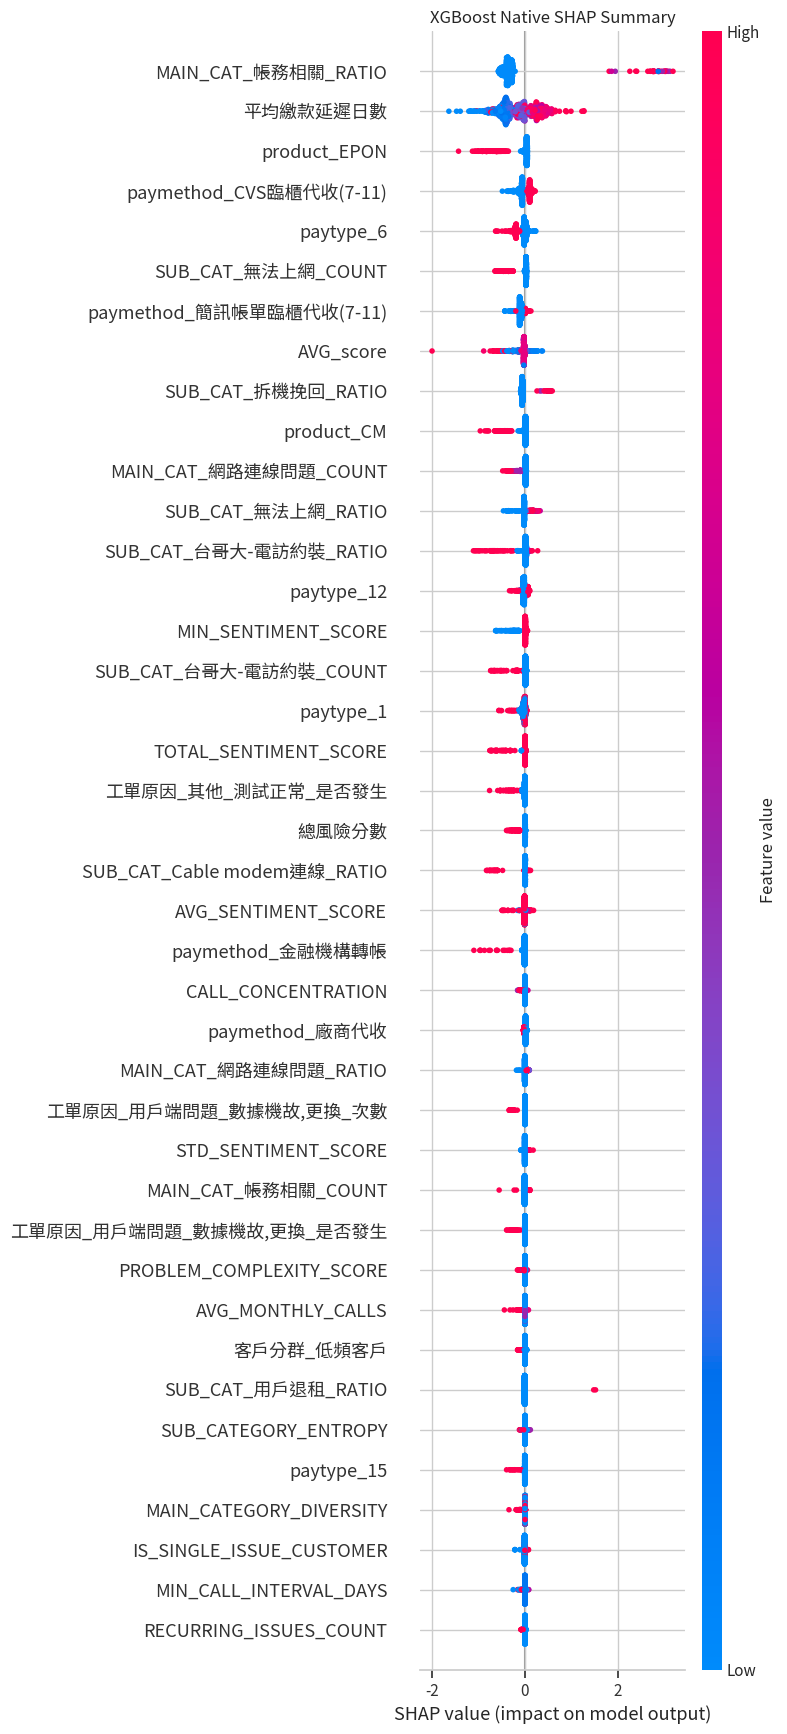

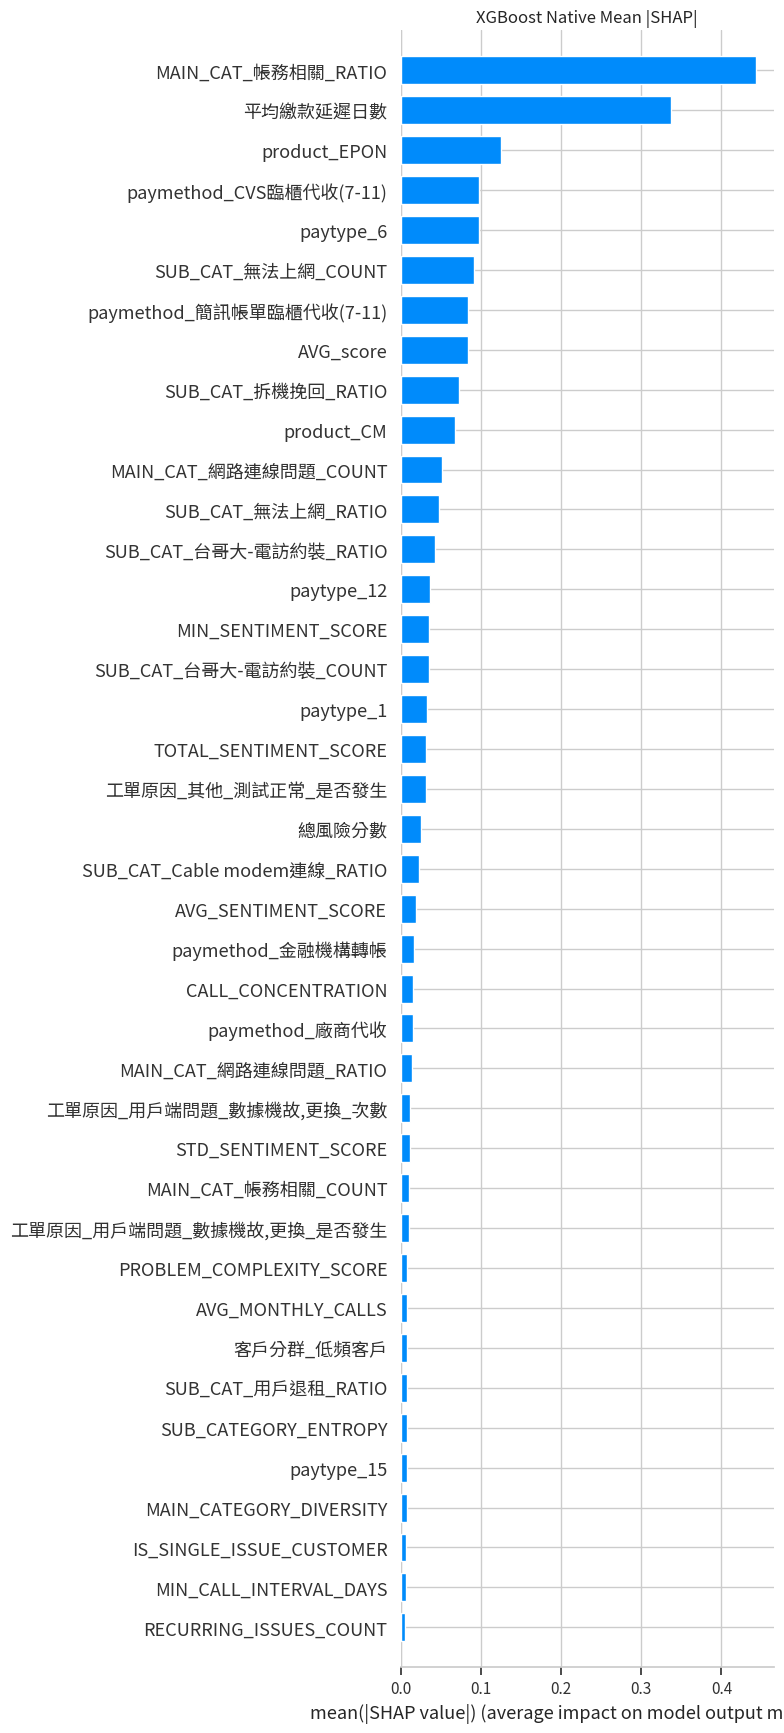

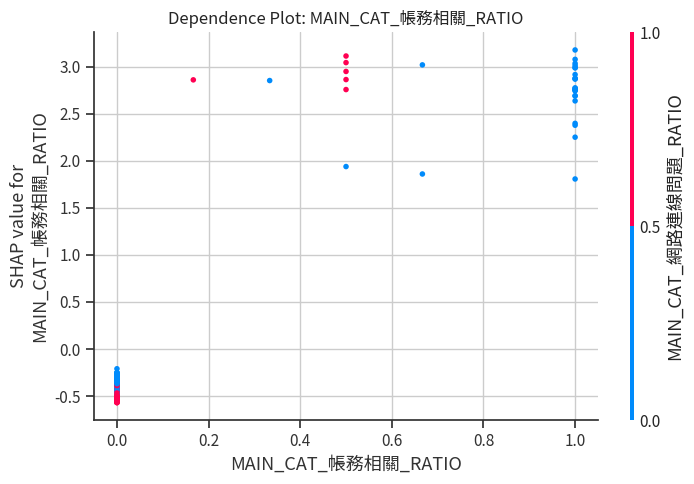

In [24]:
# 1) XGBoost 原生 SHAP（最快、最穩；建議優先使用）
res_native = explain_with_shap(
    model=model_results['XGBoost']['model'],
    X_eval=X_val_subset_for_shap,    # DataFrame 或 ndarray 皆可
    mode="xgb_native",
    do_plot=True                     # 需要圖就 True
)

In [25]:
feat = "30天內"
inter = None

if not res_native["is_multiclass"]:
    shap.dependence_plot(feat, res_native["shap_values"], X_val_subset_for_shap, interaction_index=inter)
else:
    k = 1  # 想看的類別
    shap.dependence_plot(feat, res_native["shap_values"][k], X_val_subset_for_shap, interaction_index=inter)

ValueError: Could not find feature named: 30天內

## 11.1 特定特徵的SHAP值分析

In [ ]:
feat = "alive_month"
inter = None

if not res_native["is_multiclass"]:
    shap.dependence_plot(feat, res_native["shap_values"], X_val_subset_for_shap, interaction_index=inter)
else:
    k = 1  # 想看的類別
    shap.dependence_plot(feat, res_native["shap_values"][k], X_val_subset_for_shap, interaction_index=inter)

ValueError: Could not find feature named: alive_month

In [ ]:
feat = "平均繳款延遲日數"
inter = None

if not res_native["is_multiclass"]:
    shap.dependence_plot(feat, res_native["shap_values"], X_val_subset_for_shap, interaction_index=inter)
else:
    k = 1  # 想看的類別
    shap.dependence_plot(feat, res_native["shap_values"][k], X_val_subset_for_shap, interaction_index=inter)

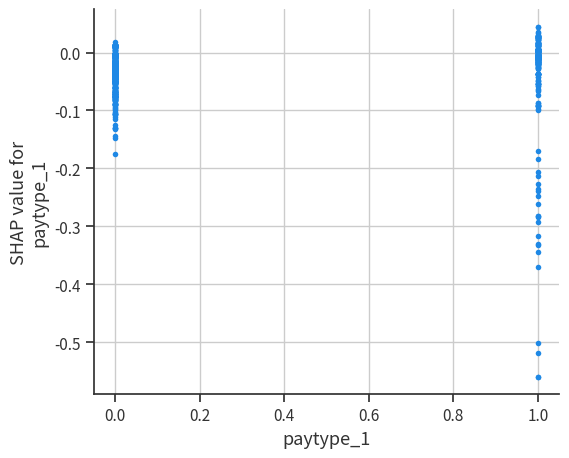

In [34]:
feat = "paytype_1"
inter = None

if not res_native["is_multiclass"]:
    shap.dependence_plot(feat, res_native["shap_values"], X_val_subset_for_shap, interaction_index=inter)
else:
    k = 1  # 想看的類別
    shap.dependence_plot(feat, res_native["shap_values"][k], X_val_subset_for_shap, interaction_index=inter)

In [ ]:
feat = "paymethod_廠商代收"
inter = None

if not res_native["is_multiclass"]:
    shap.dependence_plot(feat, res_native["shap_values"], X_val_subset_for_shap, interaction_index=inter)
else:
    k = 1  # 想看的類別
    shap.dependence_plot(feat, res_native["shap_values"][k], X_val_subset_for_shap, interaction_index=inter)

In [ ]:
feat = "工單原因_種類數"
inter = None

if not res_native["is_multiclass"]:
    shap.dependence_plot(feat, res_native["shap_values"], X_val_subset_for_shap, interaction_index=inter)
else:
    k = 1  # 想看的類別
    shap.dependence_plot(feat, res_native["shap_values"][k], X_val_subset_for_shap, interaction_index=inter)

In [ ]:
feat = "AVG_score"
inter = None

if not res_native["is_multiclass"]:
    shap.dependence_plot(feat, res_native["shap_values"], X_val_subset_for_shap, interaction_index=inter)
else:
    k = 1  # 想看的類別
    shap.dependence_plot(feat, res_native["shap_values"][k], X_val_subset_for_shap, interaction_index=inter)

## 11.2 計算並可視化 MLP 模型的 SHAP 值 (深度學習模型範例)

對於深度學習模型 (如 MLP, CNN, LSTM)，SHAP 提供了 `DeepExplainer` (適用於 TensorFlow/Keras) 或 `KernelExplainer` (通用但計算較慢)。`DeepExplainer` 更高效。

**注意**: `DeepExplainer` 需要模型的預測函數和一個背景數據集，背景數據集應代表模型訓練數據的分布。


--- 計算 MLP 模型的 SHAP 值 ---
SHAP 值計算完成。進行可視化...


<Figure size 1000x1000 with 0 Axes>

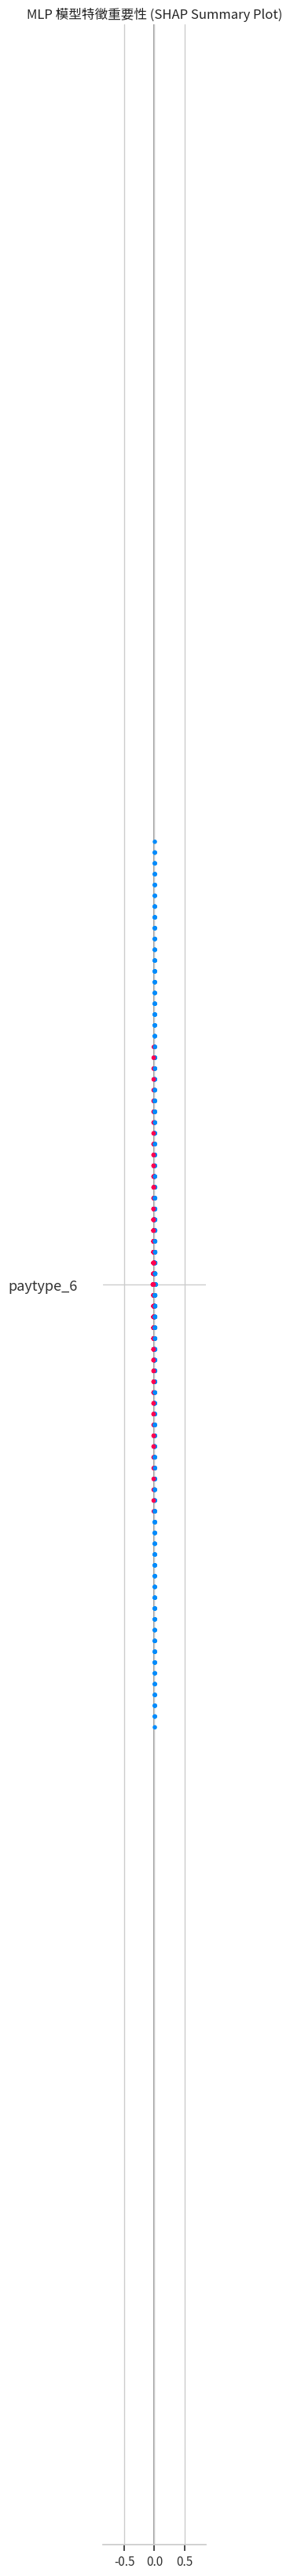

<Figure size 1000x1000 with 0 Axes>

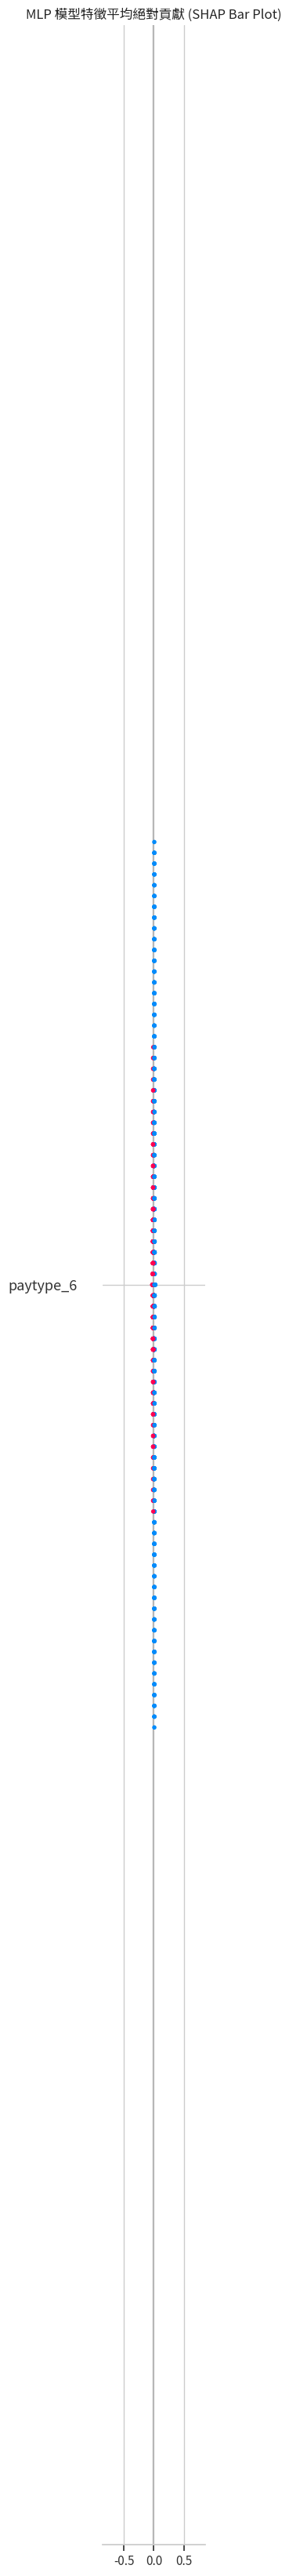


--- 解釋單個樣本預測 (MLP Force Plot) ---


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [27]:
if X_val_subset_for_shap is not None and 'MLP' in model_results:
    print("\n--- 計算 MLP 模型的 SHAP 值 ---")
    mlp_model = model_results['MLP']['model']

    # DeepExplainer 需要一個背景數據集 (例如訓練數據的子集)
    # 這裡我們使用訓練集的一個隨機子集作為背景數據
    # X_train_scaled 應該是 Numpy 陣列，這對 DeepExplainer 很重要。
    if 'X_train_scaled' in locals() and X_train_scaled is not None:
        # Ensure background data is a NumPy array for DeepExplainer
        if isinstance(X_train_scaled, pd.DataFrame):
            background_np = X_train_scaled.values
        else:
            background_np = X_train_scaled

        if background_np.shape[0] > 100:
            background = background_np[np.random.choice(background_np.shape[0], 100, replace=False)]
        else:
            background = background_np
    else:
        print("❌ X_train_scaled 未找到，無法為 DeepExplainer 準備背景數據。")
        background = None

    if background is not None:
        # 創建 DeepExplainer 對象
        explainer_mlp = shap.DeepExplainer(mlp_model, background)

        # 計算 SHAP 值
        # 由於 DeepExplainer 對於大型數據集計算成本較高，這裡對子集進行計算
        shap_values_mlp = explainer_mlp.shap_values(X_val_subset_for_shap.values) # 轉換為 NumPy 陣列

        print("SHAP 值計算完成。進行可視化...")

        # 繪製 SHAP 摘要圖 (Summary Plot)
        plt.figure(figsize=(10, 10)) # 增加圖表高度以顯示更多特徵
        # 對於二元分類，shap_values 可能是列表，需要選擇一個類別 (通常是陽性類別 1)
        if isinstance(shap_values_mlp, list): # 例如 Keras 模型通常返回列表
            shap.summary_plot(shap_values_mlp[0], X_val_subset_for_shap, show=False, max_display=40) # 顯示更多特徵
        else:
            shap.summary_plot(shap_values_mlp, X_val_subset_for_shap, show=False, max_display=40)
        plt.title("MLP 模型特徵重要性 (SHAP Summary Plot)")
        plt.tight_layout()
        plt.show()

        # 繪製 SHAP 條形圖 (Bar Plot)
        plt.figure(figsize=(10, 10)) # 增加圖表高度以顯示更多特徵
        if isinstance(shap_values_mlp, list):
            shap.summary_plot(shap_values_mlp[0], X_val_subset_for_shap, plot_type="bar", show=False, max_display=40)
        else:
            shap.summary_plot(shap_values_mlp, X_val_subset_for_shap, plot_type="bar", show=False, max_display=40)
        plt.title("MLP 模型特徵平均絕對貢獻 (SHAP Bar Plot)")
        plt.tight_layout()
        plt.show()

        # 繪製 SHAP 強制圖 (Force Plot) - 單個預測解釋範例
        print("\n--- 解釋單個樣本預測 (MLP Force Plot) ---")
        shap.initjs()
        # 解釋第一個樣本的預測
        if isinstance(shap_values_mlp, list):
            display(shap.force_plot(explainer_mlp.expected_value[0], shap_values_mlp[0][0,:], X_val_subset_for_shap.iloc[0,:]))
        else:
            display(shap.force_plot(explainer_mlp.expected_value, shap_values_mlp[0,:], X_val_subset_for_shap.iloc[0,:]))

    else:
        print("❌ DeepExplainer 的背景數據未準備好。")
else:
    print("❌ MLP 模型或用於 SHAP 分析的數據不可用。")

## 12. 模型性能總結與比較

本節將總結並比較 CNN、MLP 和 LSTM 模型在驗證集上的性能指標，特別關注陽性類別的 Precision、Recall 和 F1-Score，以及整體 AUC。

In [ ]:
# Assuming model_results dictionary is available from the training and evaluation cell.

print("=" * 70)
print("📊 模型性能總結與比較")
print("=" * 70)

if 'model_results' in locals() and model_results:
    comparison_data = []
    for model_type, results in model_results.items():
        metrics = results['metrics']
        pos_metrics = metrics['positive_metrics']
        neg_metrics = metrics['negative_metrics']
        overall_metrics = metrics['overall_metrics']
        threshold = results['threshold_info']['f1_optimized_threshold']

        comparison_data.append({
            "模型": model_type,
            "陽性Precision": pos_metrics['precision'],
            "陽性Recall": pos_metrics['recall'],
            "陽性F1-Score": pos_metrics['f1'],
            "陰性Precision": neg_metrics['precision'],
            "陰性Recall": neg_metrics['recall'],
            "陰性F1-Score": neg_metrics['f1'],
            "整體AUC": overall_metrics['auc'],
            "最佳閾值": threshold
        })

    comparison_df = pd.DataFrame(comparison_data)

    # Format for better readability
    formatted_comparison_df = comparison_df.copy()
    for col in formatted_comparison_df.columns:
        if formatted_comparison_df[col].dtype == 'float64':
            formatted_comparison_df[col] = formatted_comparison_df[col].map('{:.4f}'.format)

    print("\n模型性能比較表:")
    display(formatted_comparison_df)

    # Highlight the best performing model for key metrics
    print("\n關鍵指標最佳模型:")
    best_auc_model = comparison_df.loc[comparison_df['整體AUC'].idxmax()]
    best_pos_f1_model = comparison_df.loc[comparison_df['陽性F1-Score'].idxmax()]
    best_pos_precision_model = comparison_df.loc[comparison_df['陽性Precision'].idxmax()]
    best_pos_recall_model = comparison_df.loc[comparison_df['陽性Recall'].idxmax()]


    print(f"  整體AUC 最佳: {best_auc_model['模型']} (AUC: {best_auc_model['整體AUC']:.4f})")
    print(f"  陽性F1-Score 最佳: {best_pos_f1_model['模型']} (F1: {best_pos_f1_model['陽性F1-Score']:.4f})")
    print(f"  陽性Precision 最佳: {best_pos_precision_model['模型']} (Precision: {best_pos_precision_model['陽性Precision']:.4f})")
    print(f"  陽性Recall 最佳: {best_pos_recall_model['模型']} (Recall: {best_pos_recall_model['陽性Recall']:.4f})")


else:
    print("❌ 無法找到模型訓練結果 (model_results 字典)")

📊 模型性能總結與比較

模型性能比較表:


,模型,陽性Precision,陽性Recall,陽性F1-Score,陰性Precision,陰性Recall,陰性F1-Score,整體AUC,最佳閾值
0,CNN,0.2830,0.7644,0.4131,0.9109,0.5544,0.6893,0.7039,0.5854
1,MLP,0.4411,0.5559,0.4919,0.8913,0.8379,0.8638,0.8018,0.6092
2,LSTM,0.4297,0.5856,0.4957,0.8960,0.8212,0.8569,0.7962,0.5643



關鍵指標最佳模型:
  整體AUC 最佳: MLP (AUC: 0.8018)
  陽性F1-Score 最佳: LSTM (F1: 0.4957)
  陽性Precision 最佳: MLP (Precision: 0.4411)
  陽性Recall 最佳: CNN (Recall: 0.7644)


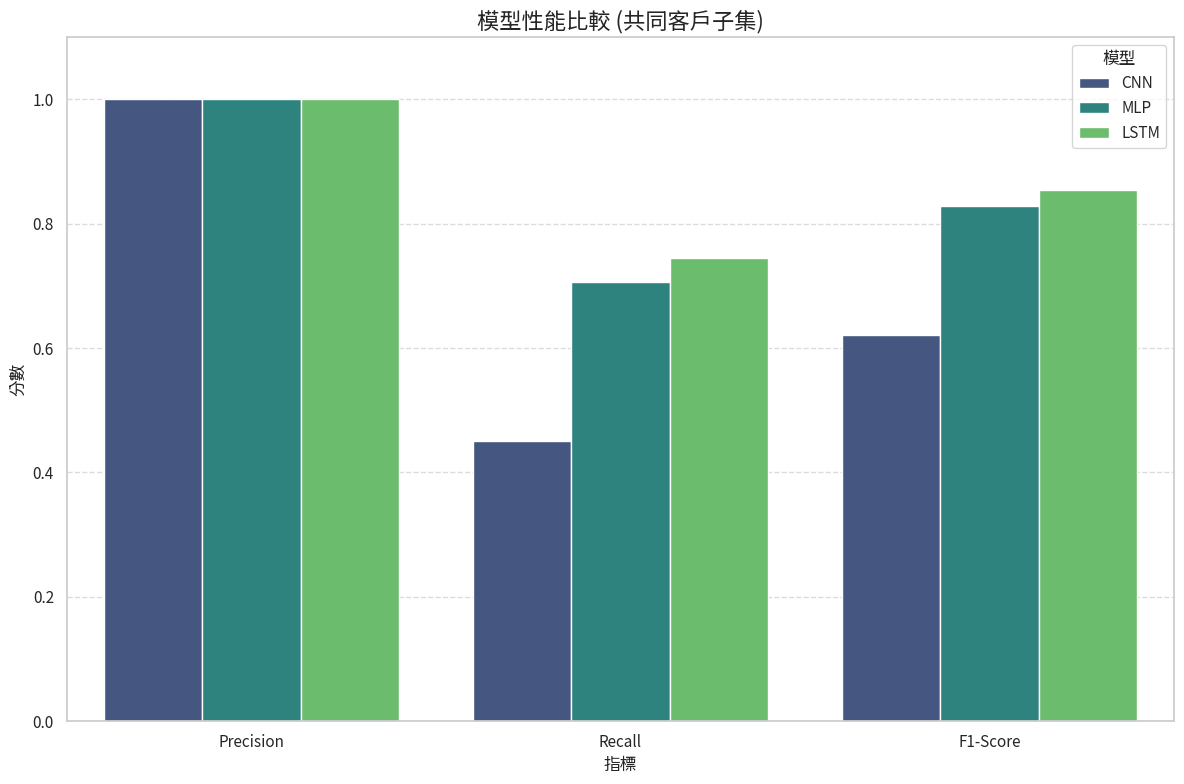

In [ ]:
# 確保 comparison_df 已成功創建且不為空
if 'comparison_df' in locals() and not comparison_df.empty:

    # Determine which metrics to plot (exclude AUC if all values are NaN)
    if 'AUC' in comparison_df.columns and comparison_df['AUC'].isnull().all():
        print("Warning: AUC values are all NaN, skipping AUC plot.")
        metrics_to_plot = ['Precision', 'Recall', 'F1-Score']
    else:
        metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'AUC']
        # Optionally drop rows where AUC is NaN if only valid AUC values are needed for plotting
        # comparison_df = comparison_df.dropna(subset=['AUC']) # Uncomment if needed

    # Ensure there are still metrics to plot after checking AUC
    if metrics_to_plot and not comparison_df.empty:
        # Melt the DataFrame for easier plotting with Seaborn
        comparison_melted = comparison_df.melt(
            id_vars='Model',
            value_vars=metrics_to_plot,
            var_name='Metric',
            value_name='Score'
        )

        # Create the bar plots
        plt.figure(figsize=(12, 8))
        sns.barplot(data=comparison_melted, x='Metric', y='Score', hue='Model', palette='viridis')

        plt.title("模型性能比較 (共同客戶子集)", fontsize=16)
        plt.xlabel("指標", fontsize=12)
        plt.ylabel("分數", fontsize=12)
        plt.ylim(0, 1.1) # Set y-axis limit for scores between 0 and 1
        plt.legend(title="模型")
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()

    elif not metrics_to_plot:
         print("No valid metrics to plot after handling NaNs.")
    else:
         print("No valid data points left for plotting after handling NaNs.")


else:
    print("Error: comparison_df not found or is empty. Cannot generate plots.")

# Task
To calculate and visualize SHAP values for the Random Forest model, I'll first prepare a background dataset from `X_train_scaled` for the `KernelExplainer`. Then, I'll use the `explain_with_shap` function to compute SHAP values for the Random Forest model, generating summary plots (dot and bar). Finally, I will create SHAP dependence plots for key features such as '平均繳款延遲日數', 'paytype_1', 'paymethod_廠商代收', '工單原因_種類數', and 'AVG_score' to understand their impact on the model's predictions. This analysis will highlight the main feature importances and their effects, similar to the XGBoost analysis.

## Prepare Background Data for KernelExplainer

### Subtask:
Create a background dataset for the SHAP KernelExplainer using a small subset of `X_train_scaled`.


**Reasoning**:
The subtask requires creating a background dataset for the SHAP KernelExplainer from `X_train_scaled`. I will check if `X_train_scaled` exists, convert it to a NumPy array if it's a DataFrame, and then sample 100 rows to create `background_data_for_rf`.



In [28]:
if 'X_train_scaled' in locals():
    # Convert X_train_scaled to a NumPy array if it's a DataFrame
    if isinstance(X_train_scaled, pd.DataFrame):
        X_train_scaled_np = X_train_scaled.values
    else:
        X_train_scaled_np = X_train_scaled

    # Randomly sample 100 rows from X_train_scaled for the background dataset
    # Ensure we don't sample more rows than available in X_train_scaled
    num_samples_for_background = min(100, X_train_scaled_np.shape[0])

    # Select unique indices to avoid sampling the same row multiple times
    indices = np.random.choice(X_train_scaled_np.shape[0], num_samples_for_background, replace=False)
    background_data_for_rf = X_train_scaled_np[indices]

    print(f"✓ Background dataset for RandomForest SHAP (background_data_for_rf) created with shape: {background_data_for_rf.shape}")
else:
    print("❌ X_train_scaled not found. Please ensure previous data preprocessing steps have been executed successfully.")
    background_data_for_rf = None

✓ Background dataset for RandomForest SHAP (background_data_for_rf) created with shape: (100, 74)


**Reasoning**:
Now that the background data is prepared, I will use the `explain_with_shap` function with the Random Forest model, `X_val_subset_for_shap`, and the generated `background_data_for_rf` to calculate and visualize SHAP values, including summary plots (dot and bar) and dependence plots for key features.




--- 計算 Random Forest 模型的 SHAP 值 ---
[KernelExplainer] 背景摘要完成：(100, 74)（K=50）
[KernelExplainer] 開始計算 SHAP 值...


  0%|          | 0/1000 [00:00<?, ?it/s]

[KernelExplainer] SHAP 值計算完成。


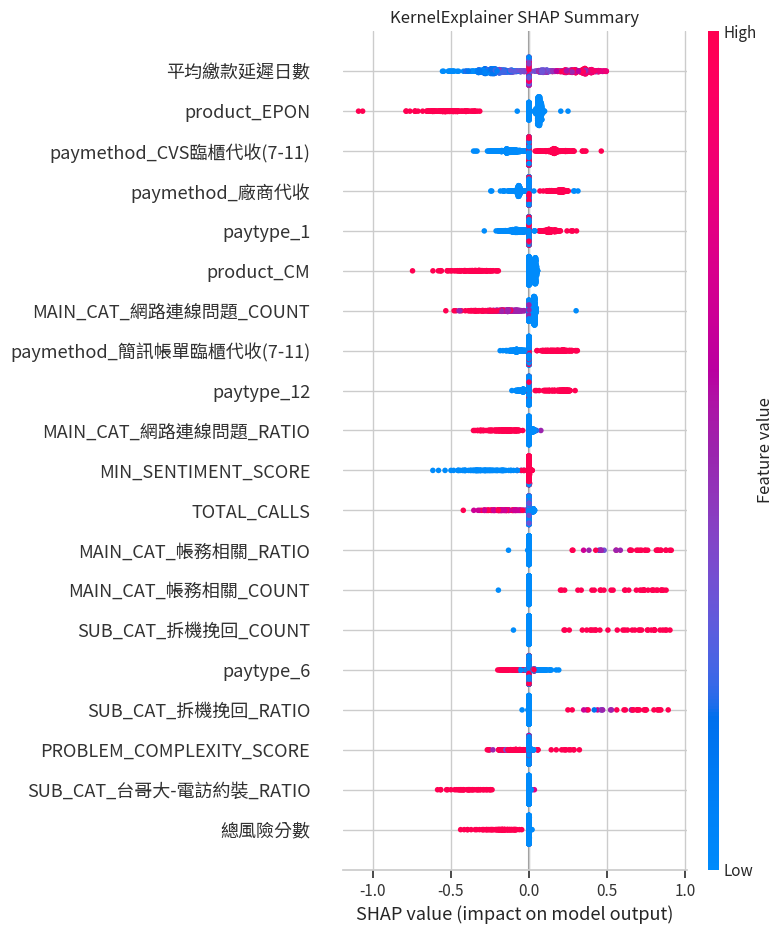

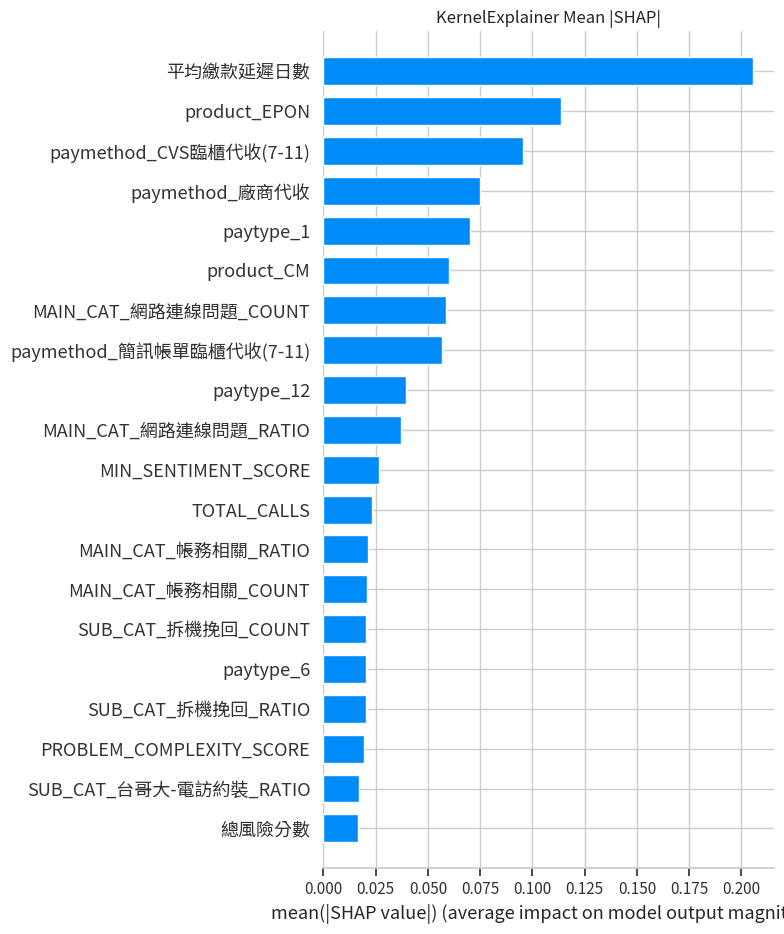

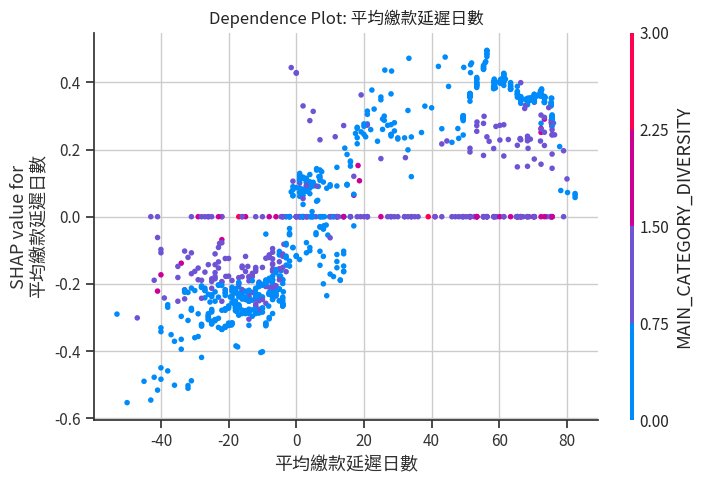


--- 繪製 Random Forest 模型特定特徵的 SHAP 依賴圖 ---

繪製特徵 '平均繳款延遲日數' 的依賴圖...


<Figure size 800x600 with 0 Axes>

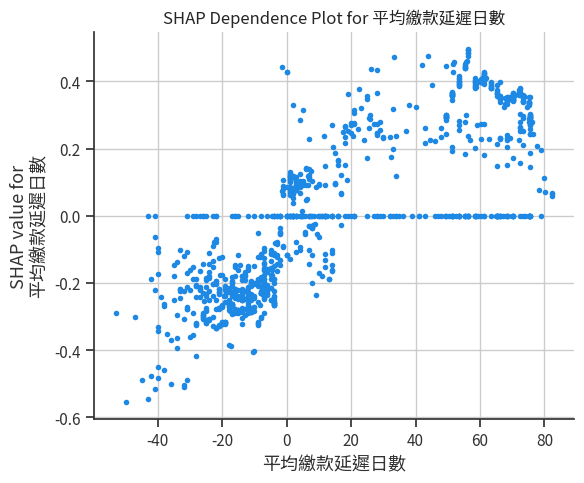


繪製特徵 'paytype_1' 的依賴圖...


<Figure size 800x600 with 0 Axes>

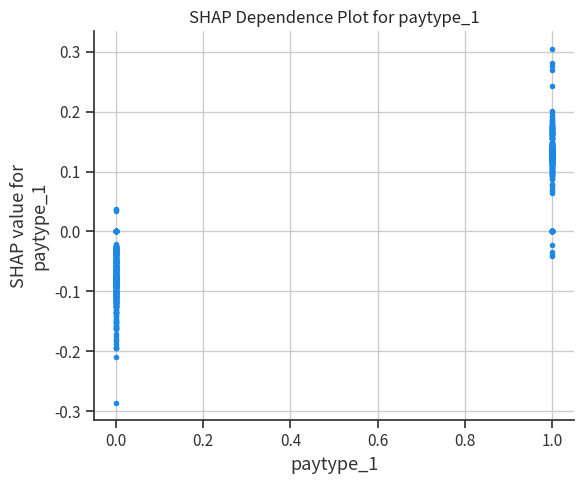


繪製特徵 'paymethod_廠商代收' 的依賴圖...


<Figure size 800x600 with 0 Axes>

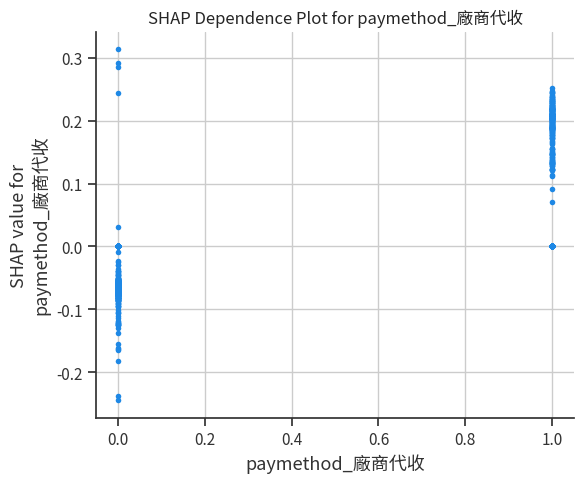

警告: 特徵 '工單原因_種類數' 不存在於模型特徵列表中，跳過依賴圖繪製。

繪製特徵 'AVG_score' 的依賴圖...


<Figure size 800x600 with 0 Axes>

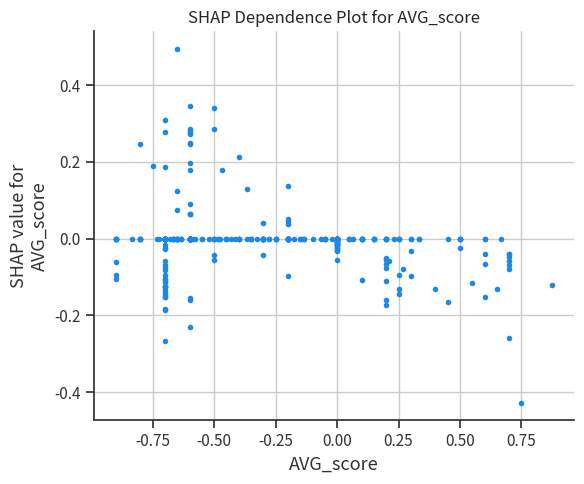

In [29]:
print("\n--- 計算 Random Forest 模型的 SHAP 值 ---")

# Ensure model_results and background_data_for_rf are available
if 'model_results' in locals() and 'RandomForest' in model_results and background_data_for_rf is not None:
    rf_model = model_results['RandomForest']['model']

    # Convert X_val_subset_for_shap to numpy array if it's a DataFrame for KernelExplainer
    # The explain_with_shap function already handles DataFrame conversion internally if feature_names are provided.
    # So, we can directly pass X_val_subset_for_shap (which is already a DataFrame)

    # Call the explain_with_shap function for Random Forest model
    # Use 'kernel' mode for scikit-learn models like RandomForest
    res_rf = explain_with_shap(
        model=rf_model,
        X_eval=X_val_subset_for_shap, # Already a DataFrame
        mode="kernel",
        feature_names=optimizer.feature_names,
        background_data=background_data_for_rf, # Use the prepared background data
        do_plot=True,
        max_shap_display=20
    )

    print("\n--- 繪製 Random Forest 模型特定特徵的 SHAP 依賴圖 ---")
    # Define features for dependence plots
    features_for_dependence_plot = [
        "平均繳款延遲日數",
        "paytype_1",
        "paymethod_廠商代收",
        "工單原因_種類數",
        "AVG_score"
    ]

    for feat in features_for_dependence_plot:
        if feat in res_rf["feature_names"]:
            print(f"\n繪製特徵 '{feat}' 的依賴圖...")
            plt.figure(figsize=(8, 6))
            if not res_rf["is_multiclass"]:
                shap.dependence_plot(feat, res_rf["shap_values"], X_val_subset_for_shap, interaction_index=None, show=False)
            else:
                k = 1  # Assuming class 1 is the positive class
                shap.dependence_plot(feat, res_rf["shap_values"][k], X_val_subset_for_shap, interaction_index=None, show=False)
            plt.title(f"SHAP Dependence Plot for {feat}")
            plt.tight_layout()
            plt.show()
        else:
            print(f"警告: 特徵 '{feat}' 不存在於模型特徵列表中，跳過依賴圖繪製。")

else:
    print("❌ Random Forest 模型或用於 SHAP 分析的數據不可用。")


## Final Task

### Subtask:
Summarize the SHAP analysis results for the Random Forest model, highlighting its key feature importances and their impact on predictions, similar to the XGBoost analysis.


## Summary:

### Data Analysis Key Findings

*   A background dataset for the Random Forest SHAP KernelExplainer was successfully created with 100 samples from the scaled training data.
*   SHAP values for the Random Forest model were computed, and both summary (dot and bar) plots were generated, providing a visual overview of feature importances and their directional impact on predictions.
*   SHAP dependence plots were successfully generated for '平均繳款延遲日數', 'paytype_1', 'paymethod_廠商代收', and 'AVG_score', illustrating how individual values of these features influence the model's output.
*   The feature '工單原因\_種類數' was not found in the model's feature list, and therefore its dependence plot could not be generated.

### Insights or Next Steps

*   Review the generated SHAP summary and dependence plots to identify the top influential features and understand the specific relationships (e.g., positive or negative correlation) between feature values and the Random Forest model's predictions.
*   Investigate why '工單原因\_種類數' was not recognized by the model to ensure all relevant features are correctly handled in future analyses.
